# Generator Generalisation and Explainability Experiments

This notebook investigates why multilingual AI-generated text detectors generalise successfully to some previously unseen text generators while exhibiting substantially lower performance on others.

To address this question, a multilingual mDeBERTa classifier is evaluated under two complementary experimental settings. First, a reference baseline model is fine-tuned using development data containing examples from all available AI text generators. This model establishes the expected detection performance when every generator is represented during training. Second, a systematic leave-one-generator-out (LOGO) evaluation is performed. In each experimental condition, one AI text generator is excluded entirely from the development partition while all remaining generators are retained. The excluded generator remains present in the unchanged benchmark test partition, allowing its outputs to be evaluated under a genuinely unseen-generator setting.

The resulting performance differences are then examined through a sequence of complementary analyses. The notebook first quantifies generator-specific generalisation gaps and investigates whether they can be explained by differences in language composition, platform composition or text-length characteristics. It subsequently analyses prediction confidence under unseen-generator conditions before performing a series of SHAP-based explainability analyses. These explainability analyses compare attribution patterns across generators, examine differences between strong- and weak-generalisation conditions, investigate the feature evidence associated with correct and incorrect unseen-generator predictions, and illustrate these mechanisms using representative example texts.

To ensure fair comparison across all experimental conditions, the same language-aware sampling procedure, multilingual mDeBERTa architecture, training configuration, random seed and official benchmark test partition are used throughout. The only experimental factor that changes between LOGO experiments is the AI text generator excluded during model development.

For reproducibility, every completed experiment automatically saves its validation-selected best model, tokenizer, development datasets, prediction outputs, evaluation metrics and experiment metadata. Intermediate training checkpoints are retained while an experiment remains incomplete so that interrupted execution can resume safely, but may be removed after successful completion.

The experimental pipeline consists of the following stages:

1. Loading and validating the processed MultiSocial benchmark dataset.
2. Training a reference baseline model using all available AI text generators.
3. Performing seven leave-one-generator-out experiments.
4. Evaluating every model on the unchanged benchmark test partition.
5. Quantifying generator-specific generalisation performance by comparing baseline and LOGO results.
6. Investigating whether language composition, platform composition and text-length characteristics account for the observed performance differences.
7. Analysing prediction confidence for unseen-generator detection.
8. Performing comparative SHAP analyses to investigate generator-specific attribution patterns.
9. Conducting outcome-conditioned explainability analyses to compare correctly detected and misclassified unseen-generator texts.
10. Examining recurrent feature shifts and representative example-level explanations associated with generator-specific prediction errors.

> **Repository data-safety note.** The MultiSocial dataset is access-restricted and is not included in this repository. Saved outputs that reproduced individual dataset texts were removed from this GitHub copy. Aggregate metrics, tables, figures, and other non-record-level outputs have been retained where possible. See the repository README for access and reproduction instructions.


## 1. Import Libraries

The required Python libraries are imported to support data manipulation, numerical computation, visualisation, reproducibility, experiment management and file handling throughout the generator generalisation pipeline.

Additional libraries required for multilingual mDeBERTa fine-tuning, model evaluation and SHAP-based explainability analyses are introduced in the relevant sections of the notebook immediately before they are first used. This keeps the experimental workflow modular while ensuring that each stage remains self-contained and easy to follow.

In [ ]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


from IPython.display import display

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 120)

print("Random seed:", SEED)

Random seed: 42


## 2. Load and Validate the Processed MultiSocial Dataset

The processed MultiSocial benchmark dataset is loaded as the common input for the baseline and leave-one-generator-out (LOGO) experiments.

An initial validation verifies the dataset structure, benchmark partitions, class distribution, language coverage and AI text generators before any sampling or model training is performed. Generator labels are extracted directly from the dataset to ensure consistency across all experiments.

In [ ]:
# Load the processed MultiSocial benchmark dataset

df = pd.read_csv("multisocial_processed.csv")

print("Dataset shape:", df.shape)

print("\nAvailable columns:")
print(df.columns.tolist())

print("\nBenchmark split distribution:")
display(
    df["split"]
    .value_counts()
    .rename_axis("Split")
    .reset_index(name="Samples")
)

print("\nNumber of languages:", df["language"].nunique())
print(
    "Languages:",
    sorted(df["language"].dropna().unique())
)

print("\nLabel distribution:")
display(
    df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("Label")
    .reset_index(name="Samples")
)

print("\nGenerator / source distribution:")
display(
    df["multi_label"]
    .value_counts(dropna=False)
    .rename_axis("Generator")
    .reset_index(name="Samples")
)

# Experimental constants

TRAIN_SPLIT = "train"
TEST_SPLIT = "test"

AI_GENERATORS = (
    df.loc[
        df["label"] == 1,
        "multi_label"
    ]
    .dropna()
    .value_counts()
    .index
    .tolist()
)

EXPERIMENTS = ["baseline"] + AI_GENERATORS

print("\nGenerators included in the experiments:")

for generator in AI_GENERATORS:
    print(f"- {generator}")

print(f"\nTotal AI generators: {len(AI_GENERATORS)}")

print("\nExperiments to be executed:")

for i, experiment in enumerate(EXPERIMENTS, start=1):
    print(f"{i}. {experiment}")

# Basic dataset integrity checks

assert len(AI_GENERATORS) == 7
assert "human" not in AI_GENERATORS
assert df["label"].isin([0, 1]).all()
assert df["split"].isin([TRAIN_SPLIT, TEST_SPLIT]).all()

print("\nInitial dataset validation passed.")

Dataset shape: (472097, 9)

Available columns:
['text', 'label', 'multi_label', 'split', 'language', 'length', 'source', 'potential_noise', 'platform']

Benchmark split distribution:


,Split,Samples
0,train,331209
1,test,140888



Number of languages: 22
Languages: ['ar', 'bg', 'ca', 'cs', 'de', 'el', 'en', 'es', 'et', 'ga', 'gd', 'hr', 'hu', 'nl', 'pl', 'pt', 'ro', 'ru', 'sk', 'sl', 'uk', 'zh']

Label distribution:


,Label,Samples
0,0,57990
1,1,414107



Generator / source distribution:


,Generator,Samples
0,Mistral-7B-Instruct-v0.2,61305
1,v5-Eagle-7B-HF,61057
2,vicuna-13b,60346
3,gemini,59559
4,gpt-3.5-turbo-0125,58851
5,human,57990
6,aya-101,57566
7,opt-iml-max-30b,55423



Generators included in the experiments:
- Mistral-7B-Instruct-v0.2
- v5-Eagle-7B-HF
- vicuna-13b
- gemini
- gpt-3.5-turbo-0125
- aya-101
- opt-iml-max-30b

Total AI generators: 7

Experiments to be executed:
1. baseline
2. Mistral-7B-Instruct-v0.2
3. v5-Eagle-7B-HF
4. vicuna-13b
5. gemini
6. gpt-3.5-turbo-0125
7. aya-101
8. opt-iml-max-30b

Initial dataset validation passed.


## 3. Separate the Benchmark Development and Test Partitions

The predefined MultiSocial development and benchmark test partitions are separated before constructing the baseline and leave-one-generator-out (LOGO) development datasets.

The development partition initially contains Human-written texts together with AI-generated texts produced by all seven generators. Generator-specific exclusion is applied only during the corresponding LOGO experiment.

The benchmark test partition remains unchanged throughout the study and is never used for development dataset construction, model training, validation or checkpoint selection. This ensures that all experimental conditions are evaluated under identical benchmark settings while preventing information leakage from the test partition.

In [ ]:
# Preserve the official benchmark partitions

train_df = (
    df[df["split"] == TRAIN_SPLIT]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    df[df["split"] == TEST_SPLIT]
    .copy()
    .reset_index(drop=True)
)

print("Development partition:", len(train_df), "samples")
print("Benchmark test partition:", len(test_df), "samples")

# Benchmark integrity checks

assert len(train_df) == 331209
assert len(test_df) == 140888
assert len(train_df) + len(test_df) == len(df)

print("\nOfficial benchmark partitions successfully preserved.")

Development partition: 331209 samples
Benchmark test partition: 140888 samples

Official benchmark partitions successfully preserved.


## 4. Define the Development Sampling Procedure

A common sampling configuration is defined for both the reference baseline model and the leave-one-generator-out (LOGO) experiments.

For every experimental condition, all Human-written samples from the predefined MultiSocial development partition are retained. AI-generated samples are then selected using the same language-aware sampling strategy to construct a globally class-balanced development dataset.

For the reference baseline model, AI-generated samples are drawn from all available generators. For each LOGO experiment, AI-generated samples from one generator are excluded entirely before sampling is performed. The same sampling strategy, class balance, language coverage and random seed are used throughout, ensuring that generator exclusion is the only factor that changes between experimental conditions.

### 4.1 Define the Experimental Configuration

The experimental configuration specifies the class labels, the fixed random seed and the AI text generators used throughout the generator generalisation experiments.

The same configuration is shared by the reference baseline model and all seven leave-one-generator-out experiments, ensuring that every experimental condition is constructed using identical settings apart from the excluded generator.

In [ ]:
from sklearn.model_selection import train_test_split

# Class labels

HUMAN_LABEL = 0
AI_LABEL = 1

# Reproducibility

SAMPLING_RANDOM_STATE = SEED

# Experimental configuration

LOGO_GENERATORS = list(AI_GENERATORS)

BASELINE_EXPERIMENT = "baseline"

EXPERIMENTS = [
    BASELINE_EXPERIMENT,
    *LOGO_GENERATORS
]

# Validate the experimental configuration

assert len(LOGO_GENERATORS) == 7
assert len(LOGO_GENERATORS) == len(set(LOGO_GENERATORS))
assert "human" not in [
    generator.lower()
    for generator in LOGO_GENERATORS
]

print("Experimental configuration prepared.")

print("\nHuman-written label:", HUMAN_LABEL)
print("AI-generated label:", AI_LABEL)
print("Sampling random seed:", SAMPLING_RANDOM_STATE)

print("\nExperimental conditions:")

for index, experiment in enumerate(EXPERIMENTS, start=1):
    print(f"{index}. {experiment}")

print(f"\nTotal experiments: {len(EXPERIMENTS)}")

Experimental configuration prepared.

Human-written label: 0
AI-generated label: 1
Sampling random seed: 42

Experimental conditions:
1. baseline
2. Mistral-7B-Instruct-v0.2
3. v5-Eagle-7B-HF
4. vicuna-13b
5. gemini
6. gpt-3.5-turbo-0125
7. aya-101
8. opt-iml-max-30b

Total experiments: 8


### 4.2 Separate Human and AI Samples

A reusable function is defined to separate the predefined development partition into Human-written texts and AI-generated texts.

For the reference baseline experiment, AI-generated samples from all generators are retained. For each leave-one-generator-out (LOGO) experiment, AI-generated samples from the excluded generator are separated while all remaining generators are retained for development sampling.

Using a common separation function ensures that both the baseline and LOGO experiments follow the same data preparation pipeline, with generator exclusion being the only difference between experimental conditions.

In [ ]:
def separate_logo_samples(
    development_partition,
    excluded_generator=None
):
    """
    Separate the predefined development partition into:

    1. Human-written samples.
    2. AI-generated samples retained for development.
    3. AI-generated samples excluded from development.

    If excluded_generator is None, all AI generators are retained
    (reference baseline experiment).
    """

    human_samples = (
        development_partition[
            development_partition["label"] == HUMAN_LABEL
        ]
        .copy()
        .reset_index(drop=True)
    )

    if excluded_generator is None:

        remaining_generator_ai_samples = (
            development_partition[
                development_partition["label"] == AI_LABEL
            ]
            .copy()
            .reset_index(drop=True)
        )

        excluded_generator_ai_samples = pd.DataFrame(
            columns=development_partition.columns
        )

    else:

        remaining_generator_ai_samples = (
            development_partition[
                (development_partition["label"] == AI_LABEL)
                &
                (
                    development_partition["multi_label"]
                    != excluded_generator
                )
            ]
            .copy()
            .reset_index(drop=True)
        )

        excluded_generator_ai_samples = (
            development_partition[
                (development_partition["label"] == AI_LABEL)
                &
                (
                    development_partition["multi_label"]
                    == excluded_generator
                )
            ]
            .copy()
            .reset_index(drop=True)
        )

    # Integrity checks

    assert len(human_samples) > 0
    assert len(remaining_generator_ai_samples) > 0

    if excluded_generator is not None:

        assert len(excluded_generator_ai_samples) > 0

        assert not (
            remaining_generator_ai_samples["multi_label"]
            .eq(excluded_generator)
            .any()
        )

        assert (
            excluded_generator_ai_samples["multi_label"]
            .eq(excluded_generator)
            .all()
        )

    return (
        human_samples,
        remaining_generator_ai_samples,
        excluded_generator_ai_samples
    )

### 4.3 Define the Language-Aware Balanced Sampling Procedure

A reusable language-aware sampling function is defined to construct the balanced AI-generated subset for every experimental condition.

For each development language, all available Human-written texts are retained. An equal number of AI-generated texts is then sampled independently within the same language. Sampling is stratified by generator and performed without replacement to preserve the relative composition of the available generators as closely as possible.

For the reference baseline experiment, AI-generated texts are sampled from all generators. For each leave-one-generator-out (LOGO) experiment, sampling is performed after removing the excluded generator. The same sampling strategy and random seed are used throughout to ensure that all experimental conditions remain directly comparable.

In [ ]:
def sample_language_balanced_ai(
    human_samples,
    remaining_generator_ai_samples,
    random_state=SAMPLING_RANDOM_STATE
):
    """
    Construct a language-aware class-balanced AI subset.

    For each development language, all Human-written texts are
    retained and an equal number of AI-generated texts is sampled
    without replacement. Sampling is stratified by generator to
    preserve the relative generator composition.

    The same function is used for both the reference baseline
    model and the leave-one-generator-out (LOGO) experiments.

    Returns
    -------
    sampled_ai_df : pandas.DataFrame
        Language-aware balanced AI-generated sample.

    sampling_summary_df : pandas.DataFrame
        Language-level sampling statistics.
    """

    sampled_ai_parts = []
    sampling_summary = []

    training_languages = sorted(
        human_samples["language"]
        .dropna()
        .unique()
    )

    for language in training_languages:

        language_human_df = human_samples[
            human_samples["language"] == language
        ]

        n_human = len(language_human_df)

        language_ai_df = (
            remaining_generator_ai_samples[
                remaining_generator_ai_samples["language"] == language
            ]
            .copy()
        )

        n_ai_available = len(language_ai_df)

        if n_ai_available < n_human:
            raise ValueError(
                f"Not enough eligible AI samples for language "
                f"'{language}': {n_ai_available} AI samples available "
                f"for {n_human} Human-written samples."
            )

        sampled_language_ai_df, _ = train_test_split(
            language_ai_df,
            train_size=n_human,
            stratify=language_ai_df["multi_label"],
            random_state=random_state
        )

        sampled_ai_parts.append(
            sampled_language_ai_df
        )

        sampling_summary.append({
            "Language": language,
            "Human retained": n_human,
            "Remaining AI available": n_ai_available,
            "AI sampled": len(sampled_language_ai_df)
        })

    sampled_ai_df = (
        pd.concat(
            sampled_ai_parts,
            ignore_index=True
        )
        .reset_index(drop=True)
    )

    sampling_summary_df = pd.DataFrame(
        sampling_summary
    )

    # Integrity checks

    assert len(sampled_ai_df) == len(human_samples)

    assert (
        sampling_summary_df["Human retained"].sum()
        ==
        sampling_summary_df["AI sampled"].sum()
    )

    assert (
        set(sampled_ai_df["language"].dropna().unique())
        ==
        set(human_samples["language"].dropna().unique())
    )

    return (
        sampled_ai_df,
        sampling_summary_df
    )

### 4.4 Construct the Final Balanced Development Dataset

A reusable function is defined to combine the retained Human-written texts with the language-aware sampled AI-generated texts into the final balanced multilingual development dataset.

The combined dataset is randomly shuffled using the fixed sampling seed before the train-validation split is created. For the reference baseline experiment, AI-generated texts from all generators are retained. For each leave-one-generator-out (LOGO) experiment, the function additionally verifies that the excluded generator is absent from the development dataset.

Using a common construction procedure ensures that both the baseline and LOGO experiments produce directly comparable development datasets while differing only in the excluded generator.

In [ ]:
def construct_logo_development_dataset(
    human_samples,
    sampled_ai_samples,
    excluded_generator=None,
    random_state=SAMPLING_RANDOM_STATE
):
    """
    Combine Human-written and sampled AI-generated texts into a
    balanced, reproducibly shuffled development dataset.

    The same function is used for both the reference baseline
    model and the leave-one-generator-out (LOGO) experiments.
    """

    # Verify equal class sizes before combining

    assert len(human_samples) == len(sampled_ai_samples)

    development_df = (
        pd.concat(
            [
                human_samples,
                sampled_ai_samples
            ],
            ignore_index=True
        )
        .sample(
            frac=1,
            random_state=random_state
        )
        .reset_index(drop=True)
    )

    class_counts = (
        development_df["label"]
        .value_counts()
    )

    # Integrity checks

    assert class_counts[HUMAN_LABEL] == class_counts[AI_LABEL]

    if excluded_generator is not None:

        assert not (
            development_df["multi_label"]
            .eq(excluded_generator)
            .any()
        )

    assert (
        set(development_df["language"].dropna().unique())
        ==
        set(human_samples["language"].dropna().unique())
    )

    return development_df

### 4.5 Validate the Balanced Development Dataset

A reusable validation function is defined to verify that every balanced development dataset satisfies the required sampling conditions.

For each experimental condition, the validation confirms that the Human-written and AI-generated classes are perfectly balanced, all development languages are retained, and class balance is preserved independently within each language. The language distribution of the balanced development dataset is additionally compared with that of the original development partition to quantify any distributional change introduced by sampling.

For the leave-one-generator-out (LOGO) experiments, the validation additionally confirms that the excluded generator is completely absent from the development dataset.

In [ ]:
def validate_balanced_development_dataset(
    development_df,
    original_development_partition,
    excluded_generator=None
):
    """
    Validate a balanced development dataset.

    Returns
    -------
    validation_summary : dict
        Compact validation statistics for the current experiment.

    class_distribution_df : pandas.DataFrame
        Overall Human-written and AI-generated class distribution.

    language_class_df : pandas.DataFrame
        Class distribution within each development language.

    language_proportion_comparison_df : pandas.DataFrame
        Original and sampled language proportions.
    """

    # Overall class distribution

    class_distribution_df = (
        development_df["label"]
        .value_counts()
        .sort_index()
        .rename_axis("Label")
        .reset_index(name="Samples")
    )

    class_distribution_df["Class"] = (
        class_distribution_df["Label"]
        .map({
            HUMAN_LABEL: "Human",
            AI_LABEL: "AI"
        })
    )

    class_distribution_df["Percentage"] = (
        class_distribution_df["Samples"]
        / len(development_df)
        * 100
    ).round(2)

    class_distribution_df = class_distribution_df[
        [
            "Label",
            "Class",
            "Samples",
            "Percentage"
        ]
    ]

    # Language-specific class distribution

    language_class_df = (
        pd.crosstab(
            development_df["language"],
            development_df["label"]
        )
        .rename(
            columns={
                HUMAN_LABEL: "Human",
                AI_LABEL: "AI"
            }
        )
    )

    for column in ["Human", "AI"]:
        if column not in language_class_df.columns:
            language_class_df[column] = 0

    language_class_df["Total"] = (
        language_class_df["Human"]
        + language_class_df["AI"]
    )

    language_class_df["Human %"] = (
        language_class_df["Human"]
        / language_class_df["Total"]
        * 100
    ).round(2)

    language_class_df["AI %"] = (
        language_class_df["AI"]
        / language_class_df["Total"]
        * 100
    ).round(2)

    language_class_df = (
        language_class_df
        .sort_values(
            "Total",
            ascending=False
        )
    )

    # Compare language proportions

    original_language_proportions = (
        original_development_partition["language"]
        .value_counts(normalize=True)
        .rename("Original development %")
    )

    sampled_language_proportions = (
        development_df["language"]
        .value_counts(normalize=True)
        .rename("Balanced development %")
    )

    language_proportion_comparison_df = (
        pd.concat(
            [
                original_language_proportions,
                sampled_language_proportions
            ],
            axis=1
        )
        .fillna(0)
    )

    language_proportion_comparison_df = (
        language_proportion_comparison_df
        * 100
    ).round(2)

    language_proportion_comparison_df[
        "Absolute difference (pp)"
    ] = (
        language_proportion_comparison_df[
            "Original development %"
        ]
        -
        language_proportion_comparison_df[
            "Balanced development %"
        ]
    ).abs().round(2)

    language_proportion_comparison_df = (
        language_proportion_comparison_df
        .sort_values(
            "Original development %",
            ascending=False
        )
    )

    # Integrity checks

    class_counts = development_df["label"].value_counts()

    assert (
        class_counts[HUMAN_LABEL]
        ==
        class_counts[AI_LABEL]
    )

    assert (
        set(
            development_df["language"]
            .dropna()
            .unique()
        )
        ==
        set(
            original_development_partition[
                original_development_partition["label"]
                == HUMAN_LABEL
            ]["language"]
            .dropna()
            .unique()
        )
    )

    assert (
        language_class_df["Human"]
        .eq(language_class_df["AI"])
        .all()
    )

    if excluded_generator is not None:

        assert not (
            development_df["multi_label"]
            .eq(excluded_generator)
            .any()
        )

    # Validation summary

    validation_summary = {
        "Experiment": (
            "Baseline"
            if excluded_generator is None
            else excluded_generator
        ),
        "Development samples": len(development_df),
        "Human-written samples": int(
            class_counts[HUMAN_LABEL]
        ),
        "AI-generated samples": int(
            class_counts[AI_LABEL]
        ),
        "Languages retained": int(
            development_df["language"].nunique()
        ),
        "Maximum language proportion change (pp)": float(
            language_proportion_comparison_df[
                "Absolute difference (pp)"
            ].max()
        ),
        "Excluded-generator samples in development": (
            0
            if excluded_generator is None
            else int(
                development_df["multi_label"]
                .eq(excluded_generator)
                .sum()
            )
        )
    }

    return (
        validation_summary,
        class_distribution_df,
        language_class_df,
        language_proportion_comparison_df
    )

### 4.6 Validate Generator Distribution

A reusable validation function is defined to compare the relative distribution of AI text generators before and after language-aware sampling.

For each experimental condition, the original generator proportions in the eligible AI development samples are compared with those in the sampled AI subset. The absolute difference in percentage points is calculated for every generator.

Small differences indicate that the stratified sampling procedure preserves the relative composition of the available generators while constructing the balanced multilingual development dataset. For the reference baseline model, all seven generators are included, whereas each leave-one-generator-out (LOGO) experiment evaluates the remaining six generators after exclusion.

In [ ]:
def validate_generator_distribution(
    remaining_generator_ai_samples,
    sampled_ai_samples
):
    """
    Compare generator proportions before and after
    language-aware sampling.

    Returns
    -------
    generator_proportion_comparison_df : pandas.DataFrame
        Original and sampled generator proportions together
        with their absolute differences in percentage points.

    maximum_generator_change : float
        Maximum absolute generator proportion difference.
    """

    # Generator proportions before sampling

    original_generator_proportions = (
        remaining_generator_ai_samples["multi_label"]
        .value_counts(normalize=True)
        .rename("Original AI %")
    )

    # Generator proportions after sampling

    sampled_generator_proportions = (
        sampled_ai_samples["multi_label"]
        .value_counts(normalize=True)
        .rename("Sampled AI %")
    )

    # Compare generator distributions

    generator_proportion_comparison_df = (
        pd.concat(
            [
                original_generator_proportions,
                sampled_generator_proportions
            ],
            axis=1
        )
        .fillna(0)
    )

    generator_proportion_comparison_df = (
        generator_proportion_comparison_df
        * 100
    ).round(2)

    generator_proportion_comparison_df[
        "Absolute difference (pp)"
    ] = (
        generator_proportion_comparison_df[
            "Original AI %"
        ]
        -
        generator_proportion_comparison_df[
            "Sampled AI %"
        ]
    ).abs().round(2)

    generator_proportion_comparison_df = (
        generator_proportion_comparison_df
        .sort_values(
            "Original AI %",
            ascending=False
        )
    )

    maximum_generator_change = float(
        generator_proportion_comparison_df[
            "Absolute difference (pp)"
        ].max()
    )

    # Integrity checks

    assert (
        set(
            sampled_ai_samples["multi_label"]
            .dropna()
            .unique()
        )
        ==
        set(
            remaining_generator_ai_samples["multi_label"]
            .dropna()
            .unique()
        )
    )

    sampled_proportion_sum = (
        sampled_ai_samples["multi_label"]
        .value_counts(normalize=True)
        .sum()
    )

    assert np.isclose(
        sampled_proportion_sum,
        1.0,
        atol=1e-8
    )

    return (
        generator_proportion_comparison_df,
        maximum_generator_change
    )

### 4.7 Perform Final Sampling Integrity Checks

A final validation function is defined to confirm that every balanced development dataset satisfies the complete experimental design.

For each experimental condition, the function verifies that the Human-written and AI-generated classes remain perfectly balanced, all development languages are retained and the benchmark test partition retains its original size. For the leave-one-generator-out (LOGO) experiments, the validation additionally confirms that the excluded generator is completely absent from the development dataset.

The function combines the language- and generator-distribution statistics obtained in the previous validation stages into a single compact validation record for the current experiment.

In [ ]:
def perform_final_sampling_checks(
    development_df,
    original_development_partition,
    benchmark_test_df,
    full_dataset,
    excluded_generator=None,
    maximum_language_change=0.0,
    maximum_generator_change=0.0
):
    """
    Perform final integrity checks for one experimental
    development dataset and return a compact validation summary.
    """

    # Class counts

    class_counts = (
        development_df["label"]
        .value_counts()
    )

    human_count = int(
        class_counts.get(HUMAN_LABEL, 0)
    )

    ai_count = int(
        class_counts.get(AI_LABEL, 0)
    )

    if excluded_generator is None:

        excluded_generator_count = 0

    else:

        excluded_generator_count = int(
            development_df.loc[
                development_df["label"] == AI_LABEL,
                "multi_label"
            ]
            .eq(excluded_generator)
            .sum()
        )

    # Language coverage

    original_development_languages = set(
        original_development_partition["language"]
        .dropna()
        .unique()
    )

    sampled_development_languages = set(
        development_df["language"]
        .dropna()
        .unique()
    )

    # Benchmark integrity

    original_test_size = int(
        full_dataset["split"]
        .eq(TEST_SPLIT)
        .sum()
    )

    # Final integrity checks

    assert human_count == ai_count

    assert (
        sampled_development_languages
        ==
        original_development_languages
    )

    assert len(benchmark_test_df) == original_test_size

    if excluded_generator is not None:

        assert excluded_generator_count == 0

    # Validation summary

    validation_record = {

        "Experiment": (
            "Baseline"
            if excluded_generator is None
            else excluded_generator
        ),

        "Development samples":
            len(development_df),

        "Human-written samples":
            human_count,

        "AI-generated samples":
            ai_count,

        "Human / AI distribution":
            "50% / 50%",

        "Training languages retained":
            (
                f"{len(sampled_development_languages)} / "
                f"{len(original_development_languages)}"
            ),

        "Maximum language proportion change (pp)":
            maximum_language_change,

        "Maximum generator proportion change (pp)":
            maximum_generator_change,

        "Excluded-generator samples in development":
            excluded_generator_count,

        "Benchmark test samples":
            len(benchmark_test_df)

    }

    return validation_record

## 5. Create Reproducible Training and Validation Sets

A reusable splitting function is defined to partition each balanced development dataset into model training and validation subsets using a reproducible 90:10 split.

Stratification is performed jointly over language and class label, preserving the Human-written and AI-generated class balance within each development language while maintaining comparable multilingual representation across the training and validation subsets.

The same splitting procedure is applied to both the reference baseline model and all leave-one-generator-out (LOGO) experiments. The benchmark test partition remains completely isolated and is never used for model training, validation, checkpoint selection or any other development decision.

In [ ]:
def create_train_validation_split(
    development_df,
    excluded_generator=None,
    validation_size=0.10,
    random_state=SEED
):
    """
    Create reproducible model-training and validation subsets using
    joint language-class stratification.

    Returns
    -------
    model_train_df : pandas.DataFrame
        Model-training subset.

    validation_df : pandas.DataFrame
        Validation subset.

    split_validation_record : dict
        Compact integrity and distribution summary.
    """

    split_source_df = development_df.copy()

    # Joint language-class stratification

    split_source_df["stratify_group"] = (
        split_source_df["language"].astype(str)
        + "_"
        + split_source_df["label"].astype(str)
    )

    model_train_df, validation_df = train_test_split(
        split_source_df,
        test_size=validation_size,
        stratify=split_source_df["stratify_group"],
        random_state=random_state
    )

    model_train_df = (
        model_train_df
        .drop(columns="stratify_group")
        .reset_index(drop=True)
    )

    validation_df = (
        validation_df
        .drop(columns="stratify_group")
        .reset_index(drop=True)
    )

    # Class distributions

    train_class_proportions = (
        model_train_df["label"]
        .value_counts(normalize=True)
    )

    validation_class_proportions = (
        validation_df["label"]
        .value_counts(normalize=True)
    )

    # Language distributions

    train_language_proportions = (
        model_train_df["language"]
        .value_counts(normalize=True)
        .rename("Model train %")
    )

    validation_language_proportions = (
        validation_df["language"]
        .value_counts(normalize=True)
        .rename("Validation %")
    )

    split_language_comparison_df = (
        pd.concat(
            [
                train_language_proportions,
                validation_language_proportions
            ],
            axis=1
        )
        .fillna(0)
    )

    split_language_comparison_df = (
        split_language_comparison_df
        * 100
    ).round(2)

    split_language_comparison_df[
        "Absolute difference (pp)"
    ] = (
        split_language_comparison_df["Model train %"]
        -
        split_language_comparison_df["Validation %"]
    ).abs().round(2)

    maximum_language_split_difference = float(
        split_language_comparison_df[
            "Absolute difference (pp)"
        ].max()
    )

    # Integrity checks

    assert (
        len(model_train_df)
        + len(validation_df)
        ==
        len(development_df)
    )

    assert (
        set(model_train_df["language"].dropna().unique())
        ==
        set(development_df["language"].dropna().unique())
    )

    assert (
        set(validation_df["language"].dropna().unique())
        ==
        set(development_df["language"].dropna().unique())
    )

    if excluded_generator is not None:

        assert not (
            model_train_df["multi_label"]
            .eq(excluded_generator)
            .any()
        )

        assert not (
            validation_df["multi_label"]
            .eq(excluded_generator)
            .any()
        )

    # Validation summary

    split_validation_record = {

        "Experiment": (
            "Baseline"
            if excluded_generator is None
            else excluded_generator
        ),

        "Development samples":
            len(development_df),

        "Model training samples":
            len(model_train_df),

        "Validation samples":
            len(validation_df),

        "Training Human proportion":
            float(
                train_class_proportions.get(
                    HUMAN_LABEL,
                    0
                )
            ),

        "Training AI proportion":
            float(
                train_class_proportions.get(
                    AI_LABEL,
                    0
                )
            ),

        "Validation Human proportion":
            float(
                validation_class_proportions.get(
                    HUMAN_LABEL,
                    0
                )
            ),

        "Validation AI proportion":
            float(
                validation_class_proportions.get(
                    AI_LABEL,
                    0
                )
            ),

        "Maximum train-validation language difference (pp)":
            maximum_language_split_difference,

        "Excluded-generator samples in model training":
            (
                0
                if excluded_generator is None
                else int(
                    model_train_df["multi_label"]
                    .eq(excluded_generator)
                    .sum()
                )
            ),

        "Excluded-generator samples in validation":
            (
                0
                if excluded_generator is None
                else int(
                    validation_df["multi_label"]
                    .eq(excluded_generator)
                    .sum()
                )
            )

    }

    return (
        model_train_df,
        validation_df,
        split_validation_record
    )

## 6. Load the mDeBERTa-v3-base Tokenizer

The tokenizer associated with the selected multilingual mDeBERTa-v3-base model is loaded to prepare multilingual social-media texts for transformer-based classification.

The same tokenizer is used consistently throughout both the reference baseline model and all leave-one-generator-out (LOGO) experiments, ensuring that every experimental condition applies an identical tokenisation procedure. Using the tokenizer corresponding to the pretrained model guarantees that input texts are converted into the subword representations expected during model fine-tuning.

The maximum input sequence length is determined once using only the predefined MultiSocial development partition. The benchmark test partition is not used in this analysis.

In [ ]:
import torch
from transformers import AutoTokenizer

# Model configuration

MODEL_NAME = "microsoft/mdeberta-v3-base"

# Reproducibility

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load tokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Tokenizer loaded successfully.")
print("Model:", MODEL_NAME)
print("Vocabulary size:", f"{tokenizer.vocab_size:,}")
print("Maximum tokenizer length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 4.31MB            

spm.model: downloading bytes:           |  0.00B            

Tokenizer loaded successfully.
Model: microsoft/mdeberta-v3-base
Vocabulary size: 250,101
Maximum tokenizer length: 1000000000000000019884624838656


## 7. Analyse Token Sequence Lengths

Token sequence lengths are analysed once using the predefined MultiSocial development partition before any padding or truncation is applied. The benchmark test partition is not used in this analysis.

The purpose of this stage is to establish a single maximum input sequence length that remains fixed throughout the reference baseline model and all leave-one-generator-out (LOGO) experiments. Using one shared truncation threshold ensures that input preprocessing remains identical across every experimental condition.

Because multilingual subword tokenisation can produce different sequence lengths across languages and generators, summary statistics and candidate truncation thresholds are examined using the mDeBERTa-v3-base tokenizer. The selected value should retain the vast majority of development texts while avoiding the computational cost associated with substantially longer sequences.

In [ ]:
# Tokenise the predefined development partition without
# truncation or padding

development_texts = (
    train_df["text"]
    .fillna("")
    .astype(str)
    .tolist()
)

encoded_development = tokenizer(
    development_texts,
    add_special_tokens=True,
    truncation=False,
    padding=False,
    return_attention_mask=False
)

development_token_lengths = np.array([
    len(input_ids)
    for input_ids in encoded_development["input_ids"]
])

print(
    "Development texts analysed:",
    f"{len(development_token_lengths):,}"
)

Development texts analysed: 331,209


In [ ]:
# Summarise the development token-length distribution

token_length_summary = (
    pd.Series(development_token_lengths)
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99
        ]
    )
)

display(token_length_summary)

,0
count,331209.000000
mean,48.262094
std,60.728646
min,5.000000
50%,27.000000
90%,103.000000
95%,175.000000
99%,322.000000
max,2045.000000


In [ ]:
# Evaluate candidate maximum sequence lengths

length_thresholds = [
    64,
    128,
    256,
    512
]

threshold_summary = []

for threshold in length_thresholds:

    samples_exceeding_threshold = int(
        (development_token_lengths > threshold).sum()
    )

    percentage_exceeding_threshold = (
        samples_exceeding_threshold
        / len(development_token_lengths)
        * 100
    )

    threshold_summary.append({
        "Maximum sequence length": threshold,
        "Texts exceeding threshold": samples_exceeding_threshold,
        "Percentage (%)": round(
            percentage_exceeding_threshold,
            2
        )
    })

threshold_summary_df = pd.DataFrame(
    threshold_summary
)

display(threshold_summary_df)

,Maximum sequence length,Texts exceeding threshold,Percentage (%)
0,64,64812,19.57
1,128,24181,7.30
2,256,8855,2.67
3,512,23,0.01


In [ ]:
# Fixed across every LOGO experiment

MAX_LENGTH = 256

print(
    "Maximum sequence length used across all LOGO experiments:",
    MAX_LENGTH
)

Maximum sequence length used across all LOGO experiments: 256


The multilingual development texts were generally short despite the presence of a small number of substantially longer sequences. The median sequence length was 27 tokens, while 95% and 99% of texts contained no more than 175 and 322 tokens, respectively.

Only 2.67% of development texts exceeded 256 tokens, indicating that a maximum sequence length of 256 would truncate only a small proportion of the dataset while substantially reducing the computational cost of repeated model fine-tuning. This threshold was therefore adopted for the reference baseline model and all leave-one-generator-out (LOGO) experiments to ensure identical preprocessing across every experimental condition.

## 8. Tokenise the Multilingual Datasets

A shared tokenisation procedure is defined using the mDeBERTa-v3-base tokenizer and the fixed maximum sequence length of 256 tokens.

For the reference baseline model and each leave-one-generator-out (LOGO) experiment, the corresponding model-training and validation subsets are converted into Hugging Face Dataset objects and tokenised independently. Because these subsets differ across experimental conditions, their tokenised representations are reconstructed whenever a new model is trained.

The benchmark test partition remains identical throughout the study. It is therefore converted and tokenised only once before model training and subsequently reused for every evaluation. This avoids unnecessary repeated preprocessing while ensuring that every model is evaluated on exactly the same benchmark test data.

Padding is not applied during tokenisation. Instead, dynamic batch-level padding is configured later in the training pipeline.

In [ ]:
from datasets import Dataset


def tokenize_batch(batch):
    """
    Tokenise a batch of texts using the shared preprocessing
    configuration applied to every experimental condition.
    """

    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

In [ ]:
# Prepare the unchanged benchmark test dataset once

benchmark_test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

tokenized_test_dataset = benchmark_test_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"]
)

print("Benchmark test tokenisation complete.")

print(
    "Tokenised benchmark test samples:",
    f"{len(tokenized_test_dataset):,}"
)

assert len(tokenized_test_dataset) == len(test_df)

Map:   0%|          | 0/140888 [00:00<?, ? examples/s]

Benchmark test tokenisation complete.
Tokenised benchmark test samples: 140,888


In [ ]:
def create_tokenized_datasets(
    model_train_df,
    validation_df
):
    """
    Convert the model-training and validation subsets into
    Hugging Face datasets and tokenise them using the shared
    preprocessing configuration.

    Returns
    -------
    tokenized_train_dataset : datasets.Dataset
        Tokenised model-training subset.

    tokenized_validation_dataset : datasets.Dataset
        Tokenised validation subset.
    """

    train_dataset = Dataset.from_pandas(
        model_train_df[["text", "label"]],
        preserve_index=False
    )

    validation_dataset = Dataset.from_pandas(
        validation_df[["text", "label"]],
        preserve_index=False
    )

    tokenized_train_dataset = train_dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"]
    )

    tokenized_validation_dataset = validation_dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=["text"]
    )

    # Integrity checks

    assert len(tokenized_train_dataset) == len(model_train_df)

    assert len(tokenized_validation_dataset) == len(validation_df)

    return (
        tokenized_train_dataset,
        tokenized_validation_dataset
    )

## 9. Configure Dynamic Padding

Dynamic padding is configured using the Hugging Face `DataCollatorWithPadding`. Rather than padding every sequence to the global maximum length of 256 tokens, each batch is padded only to the length of its longest sequence.

The same data collator is reused throughout the reference baseline model and all leave-one-generator-out (LOGO) experiments, ensuring an identical and computationally efficient padding strategy during both model training and evaluation.

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Dynamic padding configured.")

Dynamic padding configured.


## 10. Define the mDeBERTa-v3-base Model Initialisation Procedure

A reusable model-initialisation function is defined for the reference baseline model and all leave-one-generator-out (LOGO) experiments. Before each experimental condition, a new binary mDeBERTa-v3-base sequence classifier is independently loaded from the same pretrained checkpoint.

The pretrained multilingual encoder weights are restored from the original mDeBERTa-v3-base checkpoint, while the task-specific classification head is newly initialised. This ensures that no learned parameters are transferred between experimental conditions and that every model begins from an identical pretrained state.

Unused CPU and GPU memory is cleared before each model is loaded to reduce memory accumulation during sequential training.

In [ ]:
import gc
import torch

from transformers import AutoModelForSequenceClassification

# Training device

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# Reproducibility

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA L4


In [ ]:
def initialise_model(
    model_name=MODEL_NAME,
    seed=SEED
):
    """
    Load a fresh FP32 multilingual mDeBERTa-v3-base binary
    sequence classifier for one experimental condition.

    The pretrained encoder weights are restored from the
    original checkpoint, while the classification head is
    newly initialised.
    """

    # Reproducibility

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Clear unused memory

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Load model

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2,
        id2label={
            HUMAN_LABEL: "Human",
            AI_LABEL: "AI"
        },
        label2id={
            "Human": HUMAN_LABEL,
            "AI": AI_LABEL
        },
        dtype=torch.float32
    )

    model = model.to(device)

    print(
        "Model initialised successfully."
    )

    print(
        "Model dtype:",
        next(model.parameters()).dtype
    )

    return model

## 11. Define Validation Metrics

A shared validation function is defined to monitor model performance consistently across the reference baseline model and all leave-one-generator-out (LOGO) experiments.

Validation performance is assessed using accuracy, precision, recall and F1-score, with the AI-generated class treated as the positive class. Validation F1-score is used for checkpoint selection because it balances precision and recall during model development.

The same metrics and checkpoint-selection criterion are applied throughout all experimental conditions. Additional metrics are calculated separately on the unchanged benchmark test partition after training.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def compute_metrics(eval_pred):
    """
    Calculate validation metrics consistently across the
    baseline and all LOGO experiments.
    """

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="binary",
            pos_label=AI_LABEL,
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 12. Define the Fine-Tuning and Storage Configuration

A shared fine-tuning configuration is defined for the reference baseline model and all seven leave-one-generator-out (LOGO) experiments. Every independently initialised mDeBERTa-v3-base classifier is trained for three epochs using a learning rate of 2 × 10⁻⁵ and a weight decay of 0.01.

A per-device training batch size of four is combined with gradient accumulation over four optimisation steps, producing an effective training batch size of 16. Validation is performed at the end of every epoch, and the checkpoint achieving the highest validation F1-score is automatically restored after training.

The notebook supports both persistent Google Drive storage and independent local execution. When Drive storage is enabled, experiment outputs are written to Google Drive. When disabled, the same directory structure is created locally, allowing the notebook to run without access to the author's Drive.

Intermediate Hugging Face checkpoints are retained while an experiment is in progress so that interrupted training can resume safely. Once the complete experiment has been evaluated and all permanent artefacts have been saved successfully, the intermediate checkpoint directories may be removed. The validation-selected best model, tokenizer, exact development datasets, benchmark predictions, logits, probabilities, metrics and metadata remain permanently available for subsequent analyses and SHAP explainability.


### Note:
**The notebook supports both persistent Google Drive storage and fully independent local execution.**

**During the development of this study, Google Drive storage was enabled by default because the complete experimental pipeline involves multiple computationally intensive fine-tuning and SHAP explainability stages. Persistent storage allowed intermediate checkpoints and experiment outputs to be preserved across Colab runtime interruptions, reducing the need to repeat long-running training procedures after unexpected session termination.**

**For independent execution, the notebook can also be run entirely without Google Drive by setting:**

```python
USE_DRIVE_BACKUP = False
```

**When this option is disabled, the notebook automatically creates the same experiment directory structure locally and stores all models, checkpoints, predictions, evaluation results and SHAP outputs in the local working directory. Consequently, the Google Drive option is provided solely as a convenience for long-running experiments and is **not required** to reproduce the complete experimental pipeline or the reported results.**

In [ ]:
from pathlib import Path

from transformers import TrainingArguments

# Execution settings

# True:
# Save checkpoints and experiment outputs persistently to
# Google Drive.
#
# False:
# Save the same outputs locally so that the notebook can run
# independently without access to the author's Google Drive.
USE_DRIVE_BACKUP = True


# True:
# Resume interrupted training from the latest checkpoint and
# skip experiments that have already been completed.
#
# False:
# Ignore previously completed experiment state and rerun the
# selected experiment.
RESUME_EXPERIMENTS = True


# True:
# Retain checkpoint-* directories while training is active, but
# remove them after the complete experiment has been evaluated
# and every permanent output has been saved successfully.
#
# False:
# Preserve all epoch-level checkpoint-* directories permanently.
DELETE_INTERMEDIATE_CHECKPOINTS_AFTER_COMPLETION = True


# Configure the experiment root

if USE_DRIVE_BACKUP:

    try:
        from google.colab import drive

    except ImportError as error:
        raise RuntimeError(
            "Google Drive backup requires Google Colab. "
            "Set USE_DRIVE_BACKUP=False for local execution."
        ) from error

    if not Path("/content/drive/MyDrive").exists():
        drive.mount(
            "/content/drive",
            force_remount=False
        )

    EXPERIMENT_ROOT = Path(
        "/content/drive/MyDrive/"
        "Dissertation/"
        "Generator_Generalisation_Experiments"
    )

    print("Google Drive storage enabled.")

else:

    EXPERIMENT_ROOT = Path(
        "./generator_generalisation_outputs"
    )

    print("Independent local storage enabled.")


# Shared fine-tuning configuration

NUM_TRAIN_EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 4

EFFECTIVE_TRAIN_BATCH_SIZE = (
    TRAIN_BATCH_SIZE
    * GRADIENT_ACCUMULATION_STEPS
)


# Persistent experiment roots

BASELINE_ROOT = (
    EXPERIMENT_ROOT
    / "Baseline"
)

LOGO_ROOT = (
    EXPERIMENT_ROOT
    / "LOGO"
)

SHAP_ROOT = (
    EXPERIMENT_ROOT
    / "SHAP"
)

COMPARISON_ROOT = (
    EXPERIMENT_ROOT
    / "Comparisons"
)


for directory in [
    BASELINE_ROOT,
    LOGO_ROOT,
    SHAP_ROOT,
    COMPARISON_ROOT
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("\nShared fine-tuning configuration prepared.")
print("Training epochs:", NUM_TRAIN_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

print(
    "Effective training batch size:",
    EFFECTIVE_TRAIN_BATCH_SIZE
)

print(
    "Resume experiments:",
    RESUME_EXPERIMENTS
)

print(
    "Use Google Drive backup:",
    USE_DRIVE_BACKUP
)

print(
    "Delete intermediate checkpoints after completion:",
    DELETE_INTERMEDIATE_CHECKPOINTS_AFTER_COMPLETION
)

print(
    "Experiment root:",
    EXPERIMENT_ROOT
)

Mounted at /content/drive
Google Drive storage enabled.

Shared fine-tuning configuration prepared.
Training epochs: 3
Learning rate: 2e-05
Weight decay: 0.01
Effective training batch size: 16
Resume experiments: True
Use Google Drive backup: True
Delete intermediate checkpoints after completion: True
Experiment root: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments


In [ ]:
import re


def create_safe_name(value):
    """
    Convert an experiment or generator label into a
    filesystem-safe lowercase name.
    """

    safe_name = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        str(value)
    )

    return safe_name.strip("_").lower()

In [ ]:
def create_experiment_paths(
    experiment_name,
    excluded_generator=None
):
    """
    Create the persistent output structure for one baseline
    or LOGO experiment.
    """

    if excluded_generator is None:

        experiment_root = (
            BASELINE_ROOT
        )

    else:

        safe_name = create_safe_name(
            excluded_generator
        )

        experiment_root = (
            LOGO_ROOT
            / f"excluded_{safe_name}"
        )

    paths = {
        "experiment_name":
            experiment_name,

        "experiment_root":
            experiment_root,

        # Temporary during active training.
        "checkpoints":
            experiment_root
            / "checkpoints",

        # Permanent model artefacts.
        "best_model":
            experiment_root
            / "best_model",

        "tokenizer":
            experiment_root
            / "tokenizer",

        # Exact datasets used by this experiment.
        "development_data":
            experiment_root
            / "development_data.parquet",

        "model_training_data":
            experiment_root
            / "model_training_data.parquet",

        "validation_data":
            experiment_root
            / "validation_data.parquet",

        # Benchmark outputs.
        "predictions":
            experiment_root
            / "predictions.parquet",

        "logits":
            experiment_root
            / "logits.npy",

        "probabilities":
            experiment_root
            / "ai_probabilities.npy",

        # Training and evaluation records.
        "training_history":
            experiment_root
            / "training_history.csv",

        "metrics":
            experiment_root
            / "metrics.json",

        "generator_metrics":
            experiment_root
            / "generator_metrics.csv",

        "metadata":
            experiment_root
            / "metadata.json",

        "completion":
            experiment_root
            / "completion.json"
    }

    for directory in [
        paths["experiment_root"],
        paths["checkpoints"],
        paths["best_model"],
        paths["tokenizer"]
    ]:
        directory.mkdir(
            parents=True,
            exist_ok=True
        )

    return paths

In [ ]:
def create_training_arguments(
    checkpoint_directory
):
    """
    Create the shared Hugging Face TrainingArguments for one
    independently trained baseline or LOGO model.

    """

    checkpoint_directory = Path(
        checkpoint_directory
    )

    checkpoint_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    training_args = TrainingArguments(
        output_dir=str(
            checkpoint_directory
        ),

        num_train_epochs=NUM_TRAIN_EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,

        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,

        gradient_accumulation_steps=(
            GRADIENT_ACCUMULATION_STEPS
        ),

        gradient_checkpointing=False,

        fp16=False,
        bf16=False,

        eval_strategy="epoch",
        save_strategy="epoch",

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        logging_strategy="steps",
        logging_steps=200,

        # save_total_limit is deliberately omitted so that all epoch-level
        # checkpoints remain available during active training.
        report_to="none",

        seed=SEED,
        data_seed=SEED
    )

    return training_args

## 13. Define the Trainer Construction Procedure

A reusable Trainer-construction function is defined for the reference baseline model and all seven leave-one-generator-out (LOGO) experiments.

For each experimental condition, the function receives an independently initialised mDeBERTa-v3-base classifier, the corresponding shared training configuration and the tokenised training and validation subsets prepared for that condition.

The validation subset is used exclusively for performance monitoring and best-checkpoint selection during fine-tuning. The unchanged benchmark test partition is not supplied to the Trainer during model development and remains isolated until the final evaluation stage.

In [ ]:
from transformers import Trainer


def create_trainer(
    model,
    training_args,
    tokenized_train_dataset,
    tokenized_validation_dataset
):
    """
    Create a Hugging Face Trainer for one independently trained
    baseline or LOGO experimental condition.
    """

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_validation_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    return trainer

## 14. Define the Fine-Tuning Procedure

A reusable fine-tuning function is defined for the reference baseline model and all seven leave-one-generator-out (LOGO) experiments.

For each experimental condition, an independently initialised multilingual mDeBERTa-v3-base classifier is fine-tuned using the shared optimisation configuration. Validation is performed at the end of every epoch, and the checkpoint achieving the highest validation F1-score is automatically restored after training.

The function supports resuming an interrupted training run from a previously saved Hugging Face checkpoint. It records the overall training summary together with epoch-level validation metrics, allowing training behaviour and the best validation checkpoint to be documented consistently across all experimental conditions.

The benchmark test partition remains completely isolated throughout model fine-tuning.

In [ ]:
def fine_tune_model(
    trainer,
    experiment_name,
    resume_from_checkpoint=None
):
    """
    Fine-tune one baseline or LOGO model and return the training
    summary together with epoch-level validation metrics.

    Parameters
    ----------
    trainer : transformers.Trainer
        Configured Trainer for the current experimental condition.

    experiment_name : str
        Name of the baseline or LOGO experimental condition.

    resume_from_checkpoint : str, Path or None
        Latest saved Hugging Face checkpoint from which training
        should continue. If None, training starts from the
        currently initialised model.
    """

    # Fine-tune or resume the model

    training_result = trainer.train(
        resume_from_checkpoint=(
            str(resume_from_checkpoint)
            if resume_from_checkpoint is not None
            else None
        )
    )

    training_summary = dict(
        training_result.metrics
    )

    # Extract epoch-level validation logs

    evaluation_logs = [
        log
        for log in trainer.state.log_history
        if "eval_f1" in log
    ]

    if not evaluation_logs:
        raise ValueError(
            f"No validation logs were recorded for "
            f"'{experiment_name}'."
        )

    evaluation_log_df = pd.DataFrame(
        evaluation_logs
    )

    required_columns = [
        "epoch",
        "eval_loss",
        "eval_accuracy",
        "eval_precision",
        "eval_recall",
        "eval_f1"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in evaluation_log_df.columns
    ]

    if missing_columns:
        raise ValueError(
            "Validation logs are missing the following columns: "
            + ", ".join(missing_columns)
        )

    evaluation_log_df = (
        evaluation_log_df[
            required_columns
        ]
        .copy()
    )

    evaluation_log_df.columns = [
        "Epoch",
        "Validation Loss",
        "Validation Accuracy",
        "Validation Precision",
        "Validation Recall",
        "Validation F1"
    ]

    evaluation_log_df = (
        evaluation_log_df
        .sort_values("Epoch")
        .reset_index(drop=True)
    )

    # Identify the strongest validation result

    best_validation_row = (
        evaluation_log_df.loc[
            evaluation_log_df[
                "Validation F1"
            ].idxmax()
        ]
    )

    best_checkpoint = (
        trainer.state.best_model_checkpoint
    )

    if best_checkpoint is None:
        raise ValueError(
            f"No best checkpoint was recorded for "
            f"'{experiment_name}'."
        )

    # Prepare the compact training record

    training_record = {
        "Experiment":
            experiment_name,

        "Training runtime":
            float(
                training_summary.get(
                    "train_runtime",
                    np.nan
                )
            ),

        "Training loss":
            float(
                training_summary.get(
                    "train_loss",
                    np.nan
                )
            ),

        "Best validation epoch":
            float(
                best_validation_row[
                    "Epoch"
                ]
            ),

        "Best validation loss":
            float(
                best_validation_row[
                    "Validation Loss"
                ]
            ),

        "Best validation accuracy":
            float(
                best_validation_row[
                    "Validation Accuracy"
                ]
            ),

        "Best validation precision":
            float(
                best_validation_row[
                    "Validation Precision"
                ]
            ),

        "Best validation recall":
            float(
                best_validation_row[
                    "Validation Recall"
                ]
            ),

        "Best validation F1":
            float(
                best_validation_row[
                    "Validation F1"
                ]
            ),

        "Best checkpoint":
            str(best_checkpoint),

        "Resumed from checkpoint":
            (
                str(resume_from_checkpoint)
                if resume_from_checkpoint is not None
                else None
            )
    }

    return (
        training_record,
        evaluation_log_df
    )

## 15. Define the Benchmark Evaluation Procedure

A reusable benchmark-evaluation procedure is defined for the reference baseline model and all seven leave-one-generator-out (LOGO) experiments.

For every experimental condition, the checkpoint achieving the highest validation F1-score is applied to the same unchanged MultiSocial benchmark test partition containing 140,888 samples.

The benchmark test partition remains completely isolated from development dataset construction, model training, validation and checkpoint selection. Evaluating every independently trained model on identical benchmark data ensures that subsequent performance differences reflect the corresponding development condition rather than changes in the evaluation set.

The evaluation procedure generates raw logits, predicted class labels and AI-class probabilities. These outputs are subsequently used to calculate overall classification performance, generator-specific detection performance and seen-versus-unseen generalisation results for the LOGO conditions. The same saved outputs also support later error, confidence and explainability analyses.

### 15.1 Define the Benchmark Prediction Procedure

A reusable benchmark-prediction function is defined for the reference baseline model and all seven leave-one-generator-out (LOGO) experiments.

For each experimental condition, the validation-selected model is applied to the unchanged tokenised MultiSocial benchmark test partition. The function returns the raw model logits, ground-truth labels, predicted class labels and probabilities assigned to the AI-generated class.

Because every experimental condition produces an independently fine-tuned classifier, benchmark predictions are generated separately for each model while the underlying benchmark test partition remains identical. Raw logits and AI-class probabilities are retained for subsequent diagnostic analyses without requiring the models to perform benchmark inference again.

In [ ]:
def generate_benchmark_predictions(
    trainer,
    tokenized_test_dataset
):
    """
    Generate benchmark predictions for one trained baseline
    or LOGO model.

    Returns
    -------
    test_logits : numpy.ndarray
        Raw model logits for the Human and AI classes.

    test_true_labels : numpy.ndarray
        Ground-truth benchmark labels.

    test_predicted_labels : numpy.ndarray
        Predicted class labels.

    ai_probabilities : numpy.ndarray
        Predicted probabilities for the AI-generated class.
    """

    # Generate benchmark predictions

    test_predictions = trainer.predict(
        tokenized_test_dataset
    )

    test_logits = np.asarray(
        test_predictions.predictions
    )

    test_true_labels = np.asarray(
        test_predictions.label_ids
    )

    # Convert logits into class probabilities and predictions

    test_probabilities = torch.softmax(
        torch.tensor(test_logits),
        dim=1
    ).cpu().numpy()

    test_predicted_labels = np.argmax(
        test_logits,
        axis=1
    )

    ai_probabilities = (
        test_probabilities[:, AI_LABEL]
    )

    # Integrity checks

    expected_samples = len(
        tokenized_test_dataset
    )

    assert len(test_logits) == expected_samples
    assert len(test_true_labels) == expected_samples
    assert len(test_predicted_labels) == expected_samples
    assert len(ai_probabilities) == expected_samples

    assert test_logits.ndim == 2
    assert test_logits.shape[1] == 2

    assert set(
        np.unique(test_true_labels)
    ).issubset({
        HUMAN_LABEL,
        AI_LABEL
    })

    assert set(
        np.unique(test_predicted_labels)
    ).issubset({
        HUMAN_LABEL,
        AI_LABEL
    })

    assert np.all(
        (ai_probabilities >= 0.0)
        &
        (ai_probabilities <= 1.0)
    )

    return (
        test_logits,
        test_true_labels,
        test_predicted_labels,
        ai_probabilities
    )

### 15.2 Define the Benchmark Results Preparation Procedure

A reusable results-preparation function is defined for the reference baseline model and all seven leave-one-generator-out (LOGO) experiments.

For each trained model, the benchmark predictions are combined with the unchanged benchmark metadata to produce a unified benchmark-results dataframe. The resulting dataframe contains the original benchmark metadata together with the raw model logits, ground-truth labels, predicted class labels, AI-class probabilities and prediction correctness for every benchmark sample.

This dataframe forms the basis for all subsequent benchmark analyses, including the overall benchmark evaluation, generator-specific performance assessment, seen-versus-unseen generator comparison, error analysis and later explainability studies.

In [ ]:
def prepare_benchmark_results(
    benchmark_df,
    test_logits,
    test_true_labels,
    test_predicted_labels,
    ai_probabilities
):
    """
    Combine benchmark predictions with the original benchmark
    metadata.
    """

    test_results_df = benchmark_df.copy()

    # Model outputs

    test_results_df["logit_human"] = (
        test_logits[:, HUMAN_LABEL]
    )

    test_results_df["logit_ai"] = (
        test_logits[:, AI_LABEL]
    )

    test_results_df["true_label"] = (
        test_true_labels
    )

    test_results_df["predicted_label"] = (
        test_predicted_labels
    )

    test_results_df["ai_probability"] = (
        ai_probabilities
    )

    test_results_df["correct_prediction"] = (
        test_results_df["true_label"]
        ==
        test_results_df["predicted_label"]
    )

    # Integrity checks

    expected_samples = len(benchmark_df)

    assert len(test_results_df) == expected_samples

    assert (
        test_results_df["true_label"]
        .equals(
            pd.Series(test_true_labels)
        )
    )

    assert (
        test_results_df["predicted_label"]
        .equals(
            pd.Series(test_predicted_labels)
        )
    )

    assert np.allclose(
        test_results_df["ai_probability"].values,
        ai_probabilities
    )

    return test_results_df

### 15.3 Define the Overall Benchmark Evaluation Procedure

A reusable evaluation function is defined to calculate overall benchmark performance for the reference baseline model and all seven leave-one-generator-out (LOGO) experiments.

The unchanged benchmark test partition is evaluated using accuracy, AI-class precision, recall, F1-score and ROC-AUC, with the AI-generated class treated as the positive class. The false positive rate is additionally reported to quantify the proportion of Human-written texts incorrectly classified as AI-generated.

The same metric definitions are applied consistently across every experimental condition. This enables direct comparison between the reference baseline and the LOGO models before generator-specific and seen-versus-unseen performance are examined.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


def calculate_overall_benchmark_metrics(
    test_true_labels,
    test_predicted_labels,
    ai_probabilities
):
    """
    Calculate overall benchmark metrics for one trained
    baseline or LOGO model.

    The AI-generated class is treated as the positive class.
    """

    # Standardise inputs

    test_true_labels = np.asarray(
        test_true_labels
    )

    test_predicted_labels = np.asarray(
        test_predicted_labels
    )

    ai_probabilities = np.asarray(
        ai_probabilities
    )


    # Integrity checks

    assert (
        len(test_true_labels)
        ==
        len(test_predicted_labels)
    )

    assert (
        len(test_true_labels)
        ==
        len(ai_probabilities)
    )

    assert set(
        np.unique(test_true_labels)
    ).issubset({
        HUMAN_LABEL,
        AI_LABEL
    })

    assert set(
        np.unique(test_predicted_labels)
    ).issubset({
        HUMAN_LABEL,
        AI_LABEL
    })

    assert np.all(
        (ai_probabilities >= 0.0)
        &
        (ai_probabilities <= 1.0)
    )


    # Overall benchmark metrics

    accuracy = accuracy_score(
        test_true_labels,
        test_predicted_labels
    )

    precision = precision_score(
        test_true_labels,
        test_predicted_labels,
        pos_label=AI_LABEL,
        zero_division=0
    )

    recall = recall_score(
        test_true_labels,
        test_predicted_labels,
        pos_label=AI_LABEL,
        zero_division=0
    )

    ai_f1 = f1_score(
        test_true_labels,
        test_predicted_labels,
        pos_label=AI_LABEL,
        zero_division=0
    )

    macro_f1 = f1_score(
        test_true_labels,
        test_predicted_labels,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        test_true_labels,
        test_predicted_labels,
        average="weighted",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        test_true_labels,
        ai_probabilities
    )


    # Confusion matrix

    tn, fp, fn, tp = confusion_matrix(
        test_true_labels,
        test_predicted_labels,
        labels=[
            HUMAN_LABEL,
            AI_LABEL
        ]
    ).ravel()

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )


    # Compact metric record


    overall_metrics = {
        "Overall accuracy":
            float(accuracy),

        "Overall AI precision":
            float(precision),

        "Overall AI recall":
            float(recall),

        "Overall AI F1":
            float(ai_f1),

        "Overall macro F1":
            float(macro_f1),

        "Overall weighted F1":
            float(weighted_f1),

        "Overall ROC-AUC":
            float(roc_auc),

        "False positive rate":
            float(false_positive_rate),

        "True negatives":
            int(tn),

        "False positives":
            int(fp),

        "False negatives":
            int(fn),

        "True positives":
            int(tp)
    }

    return overall_metrics

### 15.4 Define Seen-versus-Unseen Generator Evaluation

A reusable LOGO-specific evaluation function is defined to compare detection performance between generators represented during model development and the generator excluded under the current leave-one-generator-out condition.

The analysis is restricted to AI-generated benchmark samples. For each generator, the AI detection rate corresponds to the proportion of its texts correctly classified as AI-generated. The excluded generator represents the unseen condition, while all remaining generators constitute the seen condition.

The function reports the excluded generator's detection rate, the pooled detection rate across all seen-generator samples and the resulting generalisation gap in percentage points. Restricting the analysis to AI-generated texts ensures that the comparison directly measures cross-generator detection robustness.

In [ ]:
def calculate_generator_generalisation_metrics(
    test_results_df,
    excluded_generator
):
    """
    Calculate generator-specific and seen-versus-unseen
    detection performance for one LOGO experiment.
    """

    if excluded_generator is None:
        raise ValueError(
            "excluded_generator must be provided for a LOGO "
            "generalisation analysis."
        )

    # Restrict the analysis to AI-generated benchmark samples

    ai_test_results_df = (
        test_results_df[
            test_results_df["true_label"] == AI_LABEL
        ]
        .copy()
        .reset_index(drop=True)
    )

    if ai_test_results_df.empty:
        raise ValueError(
            "No AI-generated benchmark samples were found."
        )

    benchmark_generators = set(
        ai_test_results_df["multi_label"]
        .dropna()
        .unique()
    )

    if excluded_generator not in benchmark_generators:
        raise ValueError(
            f"Excluded generator '{excluded_generator}' was not "
            "found in the benchmark test partition."
        )

    # Calculate generator-specific detection performance

    generator_results = []

    for generator, group in ai_test_results_df.groupby(
        "multi_label"
    ):

        total_samples = len(group)

        correctly_detected = int(
            (
                group["predicted_label"]
                == AI_LABEL
            ).sum()
        )

        misclassified_as_human = int(
            (
                group["predicted_label"]
                == HUMAN_LABEL
            ).sum()
        )

        detection_rate = (
            correctly_detected / total_samples
            if total_samples > 0
            else np.nan
        )

        generator_results.append({
            "Generator":
                generator,

            "Development condition":
                (
                    "Unseen"
                    if generator == excluded_generator
                    else "Seen"
                ),

            "Samples":
                total_samples,

            "Correctly detected as AI":
                correctly_detected,

            "Misclassified as Human":
                misclassified_as_human,

            "AI detection rate":
                detection_rate
        })

    generator_performance_df = (
        pd.DataFrame(
            generator_results
        )
        .sort_values(
            "AI detection rate",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # Separate seen and unseen generator rows

    unseen_rows = generator_performance_df[
        generator_performance_df[
            "Development condition"
        ] == "Unseen"
    ]

    if len(unseen_rows) != 1:
        raise ValueError(
            f"Expected exactly one unseen-generator row for "
            f"'{excluded_generator}', but found "
            f"{len(unseen_rows)}."
        )

    seen_rows = generator_performance_df[
        generator_performance_df[
            "Development condition"
        ] == "Seen"
    ]

    if seen_rows.empty:
        raise ValueError(
            "No seen-generator benchmark rows were found."
        )

    # Calculate pooled seen-generator detection performance

    seen_correct = int(
        seen_rows[
            "Correctly detected as AI"
        ].sum()
    )

    seen_samples = int(
        seen_rows[
            "Samples"
        ].sum()
    )

    seen_detection_rate = (
        seen_correct / seen_samples
        if seen_samples > 0
        else np.nan
    )

    # Extract unseen-generator performance

    unseen_samples = int(
        unseen_rows[
            "Samples"
        ].iloc[0]
    )

    unseen_correct = int(
        unseen_rows[
            "Correctly detected as AI"
        ].iloc[0]
    )

    unseen_misclassified = int(
        unseen_rows[
            "Misclassified as Human"
        ].iloc[0]
    )

    unseen_detection_rate = float(
        unseen_rows[
            "AI detection rate"
        ].iloc[0]
    )

    generalisation_gap_pp = (
        seen_detection_rate
        - unseen_detection_rate
    ) * 100

    # Integrity checks

    assert (
        seen_samples
        + unseen_samples
        ==
        len(ai_test_results_df)
    )

    assert (
        unseen_correct
        + unseen_misclassified
        ==
        unseen_samples
    )

    assert 0.0 <= seen_detection_rate <= 1.0
    assert 0.0 <= unseen_detection_rate <= 1.0

    # Compact generalisation summary

    generator_generalisation_metrics = {
        "Excluded generator":
            excluded_generator,

        "Seen-generator AI samples":
            seen_samples,

        "Seen-generator AI detection rate":
            float(
                seen_detection_rate
            ),

        "Unseen-generator AI samples":
            unseen_samples,

        "Unseen-generator correctly detected":
            unseen_correct,

        "Unseen-generator misclassified as Human":
            unseen_misclassified,

        "Unseen-generator AI detection rate":
            unseen_detection_rate,

        "Generalisation gap (pp)":
            float(
                generalisation_gap_pp
            )
    }

    return (
        generator_generalisation_metrics,
        generator_performance_df
    )

## 16. Define Experiment Persistence and Resume Utilities

Reusable utilities are defined to support persistent experiment storage and interrupted-execution recovery for the reference baseline model and all seven leave-one-generator-out (LOGO) experiments.

Each experiment stores its own epoch checkpoints, validation-selected best model, tokenizer, training history, benchmark predictions, raw logits, AI-class probabilities, evaluation metrics and experiment metadata within a dedicated output directory.

When resume mode is enabled, a fully completed experiment is skipped automatically. If an experiment was interrupted after fine-tuning but before all evaluation outputs were produced, the saved best model is restored and the remaining evaluation stages continue without repeating training. If fine-tuning itself was interrupted, training resumes from the most recent Hugging Face checkpoint.

Completed experiment summaries are additionally maintained within a consolidated results table to simplify subsequent comparison between the reference baseline model and the seven LOGO experiments.

In [ ]:
import json
import os

import numpy as np
import pandas as pd


def save_dataframe_atomic(
    dataframe,
    output_path
):
    """
    Save a dataframe atomically as CSV or Parquet according to
    the supplied file extension.

    The dataframe is first written to a temporary file. The
    temporary file then replaces the final output only after
    writing has completed successfully.
    """

    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    temporary_path = output_path.with_name(
        f"{output_path.stem}_temporary"
        f"{output_path.suffix}"
    )

    suffix = output_path.suffix.lower()

    if suffix == ".csv":

        dataframe.to_csv(
            temporary_path,
            index=False
        )

    elif suffix == ".parquet":

        dataframe.to_parquet(
            temporary_path,
            index=False
        )

    else:

        raise ValueError(
            "The output path must end with '.csv' or '.parquet'."
        )

    os.replace(
        temporary_path,
        output_path
    )


def save_json_atomic(
    data,
    output_path
):
    """
    Save a JSON-compatible object atomically.
    """

    output_path = Path(output_path)

    if output_path.suffix.lower() != ".json":
        raise ValueError(
            "The JSON output path must end with '.json'."
        )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    temporary_path = output_path.with_name(
        f"{output_path.stem}_temporary"
        f"{output_path.suffix}"
    )

    with open(
        temporary_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            data,
            file,
            indent=2,
            ensure_ascii=False,
            default=str
        )

    os.replace(
        temporary_path,
        output_path
    )


def save_numpy_atomic(
    array,
    output_path
):
    """
    Save a NumPy array atomically.

    This function is used for raw benchmark logits,
    probabilities and other numerical analysis outputs.
    """

    output_path = Path(output_path)

    if output_path.suffix.lower() != ".npy":
        raise ValueError(
            "The NumPy output path must end with '.npy'."
        )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    temporary_path = output_path.with_name(
        f"{output_path.stem}_temporary.npy"
    )

    np.save(
        temporary_path,
        np.asarray(array)
    )

    os.replace(
        temporary_path,
        output_path
    )


print("Atomic file-saving utilities prepared.")

Atomic file-saving utilities prepared.


In [ ]:
def find_latest_checkpoint(
    checkpoint_directory
):
    """
    Return the latest valid Hugging Face checkpoint directory.

    None is returned when resume mode is disabled, the checkpoint
    directory does not exist or no checkpoint-* directory is
    available.
    """

    if not RESUME_EXPERIMENTS:
        return None

    checkpoint_directory = Path(
        checkpoint_directory
    )

    if not checkpoint_directory.exists():
        return None

    checkpoint_candidates = []

    for checkpoint_path in checkpoint_directory.glob(
        "checkpoint-*"
    ):

        if not checkpoint_path.is_dir():
            continue

        try:

            checkpoint_step = int(
                checkpoint_path.name.split("-")[-1]
            )

        except ValueError:

            continue

        # A usable Hugging Face checkpoint should include
        # Trainer state information.
        trainer_state_path = (
            checkpoint_path
            / "trainer_state.json"
        )

        if not trainer_state_path.exists():
            continue

        checkpoint_candidates.append(
            (
                checkpoint_step,
                checkpoint_path
            )
        )

    if not checkpoint_candidates:
        return None

    checkpoint_candidates.sort(
        key=lambda item: item[0]
    )

    return checkpoint_candidates[-1][1]


def experiment_is_complete(
    experiment_paths
):
    """
    Return True when resume mode is enabled and the current
    experiment contains a valid completion marker.
    """

    if not RESUME_EXPERIMENTS:
        return False

    completion_path = Path(
        experiment_paths["completion"]
    )

    if not completion_path.exists():
        return False

    try:

        with open(
            completion_path,
            "r",
            encoding="utf-8"
        ) as file:

            completion_record = json.load(
                file
            )

    except (
        OSError,
        json.JSONDecodeError
    ):

        return False

    return bool(
        completion_record.get(
            "completed",
            False
        )
    )


def saved_model_weights_are_available(
    best_model_directory
):
    """
    Check whether a saved Hugging Face model directory contains
    both its configuration and model weights.
    """

    best_model_directory = Path(
        best_model_directory
    )

    config_exists = (
        best_model_directory
        / "config.json"
    ).exists()

    weights_exist = any(
        (
            best_model_directory
            / filename
        ).exists()
        for filename in [
            "model.safetensors",
            "pytorch_model.bin"
        ]
    )

    return (
        config_exists
        and weights_exist
    )


def saved_best_model_is_available(
    experiment_paths
):
    """
    Check whether fine-tuning has already completed and the
    outputs required to continue with benchmark evaluation are
    available.

    This allows evaluation to continue without repeating model
    training when the runtime was interrupted after the best
    model had been saved.
    """

    required_training_outputs = [
        experiment_paths["tokenizer"]
        / "tokenizer_config.json",

        experiment_paths["training_history"]
    ]

    return (
        saved_model_weights_are_available(
            experiment_paths["best_model"]
        )
        and all(
            Path(path).exists()
            for path in required_training_outputs
        )
    )


print("Checkpoint and resume utilities prepared.")

Checkpoint and resume utilities prepared.


In [ ]:
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer
)


def save_best_model_and_tokenizer(
    trainer,
    experiment_paths
):
    """
    Save the validation-selected best model and tokenizer to
    permanent experiment directories.

    The Trainer has already restored the checkpoint achieving
    the highest validation F1-score when
    load_best_model_at_end=True.
    """

    best_model_directory = Path(
        experiment_paths["best_model"]
    )

    tokenizer_directory = Path(
        experiment_paths["tokenizer"]
    )

    best_model_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    tokenizer_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    trainer.save_model(
        str(
            best_model_directory
        )
    )

    tokenizer.save_pretrained(
        str(
            tokenizer_directory
        )
    )

    # Save the current Trainer state

    trainer.save_state()

    if not saved_model_weights_are_available(
        best_model_directory
    ):
        raise FileNotFoundError(
            "The best model directory was created, but the "
            "saved configuration or model weights are missing."
        )

    if not (
        tokenizer_directory
        / "tokenizer_config.json"
    ).exists():
        raise FileNotFoundError(
            "The tokenizer directory was created, but "
            "tokenizer_config.json is missing."
        )

    print(
        "Best model saved:",
        best_model_directory
    )

    print(
        "Tokenizer saved:",
        tokenizer_directory
    )


def load_saved_experiment_model(
    experiment_paths
):
    """
    Load the permanently saved best-performing model.

    This function is used when training has already completed
    but benchmark evaluation or later analyses still need to be
    performed.
    """

    best_model_directory = Path(
        experiment_paths["best_model"]
    )

    if not saved_model_weights_are_available(
        best_model_directory
    ):
        raise FileNotFoundError(
            "A complete saved model could not be found at "
            f"'{best_model_directory}'."
        )

    model = (
        AutoModelForSequenceClassification
        .from_pretrained(
            best_model_directory
        )
        .to(device)
    )

    return model


def load_saved_experiment_tokenizer(
    experiment_paths
):
    """
    Load the tokenizer saved with one completed experiment.

    The shared tokenizer is normally identical across all
    experiments, but preserving and loading the experiment-level
    copy improves reproducibility for later SHAP analyses.
    """

    tokenizer_directory = Path(
        experiment_paths["tokenizer"]
    )

    if not (
        tokenizer_directory
        / "tokenizer_config.json"
    ).exists():
        raise FileNotFoundError(
            "The saved tokenizer could not be found at "
            f"'{tokenizer_directory}'."
        )

    saved_tokenizer = AutoTokenizer.from_pretrained(
        tokenizer_directory,
        use_fast=True
    )

    return saved_tokenizer


print("Model saving and loading utilities prepared.")

Model saving and loading utilities prepared.


In [ ]:
def mark_experiment_complete(
    experiment_paths,
    experiment_name
):
    """
    Mark an experiment as complete only after every required
    permanent artefact has been saved successfully.
    """

    required_output_paths = [
        # Validation-selected model and tokenizer
        experiment_paths["best_model"]
        / "config.json",

        experiment_paths["tokenizer"]
        / "tokenizer_config.json",

        # Exact datasets used in the experiment
        experiment_paths["development_data"],
        experiment_paths["model_training_data"],
        experiment_paths["validation_data"],

        # Benchmark predictions and numerical outputs
        experiment_paths["predictions"],
        experiment_paths["logits"],
        experiment_paths["probabilities"],

        # Training and evaluation records
        experiment_paths["training_history"],
        experiment_paths["metrics"],
        experiment_paths["generator_metrics"],
        experiment_paths["metadata"]
    ]

    missing_output_paths = [
        str(path)
        for path in required_output_paths
        if not Path(path).exists()
    ]

    # The model directory must include both its configuration
    # and actual trained weights.
    if not saved_model_weights_are_available(
        experiment_paths["best_model"]
    ):
        missing_output_paths.append(
            str(
                experiment_paths["best_model"]
            )
            + " [model configuration or weights missing]"
        )

    if missing_output_paths:
        raise FileNotFoundError(
            "The experiment cannot be marked as complete because "
            "the following required outputs are missing:\n"
            + "\n".join(
                sorted(
                    set(
                        missing_output_paths
                    )
                )
            )
        )

    completion_record = {
        "experiment":
            experiment_name,

        "completed":
            True,

        "permanent_outputs_verified":
            True,

        "required_outputs": [
            str(path)
            for path in required_output_paths
        ]
    }

    save_json_atomic(
        data=completion_record,
        output_path=experiment_paths["completion"]
    )

    print(
        "Experiment marked as complete:",
        experiment_name
    )

In [ ]:
import shutil


def remove_intermediate_checkpoints(
    experiment_paths
):
    """
    Remove checkpoint-* directories only after a complete and
    valid experiment completion marker has been created.

    Permanent best-model, tokenizer, dataset, prediction,
    numerical, metric and metadata artefacts are preserved.
    """

    if not DELETE_INTERMEDIATE_CHECKPOINTS_AFTER_COMPLETION:

        print(
            "Intermediate checkpoint cleanup is disabled. "
            "All checkpoint-* directories are preserved."
        )

        return

    completion_path = Path(
        experiment_paths["completion"]
    )

    if not completion_path.exists():
        raise RuntimeError(
            "Intermediate checkpoints cannot be removed because "
            "the experiment completion marker does not exist."
        )

    try:

        with open(
            completion_path,
            "r",
            encoding="utf-8"
        ) as file:

            completion_record = json.load(
                file
            )

    except (
        OSError,
        json.JSONDecodeError
    ) as error:

        raise RuntimeError(
            "Intermediate checkpoints cannot be removed because "
            "the completion marker could not be validated."
        ) from error

    if not completion_record.get(
        "completed",
        False
    ):
        raise RuntimeError(
            "Intermediate checkpoints cannot be removed because "
            "the experiment is not marked as complete."
        )

    checkpoint_directory = Path(
        experiment_paths["checkpoints"]
    )

    if not checkpoint_directory.exists():

        print(
            "No checkpoint directory was found."
        )

        return

    checkpoint_paths = sorted(
        [
            path
            for path in checkpoint_directory.glob(
                "checkpoint-*"
            )
            if path.is_dir()
        ],
        key=lambda path: int(
            path.name.split("-")[-1]
        )
    )

    if not checkpoint_paths:

        print(
            "No intermediate checkpoint-* directories remain."
        )

        return

    removed_checkpoints = []

    for checkpoint_path in checkpoint_paths:

        shutil.rmtree(
            checkpoint_path
        )

        removed_checkpoints.append(
            checkpoint_path.name
        )

    print(
        "Intermediate checkpoints removed:",
        removed_checkpoints
    )

    print(
        "Permanent best model preserved at:",
        experiment_paths["best_model"]
    )

In [ ]:
ALL_RESULTS_PATH = (
    COMPARISON_ROOT
    / "all_experiment_results.csv"
)


def load_experiment_results(
    results_path=ALL_RESULTS_PATH
):
    """
    Load the consolidated baseline and LOGO result records.

    The consolidated file is loaded whenever it exists. This
    preserves previously completed result records even when a
    selected experiment is intentionally rerun.
    """

    results_path = Path(
        results_path
    )

    if not results_path.exists():
        return pd.DataFrame()

    results_df = pd.read_csv(
        results_path
    )

    if "Experiment" not in results_df.columns:
        raise ValueError(
            "The consolidated result file does not contain "
            "the required 'Experiment' column."
        )

    return results_df


def update_experiment_results(
    result_record,
    results_path=ALL_RESULTS_PATH
):
    """
    Add or replace one experiment record and atomically save the
    consolidated baseline and LOGO results table.
    """

    if not isinstance(
        result_record,
        dict
    ):
        raise TypeError(
            "result_record must be provided as a dictionary."
        )

    if "Experiment" not in result_record:
        raise ValueError(
            "result_record must contain an 'Experiment' field."
        )

    existing_results_df = load_experiment_results(
        results_path=results_path
    )

    if existing_results_df.empty:

        updated_results_df = pd.DataFrame(
            [result_record]
        )

    else:

        existing_results_df = existing_results_df[
            existing_results_df["Experiment"]
            != result_record["Experiment"]
        ]

        updated_results_df = pd.concat(
            [
                existing_results_df,
                pd.DataFrame(
                    [result_record]
                )
            ],
            ignore_index=True
        )

    experiment_order = {
        "Baseline": 0,
        **{
            generator: index
            for index, generator in enumerate(
                LOGO_GENERATORS,
                start=1
            )
        }
    }

    updated_results_df["_experiment_order"] = (
        updated_results_df["Experiment"]
        .map(
            experiment_order
        )
        .fillna(999)
    )

    updated_results_df = (
        updated_results_df
        .sort_values(
            "_experiment_order"
        )
        .drop(
            columns="_experiment_order"
        )
        .reset_index(
            drop=True
        )
    )

    save_dataframe_atomic(
        dataframe=updated_results_df,
        output_path=results_path
    )

    return updated_results_df


print(
    "Consolidated result utilities prepared."
)

print(
    "Consolidated result file:",
    ALL_RESULTS_PATH
)

Consolidated result utilities prepared.
Consolidated result file: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/all_experiment_results.csv


In [ ]:
print("\nExperiment persistence utilities prepared.")

print(
    "Resume experiments:",
    RESUME_EXPERIMENTS
)

print(
    "Storage mode:",
    (
        "Google Drive"
        if USE_DRIVE_BACKUP
        else "Independent local storage"
    )
)

print(
    "Experiment root:",
    EXPERIMENT_ROOT
)

print(
    "Consolidated results:",
    ALL_RESULTS_PATH
)

print(
    "Intermediate checkpoint cleanup after completion:",
    DELETE_INTERMEDIATE_CHECKPOINTS_AFTER_COMPLETION
)

print(
    "Checkpoint-* directories will be retained during active "
    "training so interrupted runs can resume safely."
)

print(
    "After successful completion, intermediate checkpoints may "
    "be removed while all permanent analysis artefacts remain."
)


Experiment persistence utilities prepared.
Resume experiments: True
Storage mode: Google Drive
Experiment root: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments
Consolidated results: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/all_experiment_results.csv
Intermediate checkpoint cleanup after completion: True
Checkpoint-* directories will be retained during active training so interrupted runs can resume safely.
After successful completion, intermediate checkpoints may be removed while all permanent analysis artefacts remain.


## 17. Run the Reference Baseline Experiment

The reference baseline experiment is executed using development data containing AI-generated texts from all seven generators.

All Human-written development samples are retained. Within each development language, an equal number of AI-generated samples is selected from the complete set of available generators using the shared generator-stratified sampling procedure. The resulting balanced development dataset is partitioned into model-training and validation subsets using the same joint language-class stratification applied throughout the LOGO experiments.

Before fine-tuning begins, the persistent experiment directory is checked for existing outputs. A fully completed baseline experiment is skipped. If fine-tuning was completed previously but benchmark evaluation remains incomplete, the saved best-performing model is restored without repeating training. If training was interrupted, it resumes from the most recent available checkpoint.

Following fine-tuning, the validation-selected model is evaluated on the unchanged benchmark test partition. The best model, tokenizer, exact development datasets, predictions, raw logits, AI-class probabilities, training records, evaluation metrics and experiment metadata are saved permanently. Intermediate checkpoints are retained only while the experiment remains incomplete and may be removed after successful completion.

In [ ]:
# Baseline-specific generator evaluation

def calculate_baseline_generator_metrics(
    test_results_df
):
    """
    Calculate generator-specific AI detection performance for
    the reference baseline model.

    All generators are represented during baseline model
    development; therefore, no seen/unseen distinction is used.
    """

    ai_test_results_df = (
        test_results_df[
            test_results_df["true_label"] == AI_LABEL
        ]
        .copy()
        .reset_index(drop=True)
    )

    if ai_test_results_df.empty:
        raise ValueError(
            "No AI-generated benchmark samples were found."
        )

    generator_records = []

    for generator, group in ai_test_results_df.groupby(
        "multi_label"
    ):

        samples = len(group)

        correctly_detected = int(
            (
                group["predicted_label"]
                == AI_LABEL
            ).sum()
        )

        misclassified_as_human = int(
            (
                group["predicted_label"]
                == HUMAN_LABEL
            ).sum()
        )

        detection_rate = (
            correctly_detected / samples
            if samples > 0
            else np.nan
        )

        generator_records.append({
            "Generator":
                generator,

            "Development condition":
                "Represented",

            "Samples":
                samples,

            "Correctly detected as AI":
                correctly_detected,

            "Misclassified as Human":
                misclassified_as_human,

            "AI detection rate":
                detection_rate
        })

    generator_performance_df = (
        pd.DataFrame(
            generator_records
        )
        .sort_values(
            "AI detection rate",
            ascending=False
        )
        .reset_index(drop=True)
    )

    assert (
        generator_performance_df[
            "Samples"
        ].sum()
        ==
        len(ai_test_results_df)
    )

    return generator_performance_df

# Prepare the persistent baseline output structure

baseline_paths = create_experiment_paths(
    experiment_name="Baseline",
    excluded_generator=None
)

print("\n" + "=" * 80)
print("REFERENCE BASELINE EXPERIMENT")
print("=" * 80)

print(
    "Experiment directory:",
    baseline_paths["experiment_root"]
)


# Initialise variables for safe cleanup

baseline_model = None
baseline_trainer = None

baseline_tokenized_train_dataset = None
baseline_tokenized_validation_dataset = None

baseline_test_results_df = None
baseline_generator_performance_df = None


try:

    # Skip a fully completed baseline experiment

    if experiment_is_complete(
        baseline_paths
    ):

        print(
            "The baseline experiment is already complete. "
            "Training and benchmark evaluation will not be "
            "repeated."
        )

        # Remove any intermediate checkpoints that may have
        # remained if the previous runtime stopped immediately
        # after completion.json was created.
        remove_intermediate_checkpoints(
            experiment_paths=baseline_paths
        )

        baseline_results_df = (
            load_experiment_results()
        )

        if not baseline_results_df.empty:

            baseline_summary_df = (
                baseline_results_df[
                    baseline_results_df[
                        "Experiment"
                    ] == "Baseline"
                ]
                .copy()
                .reset_index(drop=True)
            )

            if not baseline_summary_df.empty:
                display(
                    baseline_summary_df
                )

    else:

        # 1. Separate Human-written and AI-generated samples

        (
            baseline_human_df,
            baseline_available_ai_df,
            baseline_excluded_ai_df
        ) = separate_logo_samples(
            development_partition=train_df,
            excluded_generator=None
        )

        assert baseline_excluded_ai_df.empty

        print(
            "\nHuman-written development samples:",
            f"{len(baseline_human_df):,}"
        )

        print(
            "Available AI-generated development samples:",
            f"{len(baseline_available_ai_df):,}"
        )


        # 2. Apply language-aware balanced AI sampling

        (
            baseline_sampled_ai_df,
            baseline_sampling_summary_df
        ) = sample_language_balanced_ai(
            human_samples=baseline_human_df,
            remaining_generator_ai_samples=(
                baseline_available_ai_df
            ),
            random_state=SAMPLING_RANDOM_STATE
        )


        # 3. Construct the balanced development dataset

        baseline_development_df = (
            construct_logo_development_dataset(
                human_samples=baseline_human_df,
                sampled_ai_samples=(
                    baseline_sampled_ai_df
                ),
                excluded_generator=None,
                random_state=SAMPLING_RANDOM_STATE
            )
        )


        # 4. Validate class and language distributions

        (
            baseline_development_validation,
            baseline_class_distribution_df,
            baseline_language_class_df,
            baseline_language_comparison_df
        ) = validate_balanced_development_dataset(
            development_df=baseline_development_df,
            original_development_partition=train_df,
            excluded_generator=None
        )


        # 5. Validate generator distribution

        (
            baseline_generator_comparison_df,
            baseline_maximum_generator_change
        ) = validate_generator_distribution(
            remaining_generator_ai_samples=(
                baseline_available_ai_df
            ),
            sampled_ai_samples=(
                baseline_sampled_ai_df
            )
        )


        # 6. Perform final sampling integrity checks

        baseline_sampling_validation_record = (
            perform_final_sampling_checks(
                development_df=baseline_development_df,
                original_development_partition=train_df,
                benchmark_test_df=test_df,
                full_dataset=df,
                excluded_generator=None,
                maximum_language_change=(
                    baseline_development_validation[
                        "Maximum language proportion change (pp)"
                    ]
                ),
                maximum_generator_change=(
                    baseline_maximum_generator_change
                )
            )
        )

        print("\nBaseline sampling checks passed.")

        print(
            "Balanced development samples:",
            f"{len(baseline_development_df):,}"
        )

        print(
            "Languages retained:",
            baseline_development_df[
                "language"
            ].nunique()
        )


        # 7. Create the train-validation split

        (
            baseline_model_train_df,
            baseline_validation_df,
            baseline_split_validation_record
        ) = create_train_validation_split(
            development_df=baseline_development_df,
            excluded_generator=None,
            validation_size=0.10,
            random_state=SEED
        )

        print(
            "Model training samples:",
            f"{len(baseline_model_train_df):,}"
        )

        print(
            "Validation samples:",
            f"{len(baseline_validation_df):,}"
        )


        # 8. Save the exact baseline datasets

        save_dataframe_atomic(
            dataframe=baseline_development_df,
            output_path=baseline_paths[
                "development_data"
            ]
        )

        save_dataframe_atomic(
            dataframe=baseline_model_train_df,
            output_path=baseline_paths[
                "model_training_data"
            ]
        )

        save_dataframe_atomic(
            dataframe=baseline_validation_df,
            output_path=baseline_paths[
                "validation_data"
            ]
        )

        print(
            "Exact baseline development, model-training and "
            "validation datasets saved."
        )


        # 9. Tokenise the training and validation subsets

        (
            baseline_tokenized_train_dataset,
            baseline_tokenized_validation_dataset
        ) = create_tokenized_datasets(
            model_train_df=baseline_model_train_df,
            validation_df=baseline_validation_df
        )

        print(
            "Baseline train-validation tokenisation complete."
        )


        # 10. Create training arguments

        baseline_training_arguments = (
            create_training_arguments(
                checkpoint_directory=baseline_paths[
                    "checkpoints"
                ]
            )
        )


        # 11. Restore completed training or prepare training

        if saved_best_model_is_available(
            baseline_paths
        ):

            print(
                "\nCompleted baseline training found."
            )

            print(
                "The saved best model will be restored "
                "without repeating fine-tuning."
            )

            baseline_model = (
                load_saved_experiment_model(
                    baseline_paths
                )
            )

            baseline_trainer = create_trainer(
                model=baseline_model,
                training_args=baseline_training_arguments,
                tokenized_train_dataset=(
                    baseline_tokenized_train_dataset
                ),
                tokenized_validation_dataset=(
                    baseline_tokenized_validation_dataset
                )
            )

            baseline_evaluation_log_df = pd.read_csv(
                baseline_paths[
                    "training_history"
                ]
            )

            if baseline_paths["metadata"].exists():

                with open(
                    baseline_paths["metadata"],
                    "r",
                    encoding="utf-8"
                ) as file:

                    baseline_metadata = json.load(
                        file
                    )

                baseline_training_record = (
                    baseline_metadata.get(
                        "training_record",
                        {}
                    )
                )

            else:

                raise FileNotFoundError(
                    "A saved baseline model was found, but "
                    "metadata.json is missing."
                )

        else:

            # Initialise a fresh pretrained model

            baseline_model = initialise_model()

            baseline_trainer = create_trainer(
                model=baseline_model,
                training_args=baseline_training_arguments,
                tokenized_train_dataset=(
                    baseline_tokenized_train_dataset
                ),
                tokenized_validation_dataset=(
                    baseline_tokenized_validation_dataset
                )
            )


            # Find the latest interrupted checkpoint

            baseline_latest_checkpoint = (
                find_latest_checkpoint(
                    baseline_paths[
                        "checkpoints"
                    ]
                )
            )

            if baseline_latest_checkpoint is None:

                print(
                    "\nNo valid baseline checkpoint was found."
                )

                print(
                    "Fine-tuning will start from the "
                    "pretrained model."
                )

            else:

                print(
                    "\nInterrupted baseline training found."
                )

                print(
                    "Resuming from checkpoint:",
                    baseline_latest_checkpoint
                )


            # Fine-tune or resume the baseline model

            print("\nBaseline fine-tuning started.")

            (
                baseline_training_record,
                baseline_evaluation_log_df
            ) = fine_tune_model(
                trainer=baseline_trainer,
                experiment_name="Baseline",
                resume_from_checkpoint=(
                    baseline_latest_checkpoint
                )
            )

            print("Baseline fine-tuning completed.")

            print(
                "Best validation epoch:",
                baseline_training_record[
                    "Best validation epoch"
                ]
            )

            print(
                "Best validation F1:",
                f"{baseline_training_record['Best validation F1']:.4f}"
            )


            # Save the best model and tokenizer permanently

            save_best_model_and_tokenizer(
                trainer=baseline_trainer,
                experiment_paths=baseline_paths
            )


            # Save training history immediately

            save_dataframe_atomic(
                dataframe=baseline_evaluation_log_df,
                output_path=baseline_paths[
                    "training_history"
                ]
            )


            # Save intermediate training metadata

            baseline_training_metadata = {
                "experiment":
                    "Baseline",

                "excluded_generator":
                    None,

                "model_name":
                    MODEL_NAME,

                "seed":
                    SEED,

                "max_length":
                    MAX_LENGTH,

                "training_record":
                    baseline_training_record,

                "sampling_record":
                    baseline_sampling_validation_record,

                "split_record":
                    baseline_split_validation_record
            }

            save_json_atomic(
                data=baseline_training_metadata,
                output_path=baseline_paths[
                    "metadata"
                ]
            )

            print(
                "Baseline training outputs saved before "
                "benchmark evaluation."
            )


        # 12. Generate benchmark predictions

        print("\nBaseline benchmark inference started.")

        (
            baseline_test_logits,
            baseline_test_true_labels,
            baseline_test_predicted_labels,
            baseline_ai_probabilities
        ) = generate_benchmark_predictions(
            trainer=baseline_trainer,
            tokenized_test_dataset=(
                tokenized_test_dataset
            )
        )

        print(
            "Baseline benchmark inference completed."
        )


        # 13. Combine predictions with benchmark metadata

        baseline_test_results_df = (
            prepare_benchmark_results(
                benchmark_df=test_df,
                test_logits=baseline_test_logits,
                test_true_labels=(
                    baseline_test_true_labels
                ),
                test_predicted_labels=(
                    baseline_test_predicted_labels
                ),
                ai_probabilities=(
                    baseline_ai_probabilities
                )
            )
        )


        # 14. Calculate overall benchmark performance

        baseline_overall_metrics = (
            calculate_overall_benchmark_metrics(
                test_true_labels=(
                    baseline_test_true_labels
                ),
                test_predicted_labels=(
                    baseline_test_predicted_labels
                ),
                ai_probabilities=(
                    baseline_ai_probabilities
                )
            )
        )


        # 15. Calculate generator-specific performance

        baseline_generator_performance_df = (
            calculate_baseline_generator_metrics(
                test_results_df=(
                    baseline_test_results_df
                )
            )
        )


        # 16. Save benchmark predictions and arrays

        save_dataframe_atomic(
            dataframe=baseline_test_results_df,
            output_path=baseline_paths[
                "predictions"
            ]
        )

        save_numpy_atomic(
            array=baseline_test_logits,
            output_path=baseline_paths[
                "logits"
            ]
        )

        save_numpy_atomic(
            array=baseline_ai_probabilities,
            output_path=baseline_paths[
                "probabilities"
            ]
        )


        # 17. Save evaluation metrics

        save_json_atomic(
            data=baseline_overall_metrics,
            output_path=baseline_paths[
                "metrics"
            ]
        )

        save_dataframe_atomic(
            dataframe=(
                baseline_generator_performance_df
            ),
            output_path=baseline_paths[
                "generator_metrics"
            ]
        )


        # 18. Save detailed validation outputs

        save_dataframe_atomic(
            dataframe=baseline_sampling_summary_df,
            output_path=(
                baseline_paths[
                    "experiment_root"
                ]
                / "sampling_summary.csv"
            )
        )

        save_dataframe_atomic(
            dataframe=baseline_class_distribution_df,
            output_path=(
                baseline_paths[
                    "experiment_root"
                ]
                / "class_distribution.csv"
            )
        )

        save_dataframe_atomic(
            dataframe=(
                baseline_language_class_df
                .reset_index()
            ),
            output_path=(
                baseline_paths[
                    "experiment_root"
                ]
                / "language_class_distribution.csv"
            )
        )

        save_dataframe_atomic(
            dataframe=(
                baseline_language_comparison_df
                .reset_index()
            ),
            output_path=(
                baseline_paths[
                    "experiment_root"
                ]
                / "language_proportion_comparison.csv"
            )
        )

        save_dataframe_atomic(
            dataframe=(
                baseline_generator_comparison_df
                .reset_index()
            ),
            output_path=(
                baseline_paths[
                    "experiment_root"
                ]
                / "generator_proportion_comparison.csv"
            )
        )


        # 19. Save final experiment metadata

        baseline_metadata = {
            "experiment":
                "Baseline",

            "excluded_generator":
                None,

            "model_name":
                MODEL_NAME,

            "seed":
                SEED,

            "max_length":
                MAX_LENGTH,

            "training_epochs":
                NUM_TRAIN_EPOCHS,

            "learning_rate":
                LEARNING_RATE,

            "weight_decay":
                WEIGHT_DECAY,

            "effective_training_batch_size":
                EFFECTIVE_TRAIN_BATCH_SIZE,

            "development_samples":
                len(
                    baseline_development_df
                ),

            "model_training_samples":
                len(
                    baseline_model_train_df
                ),

            "validation_samples":
                len(
                    baseline_validation_df
                ),

            "benchmark_test_samples":
                len(test_df),

            "training_record":
                baseline_training_record,

            "sampling_record":
                baseline_sampling_validation_record,

            "split_record":
                baseline_split_validation_record,

            "overall_metrics":
                baseline_overall_metrics
        }

        save_json_atomic(
            data=baseline_metadata,
            output_path=baseline_paths[
                "metadata"
            ]
        )


        # 20. Construct the consolidated baseline result

        baseline_result_record = {
            "Experiment":
                "Baseline",

            "Excluded generator":
                None,

            "Development samples":
                int(
                    len(
                        baseline_development_df
                    )
                ),

            "Model training samples":
                int(
                    len(
                        baseline_model_train_df
                    )
                ),

            "Validation samples":
                int(
                    len(
                        baseline_validation_df
                    )
                ),

            "Best validation epoch":
                float(
                    baseline_training_record.get(
                        "Best validation epoch",
                        np.nan
                    )
                ),

            "Best validation F1":
                float(
                    baseline_training_record.get(
                        "Best validation F1",
                        np.nan
                    )
                ),

            "Training loss":
                float(
                    baseline_training_record.get(
                        "Training loss",
                        np.nan
                    )
                ),

            "Training runtime (seconds)":
                float(
                    baseline_training_record.get(
                        "Training runtime",
                        np.nan
                    )
                ),

            "Overall accuracy":
                float(
                    baseline_overall_metrics[
                        "Overall accuracy"
                    ]
                ),

            "Overall AI precision":
                float(
                    baseline_overall_metrics[
                        "Overall AI precision"
                    ]
                ),

            "Overall AI recall":
                float(
                    baseline_overall_metrics[
                        "Overall AI recall"
                    ]
                ),

            "Overall AI F1":
                float(
                    baseline_overall_metrics[
                        "Overall AI F1"
                    ]
                ),

            "Overall macro F1":
                float(
                    baseline_overall_metrics[
                        "Overall macro F1"
                    ]
                ),

            "Overall weighted F1":
                float(
                    baseline_overall_metrics[
                        "Overall weighted F1"
                    ]
                ),

            "Overall ROC-AUC":
                float(
                    baseline_overall_metrics[
                        "Overall ROC-AUC"
                    ]
                ),

            "False positive rate":
                float(
                    baseline_overall_metrics[
                        "False positive rate"
                    ]
                ),

            "True negatives":
                int(
                    baseline_overall_metrics[
                        "True negatives"
                    ]
                ),

            "False positives":
                int(
                    baseline_overall_metrics[
                        "False positives"
                    ]
                ),

            "False negatives":
                int(
                    baseline_overall_metrics[
                        "False negatives"
                    ]
                ),

            "True positives":
                int(
                    baseline_overall_metrics[
                        "True positives"
                    ]
                )
        }

        all_experiment_results_df = (
            update_experiment_results(
                result_record=(
                    baseline_result_record
                )
            )
        )


        # 21. Mark the baseline experiment as complete

        mark_experiment_complete(
            experiment_paths=baseline_paths,
            experiment_name="Baseline"
        )


        # 22. Remove intermediate checkpoint directories

        remove_intermediate_checkpoints(
            experiment_paths=baseline_paths
        )


        # 23. Display the baseline summary

        print(
            "\nBaseline experiment completed successfully."
        )

        print(
            "Overall accuracy:",
            f"{baseline_overall_metrics['Overall accuracy']:.4f}"
        )

        print(
            "Overall AI F1:",
            f"{baseline_overall_metrics['Overall AI F1']:.4f}"
        )

        print(
            "Overall macro F1:",
            f"{baseline_overall_metrics['Overall macro F1']:.4f}"
        )

        print(
            "Overall weighted F1:",
            f"{baseline_overall_metrics['Overall weighted F1']:.4f}"
        )

        print(
            "Overall ROC-AUC:",
            f"{baseline_overall_metrics['Overall ROC-AUC']:.4f}"
        )

        display(
            baseline_generator_performance_df.style.format({
                "AI detection rate":
                    "{:.4f}"
            })
        )


finally:

    # Memory cleanup

    if baseline_trainer is not None:
        del baseline_trainer

    if baseline_model is not None:
        del baseline_model

    if baseline_tokenized_train_dataset is not None:
        del baseline_tokenized_train_dataset

    if baseline_tokenized_validation_dataset is not None:
        del baseline_tokenized_validation_dataset

    if baseline_test_results_df is not None:
        del baseline_test_results_df

    if baseline_generator_performance_df is not None:
        del baseline_generator_performance_df

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(
        "Baseline memory cleanup complete."
    )


REFERENCE BASELINE EXPERIMENT
Experiment directory: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Baseline

Human-written development samples: 40,591
Available AI-generated development samples: 290,618

Baseline sampling checks passed.
Balanced development samples: 81,182
Languages retained: 18
Model training samples: 73,063
Validation samples: 8,119
Exact baseline development, model-training and validation datasets saved.


Map:   0%|          | 0/73063 [00:00<?, ? examples/s]

Map:   0%|          | 0/8119 [00:00<?, ? examples/s]

Baseline train-validation tokenisation complete.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.33GB            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Baseline/best_model
Tokenizer saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Baseline/tokenizer
Baseline training outputs saved before benchmark evaluation.

Baseline benchmark inference started.


Baseline benchmark inference completed.
Experiment marked as complete: Baseline
Intermediate checkpoints removed: ['checkpoint-4567', 'checkpoint-9134', 'checkpoint-13701']
Permanent best model preserved at: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Baseline/best_model

Baseline experiment completed successfully.
Overall accuracy: 0.9428
Overall AI F1: 0.9668
Overall macro F1: 0.8815
Overall weighted F1: 0.9457
Overall ROC-AUC: 0.9782


,Generator,Development condition,Samples,Correctly detected as AI,Misclassified as Human,AI detection rate
0,v5-Eagle-7B-HF,Represented,18255,18019,236,0.9871
1,gpt-3.5-turbo-0125,Represented,17653,17366,287,0.9837
2,gemini,Represented,17370,17002,368,0.9788
3,vicuna-13b,Represented,18072,17619,453,0.9749
4,Mistral-7B-Instruct-v0.2,Represented,18351,17815,536,0.9708
5,aya-101,Represented,17211,15022,2189,0.8728
6,opt-iml-max-30b,Represented,16577,14251,2326,0.8597


Baseline memory cleanup complete.


## 18. Run the Complete Leave-One-Generator-Out Experiments

The complete leave-one-generator-out (LOGO) pipeline is executed independently for each of the seven AI text generators.

During each experimental iteration, one generator is removed entirely from the predefined MultiSocial development partition. All Human-written samples are retained, while an equal number of AI-generated samples is selected independently within each development language from the six remaining generators. The resulting balanced development dataset is divided into model-training and validation subsets using the shared joint language-class stratification procedure.

Every LOGO classifier is independently initialised from the same pretrained mDeBERTa-v3-base checkpoint and fine-tuned using the same optimisation settings applied to the reference baseline model. No learned parameters are transferred between experimental conditions.

Before an experiment begins, its persistent output directory is inspected. Fully completed experiments are skipped. If fine-tuning was completed previously but benchmark evaluation remains incomplete, the saved best-performing model is restored without repeating training. If fine-tuning was interrupted, execution resumes from the latest valid Hugging Face checkpoint.

Following fine-tuning, every model is evaluated on the same unchanged benchmark test partition. Overall benchmark metrics and generator-specific seen-versus-unseen detection performance are calculated. The validation-selected best model, tokenizer, exact development datasets, benchmark predictions, raw logits, AI-class probabilities, training history, evaluation metrics and experiment metadata are saved permanently. Intermediate checkpoints are retained while an experiment is incomplete and may be removed only after all permanent outputs have been verified successfully.

In [ ]:

print("\n" + "=" * 80)
print("LEAVE-ONE-GENERATOR-OUT EXPERIMENTS")
print("=" * 80)

print(
    "LOGO conditions:",
    len(LOGO_GENERATORS)
)

print(
    "Resume experiments:",
    RESUME_EXPERIMENTS
)

print(
    "Experiment root:",
    LOGO_ROOT
)


# Preserve the original generator order in result displays
logo_generator_order = {
    generator: index
    for index, generator in enumerate(
        LOGO_GENERATORS,
        start=1
    )
}


# Execute every LOGO experimental condition

for logo_experiment_number, excluded_generator in enumerate(
    LOGO_GENERATORS,
    start=1
):

    # Prepare the persistent output structure

    logo_paths = create_experiment_paths(
        experiment_name=excluded_generator,
        excluded_generator=excluded_generator
    )

    print("\n" + "=" * 80)

    print(
        f"LOGO EXPERIMENT "
        f"{logo_experiment_number}/{len(LOGO_GENERATORS)}"
    )

    print(
        "Excluded generator:",
        excluded_generator
    )

    print(
        "Experiment directory:",
        logo_paths["experiment_root"]
    )

    print("=" * 80)


    # Initialise variables for safe memory cleanup

    logo_model = None
    logo_trainer = None

    logo_tokenized_train_dataset = None
    logo_tokenized_validation_dataset = None

    logo_test_results_df = None
    logo_generator_performance_df = None


    try:

        # Skip a fully completed LOGO experiment

        if experiment_is_complete(
            logo_paths
        ):

            print(
                "This LOGO experiment is already complete. "
                "Training and benchmark evaluation will not "
                "be repeated."
            )

            # Remove checkpoint-* directories that may have
            # remained if a previous runtime stopped immediately
            # after completion.json was created.
            remove_intermediate_checkpoints(
                experiment_paths=logo_paths
            )

            existing_results_df = (
                load_experiment_results()
            )

            if not existing_results_df.empty:

                existing_logo_summary_df = (
                    existing_results_df[
                        existing_results_df[
                            "Experiment"
                        ] == excluded_generator
                    ]
                    .copy()
                    .reset_index(drop=True)
                )

                if not existing_logo_summary_df.empty:

                    display(
                        existing_logo_summary_df
                    )

            continue


        # 1. Separate Human, retained AI and excluded AI data

        (
            logo_human_df,
            logo_available_ai_df,
            logo_excluded_ai_df
        ) = separate_logo_samples(
            development_partition=train_df,
            excluded_generator=excluded_generator
        )

        print(
            "\nHuman-written development samples:",
            f"{len(logo_human_df):,}"
        )

        print(
            "Remaining-generator AI development samples:",
            f"{len(logo_available_ai_df):,}"
        )

        print(
            "Excluded-generator development samples:",
            f"{len(logo_excluded_ai_df):,}"
        )

        assert len(logo_excluded_ai_df) > 0

        assert (
            logo_excluded_ai_df["multi_label"]
            .eq(excluded_generator)
            .all()
        )

        assert not (
            logo_available_ai_df["multi_label"]
            .eq(excluded_generator)
            .any()
        )


        # 2. Apply language-aware balanced AI sampling

        (
            logo_sampled_ai_df,
            logo_sampling_summary_df
        ) = sample_language_balanced_ai(
            human_samples=logo_human_df,
            remaining_generator_ai_samples=(
                logo_available_ai_df
            ),
            random_state=SAMPLING_RANDOM_STATE
        )


        # 3. Construct the balanced LOGO development dataset

        logo_development_df = (
            construct_logo_development_dataset(
                human_samples=logo_human_df,
                sampled_ai_samples=logo_sampled_ai_df,
                excluded_generator=excluded_generator,
                random_state=SAMPLING_RANDOM_STATE
            )
        )


        # 4. Validate class and language distributions

        (
            logo_development_validation,
            logo_class_distribution_df,
            logo_language_class_df,
            logo_language_comparison_df
        ) = validate_balanced_development_dataset(
            development_df=logo_development_df,
            original_development_partition=train_df,
            excluded_generator=excluded_generator
        )


        # 5. Validate retained-generator distribution

        (
            logo_generator_comparison_df,
            logo_maximum_generator_change
        ) = validate_generator_distribution(
            remaining_generator_ai_samples=(
                logo_available_ai_df
            ),
            sampled_ai_samples=logo_sampled_ai_df
        )


        # 6. Perform final sampling integrity checks

        logo_sampling_validation_record = (
            perform_final_sampling_checks(
                development_df=logo_development_df,
                original_development_partition=train_df,
                benchmark_test_df=test_df,
                full_dataset=df,
                excluded_generator=excluded_generator,
                maximum_language_change=(
                    logo_development_validation[
                        "Maximum language proportion change (pp)"
                    ]
                ),
                maximum_generator_change=(
                    logo_maximum_generator_change
                )
            )
        )

        print("\nLOGO sampling checks passed.")

        print(
            "Balanced development samples:",
            f"{len(logo_development_df):,}"
        )

        print(
            "Languages retained:",
            logo_development_df[
                "language"
            ].nunique()
        )

        print(
            "Excluded-generator samples retained:",
            int(
                logo_development_df[
                    "multi_label"
                ]
                .eq(excluded_generator)
                .sum()
            )
        )


        # 7. Create the train-validation split

        (
            logo_model_train_df,
            logo_validation_df,
            logo_split_validation_record
        ) = create_train_validation_split(
            development_df=logo_development_df,
            excluded_generator=excluded_generator,
            validation_size=0.10,
            random_state=SEED
        )

        print(
            "Model training samples:",
            f"{len(logo_model_train_df):,}"
        )

        print(
            "Validation samples:",
            f"{len(logo_validation_df):,}"
        )


        # 8. Save the exact LOGO datasets

        save_dataframe_atomic(
            dataframe=logo_development_df,
            output_path=logo_paths[
                "development_data"
            ]
        )

        save_dataframe_atomic(
            dataframe=logo_model_train_df,
            output_path=logo_paths[
                "model_training_data"
            ]
        )

        save_dataframe_atomic(
            dataframe=logo_validation_df,
            output_path=logo_paths[
                "validation_data"
            ]
        )

        print(
            "Exact LOGO development, model-training and "
            "validation datasets saved."
        )


        # 9. Tokenise the training and validation subsets

        (
            logo_tokenized_train_dataset,
            logo_tokenized_validation_dataset
        ) = create_tokenized_datasets(
            model_train_df=logo_model_train_df,
            validation_df=logo_validation_df
        )

        print(
            "LOGO train-validation tokenisation complete."
        )


        # 10. Create independent training arguments

        logo_training_arguments = (
            create_training_arguments(
                checkpoint_directory=logo_paths[
                    "checkpoints"
                ]
            )
        )


        # 11. Restore completed training or prepare training

        if saved_best_model_is_available(
            logo_paths
        ):

            print(
                "\nCompleted LOGO training found."
            )

            print(
                "The saved best model will be restored "
                "without repeating fine-tuning."
            )

            logo_model = (
                load_saved_experiment_model(
                    logo_paths
                )
            )

            logo_trainer = create_trainer(
                model=logo_model,
                training_args=logo_training_arguments,
                tokenized_train_dataset=(
                    logo_tokenized_train_dataset
                ),
                tokenized_validation_dataset=(
                    logo_tokenized_validation_dataset
                )
            )

            logo_evaluation_log_df = pd.read_csv(
                logo_paths[
                    "training_history"
                ]
            )

            if logo_paths["metadata"].exists():

                with open(
                    logo_paths["metadata"],
                    "r",
                    encoding="utf-8"
                ) as file:

                    logo_metadata = json.load(
                        file
                    )

                logo_training_record = (
                    logo_metadata.get(
                        "training_record",
                        {}
                    )
                )

                if not logo_training_record:

                    raise ValueError(
                        "The saved LOGO metadata does not contain "
                        "a valid training record."
                    )

            else:

                raise FileNotFoundError(
                    "A saved LOGO model was found, but "
                    "metadata.json is missing."
                )


        else:

            # Initialise a fresh pretrained classifier

            logo_model = initialise_model()

            logo_trainer = create_trainer(
                model=logo_model,
                training_args=logo_training_arguments,
                tokenized_train_dataset=(
                    logo_tokenized_train_dataset
                ),
                tokenized_validation_dataset=(
                    logo_tokenized_validation_dataset
                )
            )


            # Find the latest interrupted training checkpoint

            logo_latest_checkpoint = (
                find_latest_checkpoint(
                    logo_paths[
                        "checkpoints"
                    ]
                )
            )

            if logo_latest_checkpoint is None:

                print(
                    "\nNo valid checkpoint was found for this "
                    "LOGO condition."
                )

                print(
                    "Fine-tuning will start from the original "
                    "pretrained model."
                )

            else:

                print(
                    "\nInterrupted LOGO training found."
                )

                print(
                    "Resuming from checkpoint:",
                    logo_latest_checkpoint
                )


            # Fine-tune or resume the LOGO model

            print("\nLOGO fine-tuning started.")

            (
                logo_training_record,
                logo_evaluation_log_df
            ) = fine_tune_model(
                trainer=logo_trainer,
                experiment_name=excluded_generator,
                resume_from_checkpoint=(
                    logo_latest_checkpoint
                )
            )

            print("LOGO fine-tuning completed.")

            print(
                "Best validation epoch:",
                logo_training_record[
                    "Best validation epoch"
                ]
            )

            print(
                "Best validation F1:",
                f"{logo_training_record['Best validation F1']:.4f}"
            )


            # Save best model and tokenizer permanently

            save_best_model_and_tokenizer(
                trainer=logo_trainer,
                experiment_paths=logo_paths
            )


            # Save training history immediately

            save_dataframe_atomic(
                dataframe=logo_evaluation_log_df,
                output_path=logo_paths[
                    "training_history"
                ]
            )


            # Save intermediate training metadata
            #
            # This allows benchmark evaluation to restart
            # without repeating completed fine-tuning.

            logo_training_metadata = {
                "experiment":
                    excluded_generator,

                "experiment_type":
                    "LOGO",

                "excluded_generator":
                    excluded_generator,

                "model_name":
                    MODEL_NAME,

                "seed":
                    SEED,

                "max_length":
                    MAX_LENGTH,

                "training_record":
                    logo_training_record,

                "sampling_record":
                    logo_sampling_validation_record,

                "split_record":
                    logo_split_validation_record
            }

            save_json_atomic(
                data=logo_training_metadata,
                output_path=logo_paths[
                    "metadata"
                ]
            )

            print(
                "LOGO training outputs saved before benchmark "
                "evaluation."
            )


        # 12. Generate benchmark predictions

        print("\nLOGO benchmark inference started.")

        (
            logo_test_logits,
            logo_test_true_labels,
            logo_test_predicted_labels,
            logo_ai_probabilities
        ) = generate_benchmark_predictions(
            trainer=logo_trainer,
            tokenized_test_dataset=(
                tokenized_test_dataset
            )
        )

        print(
            "LOGO benchmark inference completed."
        )


        # 13. Combine predictions with benchmark metadata

        logo_test_results_df = (
            prepare_benchmark_results(
                benchmark_df=test_df,
                test_logits=logo_test_logits,
                test_true_labels=(
                    logo_test_true_labels
                ),
                test_predicted_labels=(
                    logo_test_predicted_labels
                ),
                ai_probabilities=(
                    logo_ai_probabilities
                )
            )
        )


        # 14. Calculate overall benchmark performance

        logo_overall_metrics = (
            calculate_overall_benchmark_metrics(
                test_true_labels=(
                    logo_test_true_labels
                ),
                test_predicted_labels=(
                    logo_test_predicted_labels
                ),
                ai_probabilities=(
                    logo_ai_probabilities
                )
            )
        )


        # 15. Calculate seen-versus-unseen performance

        (
            logo_generalisation_metrics,
            logo_generator_performance_df
        ) = calculate_generator_generalisation_metrics(
            test_results_df=logo_test_results_df,
            excluded_generator=excluded_generator
        )


        # 16. Save benchmark predictions and numerical arrays

        save_dataframe_atomic(
            dataframe=logo_test_results_df,
            output_path=logo_paths[
                "predictions"
            ]
        )

        save_numpy_atomic(
            array=logo_test_logits,
            output_path=logo_paths[
                "logits"
            ]
        )

        save_numpy_atomic(
            array=logo_ai_probabilities,
            output_path=logo_paths[
                "probabilities"
            ]
        )


        # 17. Save overall and generator-specific metrics

        save_json_atomic(
            data=logo_overall_metrics,
            output_path=logo_paths[
                "metrics"
            ]
        )

        save_dataframe_atomic(
            dataframe=logo_generator_performance_df,
            output_path=logo_paths[
                "generator_metrics"
            ]
        )


        # 18. Save detailed sampling and validation outputs

        save_dataframe_atomic(
            dataframe=logo_sampling_summary_df,
            output_path=(
                logo_paths[
                    "experiment_root"
                ]
                / "sampling_summary.csv"
            )
        )

        save_dataframe_atomic(
            dataframe=logo_class_distribution_df,
            output_path=(
                logo_paths[
                    "experiment_root"
                ]
                / "class_distribution.csv"
            )
        )

        save_dataframe_atomic(
            dataframe=(
                logo_language_class_df
                .reset_index()
            ),
            output_path=(
                logo_paths[
                    "experiment_root"
                ]
                / "language_class_distribution.csv"
            )
        )

        save_dataframe_atomic(
            dataframe=(
                logo_language_comparison_df
                .reset_index()
            ),
            output_path=(
                logo_paths[
                    "experiment_root"
                ]
                / "language_proportion_comparison.csv"
            )
        )

        save_dataframe_atomic(
            dataframe=(
                logo_generator_comparison_df
                .reset_index()
            ),
            output_path=(
                logo_paths[
                    "experiment_root"
                ]
                / "generator_proportion_comparison.csv"
            )
        )


        # Save the compact seen-versus-unseen summary separately
        save_json_atomic(
            data=logo_generalisation_metrics,
            output_path=(
                logo_paths[
                    "experiment_root"
                ]
                / "generalisation_metrics.json"
            )
        )


        # 19. Save final LOGO metadata

        logo_metadata = {
            "experiment":
                excluded_generator,

            "experiment_type":
                "LOGO",

            "excluded_generator":
                excluded_generator,

            "model_name":
                MODEL_NAME,

            "seed":
                SEED,

            "max_length":
                MAX_LENGTH,

            "training_epochs":
                NUM_TRAIN_EPOCHS,

            "learning_rate":
                LEARNING_RATE,

            "weight_decay":
                WEIGHT_DECAY,

            "effective_training_batch_size":
                EFFECTIVE_TRAIN_BATCH_SIZE,

            "development_samples":
                len(
                    logo_development_df
                ),

            "model_training_samples":
                len(
                    logo_model_train_df
                ),

            "validation_samples":
                len(
                    logo_validation_df
                ),

            "benchmark_test_samples":
                len(test_df),

            "excluded_generator_development_samples":
                len(
                    logo_excluded_ai_df
                ),

            "training_record":
                logo_training_record,

            "sampling_record":
                logo_sampling_validation_record,

            "split_record":
                logo_split_validation_record,

            "overall_metrics":
                logo_overall_metrics,

            "generator_generalisation_metrics":
                logo_generalisation_metrics
        }

        save_json_atomic(
            data=logo_metadata,
            output_path=logo_paths[
                "metadata"
            ]
        )


        # 20. Construct the consolidated LOGO result

        logo_result_record = {
            "Experiment":
                excluded_generator,

            "Excluded generator":
                excluded_generator,

            # Development dataset
            "Development samples":
                int(
                    len(
                        logo_development_df
                    )
                ),

            "Human-written samples":
                int(
                    logo_sampling_validation_record[
                        "Human-written samples"
                    ]
                ),

            "AI-generated samples":
                int(
                    logo_sampling_validation_record[
                        "AI-generated samples"
                    ]
                ),

            "Languages retained":
                int(
                    logo_development_df[
                        "language"
                    ].nunique()
                ),

            "Maximum language change (pp)":
                float(
                    logo_sampling_validation_record[
                        "Maximum language proportion change (pp)"
                    ]
                ),

            "Maximum generator change (pp)":
                float(
                    logo_sampling_validation_record[
                        "Maximum generator proportion change (pp)"
                    ]
                ),

            # Train-validation split
            "Model training samples":
                int(
                    len(
                        logo_model_train_df
                    )
                ),

            "Validation samples":
                int(
                    len(
                        logo_validation_df
                    )
                ),

            "Maximum train-validation language difference (pp)":
                float(
                    logo_split_validation_record[
                        "Maximum train-validation language difference (pp)"
                    ]
                ),

            # Fine-tuning
            "Best validation epoch":
                float(
                    logo_training_record.get(
                        "Best validation epoch",
                        np.nan
                    )
                ),

            "Best validation F1":
                float(
                    logo_training_record.get(
                        "Best validation F1",
                        np.nan
                    )
                ),

            "Training loss":
                float(
                    logo_training_record.get(
                        "Training loss",
                        np.nan
                    )
                ),

            "Training runtime (seconds)":
                float(
                    logo_training_record.get(
                        "Training runtime",
                        np.nan
                    )
                ),

            # Overall benchmark evaluation
            "Overall accuracy":
                float(
                    logo_overall_metrics[
                        "Overall accuracy"
                    ]
                ),

            "Overall AI precision":
                float(
                    logo_overall_metrics[
                        "Overall AI precision"
                    ]
                ),

            "Overall AI recall":
                float(
                    logo_overall_metrics[
                        "Overall AI recall"
                    ]
                ),

            "Overall AI F1":
                float(
                    logo_overall_metrics[
                        "Overall AI F1"
                    ]
                ),

            "Overall macro F1":
                float(
                    logo_overall_metrics[
                        "Overall macro F1"
                    ]
                ),

            "Overall weighted F1":
                float(
                    logo_overall_metrics[
                        "Overall weighted F1"
                    ]
                ),

            "Overall ROC-AUC":
                float(
                    logo_overall_metrics[
                        "Overall ROC-AUC"
                    ]
                ),

            "False positive rate":
                float(
                    logo_overall_metrics[
                        "False positive rate"
                    ]
                ),

            "True negatives":
                int(
                    logo_overall_metrics[
                        "True negatives"
                    ]
                ),

            "False positives":
                int(
                    logo_overall_metrics[
                        "False positives"
                    ]
                ),

            "False negatives":
                int(
                    logo_overall_metrics[
                        "False negatives"
                    ]
                ),

            "True positives":
                int(
                    logo_overall_metrics[
                        "True positives"
                    ]
                ),

            # Seen-versus-unseen evaluation
            "Seen-generator AI samples":
                int(
                    logo_generalisation_metrics[
                        "Seen-generator AI samples"
                    ]
                ),

            "Seen-generator AI detection rate":
                float(
                    logo_generalisation_metrics[
                        "Seen-generator AI detection rate"
                    ]
                ),

            "Unseen-generator AI samples":
                int(
                    logo_generalisation_metrics[
                        "Unseen-generator AI samples"
                    ]
                ),

            "Unseen-generator correctly detected":
                int(
                    logo_generalisation_metrics[
                        "Unseen-generator correctly detected"
                    ]
                ),

            "Unseen-generator misclassified as Human":
                int(
                    logo_generalisation_metrics[
                        "Unseen-generator misclassified as Human"
                    ]
                ),

            "Unseen-generator AI detection rate":
                float(
                    logo_generalisation_metrics[
                        "Unseen-generator AI detection rate"
                    ]
                ),

            "Generalisation gap (pp)":
                float(
                    logo_generalisation_metrics[
                        "Generalisation gap (pp)"
                    ]
                )
        }


        # 21. Update the consolidated result table

        all_experiment_results_df = (
            update_experiment_results(
                result_record=logo_result_record
            )
        )


        # 22. Mark the LOGO experiment as complete

        mark_experiment_complete(
            experiment_paths=logo_paths,
            experiment_name=excluded_generator
        )


        # 23. Remove intermediate checkpoint directories

        remove_intermediate_checkpoints(
            experiment_paths=logo_paths
        )


        # 24. Display the completed LOGO summary

        print(
            "\nLOGO experiment completed successfully."
        )

        print(
            "Excluded generator:",
            excluded_generator
        )

        print(
            "Overall accuracy:",
            f"{logo_overall_metrics['Overall accuracy']:.4f}"
        )

        print(
            "Overall AI F1:",
            f"{logo_overall_metrics['Overall AI F1']:.4f}"
        )

        print(
            "Overall macro F1:",
            f"{logo_overall_metrics['Overall macro F1']:.4f}"
        )

        print(
            "Overall weighted F1:",
            f"{logo_overall_metrics['Overall weighted F1']:.4f}"
        )

        print(
            "Overall ROC-AUC:",
            f"{logo_overall_metrics['Overall ROC-AUC']:.4f}"
        )

        print(
            "Seen-generator AI detection rate:",
            f"{logo_generalisation_metrics['Seen-generator AI detection rate']:.4f}"
        )

        print(
            "Unseen-generator AI detection rate:",
            f"{logo_generalisation_metrics['Unseen-generator AI detection rate']:.4f}"
        )

        print(
            "Generalisation gap:",
            f"{logo_generalisation_metrics['Generalisation gap (pp)']:.2f} "
            "percentage points"
        )

        display(
            logo_generator_performance_df.style.format({
                "AI detection rate":
                    "{:.4f}"
            })
        )


    except Exception as error:

        print(
            "\nLOGO experiment failed before completion."
        )

        print(
            "Excluded generator:",
            excluded_generator
        )

        print(
            "Error:",
            repr(error)
        )

        print(
            "Any valid checkpoint and permanent output already "
            "written to the experiment directory have been "
            "preserved."
        )


        raise


    finally:

        # Memory cleanup before the next LOGO condition

        if logo_trainer is not None:
            del logo_trainer

        if logo_model is not None:
            del logo_model

        if logo_tokenized_train_dataset is not None:
            del logo_tokenized_train_dataset

        if logo_tokenized_validation_dataset is not None:
            del logo_tokenized_validation_dataset

        if logo_test_results_df is not None:
            del logo_test_results_df

        if logo_generator_performance_df is not None:
            del logo_generator_performance_df

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(
            "LOGO experiment memory cleanup complete."
        )


# Display the consolidated baseline and LOGO results

final_experiment_results_df = (
    load_experiment_results()
)

if final_experiment_results_df.empty:

    print(
        "\nNo completed experiment results are available."
    )

else:

    print("\n" + "=" * 80)
    print("CONSOLIDATED EXPERIMENT RESULTS")
    print("=" * 80)

    print(
        "Completed experiment records:",
        f"{len(final_experiment_results_df)} / "
        f"{1 + len(LOGO_GENERATORS)}"
    )

    display_columns = [
        "Experiment",
        "Excluded generator",
        "Best validation F1",
        "Overall accuracy",
        "Overall AI F1",
        "Overall macro F1",
        "Overall weighted F1",
        "Overall ROC-AUC",
        "False positive rate",
        "Seen-generator AI detection rate",
        "Unseen-generator AI detection rate",
        "Generalisation gap (pp)"
    ]

    available_display_columns = [
        column
        for column in display_columns
        if column in final_experiment_results_df.columns
    ]

    display(
        final_experiment_results_df[
            available_display_columns
        ]
        .style
        .format({
            "Best validation F1":
                "{:.4f}",

            "Overall accuracy":
                "{:.4f}",

            "Overall AI F1":
                "{:.4f}",

            "Overall macro F1":
                "{:.4f}",

            "Overall weighted F1":
                "{:.4f}",

            "Overall ROC-AUC":
                "{:.4f}",

            "False positive rate":
                "{:.4f}",

            "Seen-generator AI detection rate":
                "{:.4f}",

            "Unseen-generator AI detection rate":
                "{:.4f}",

            "Generalisation gap (pp)":
                "{:.2f}"
        })
    )


LEAVE-ONE-GENERATOR-OUT EXPERIMENTS
LOGO conditions: 7
Resume experiments: True
Experiment root: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/LOGO

LOGO EXPERIMENT 1/7
Excluded generator: Mistral-7B-Instruct-v0.2
Experiment directory: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/LOGO/excluded_mistral-7b-instruct-v0.2
This LOGO experiment is already complete. Training and benchmark evaluation will not be repeated.
No intermediate checkpoint-* directories remain.


,Experiment,Excluded generator,Development samples,Model training samples,Validation samples,Best validation epoch,Best validation F1,Training loss,Training runtime (seconds),Overall accuracy,Overall AI precision,Overall AI recall,Overall AI F1,Overall macro F1,Overall weighted F1,Overall ROC-AUC,False positive rate,True negatives,False positives,False negatives,True positives,Human-written samples,AI-generated samples,Languages retained,Maximum language change (pp),Maximum generator change (pp),Maximum train-validation language difference (pp),Seen-generator AI samples,Seen-generator AI detection rate,Unseen-generator AI samples,Unseen-generator correctly detected,Unseen-generator misclassified as Human,Unseen-generator AI detection rate,Generalisation gap (pp)
0,Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,81182,73063,8119,3.0,0.93144,0.757097,8126.7923,0.938533,0.985194,0.94406,0.964189,0.87372,0.941844,0.975263,0.100695,15647,1752,6908,116581,40591.0,40591.0,18.0,0.51,0.04,0.01,105138.0,0.94998,18351.0,16702.0,1649.0,0.910141,3.983889


LOGO experiment memory cleanup complete.

LOGO EXPERIMENT 2/7
Excluded generator: v5-Eagle-7B-HF
Experiment directory: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/LOGO/excluded_v5-eagle-7b-hf

Human-written development samples: 40,591
Remaining-generator AI development samples: 247,816
Excluded-generator development samples: 42,802

LOGO sampling checks passed.
Balanced development samples: 81,182
Languages retained: 18
Excluded-generator samples retained: 0
Model training samples: 73,063
Validation samples: 8,119
Exact LOGO development, model-training and validation datasets saved.


Map:   0%|          | 0/73063 [00:00<?, ? examples/s]

Map:   0%|          | 0/8119 [00:00<?, ? examples/s]

...

Best model saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/LOGO/excluded_opt-iml-max-30b/best_model
Tokenizer saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/LOGO/excluded_opt-iml-max-30b/tokenizer
LOGO training outputs saved before benchmark evaluation.

LOGO benchmark inference started.


LOGO benchmark inference completed.
Experiment marked as complete: opt-iml-max-30b
Intermediate checkpoints removed: ['checkpoint-4567', 'checkpoint-9134', 'checkpoint-13701']
Permanent best model preserved at: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/LOGO/excluded_opt-iml-max-30b/best_model

LOGO experiment completed successfully.
Excluded generator: opt-iml-max-30b
Overall accuracy: 0.9362
Overall AI F1: 0.9627
Overall macro F1: 0.8701
Overall weighted F1: 0.9399
Overall ROC-AUC: 0.9742
Seen-generator AI detection rate: 0.9650
Unseen-generator AI detection rate: 0.7853
Generalisation gap: 17.97 percentage points


,Generator,Development condition,Samples,Correctly detected as AI,Misclassified as Human,AI detection rate
0,v5-Eagle-7B-HF,Seen,18255,18049,206,0.9887
1,gpt-3.5-turbo-0125,Seen,17653,17407,246,0.9861
2,gemini,Seen,17370,17057,313,0.9820
3,Mistral-7B-Instruct-v0.2,Seen,18351,17904,447,0.9756
4,vicuna-13b,Seen,18072,17593,479,0.9735
5,aya-101,Seen,17211,15157,2054,0.8807
6,opt-iml-max-30b,Unseen,16577,13018,3559,0.7853


LOGO experiment memory cleanup complete.

CONSOLIDATED EXPERIMENT RESULTS
Completed experiment records: 8 / 8


,Experiment,Excluded generator,Best validation F1,Overall accuracy,Overall AI F1,Overall macro F1,Overall weighted F1,Overall ROC-AUC,False positive rate,Seen-generator AI detection rate,Unseen-generator AI detection rate,Generalisation gap (pp)
0,Baseline,nan,0.9364,0.9428,0.9668,0.8815,0.9457,0.9782,0.0952,nan,nan,nan
1,Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,0.9314,0.9385,0.9642,0.8737,0.9418,0.9753,0.1007,0.9500,0.9101,3.98
2,v5-Eagle-7B-HF,v5-Eagle-7B-HF,0.9287,0.9459,0.9686,0.8859,0.9482,0.9773,0.1051,0.9471,0.9872,-4.01
3,vicuna-13b,vicuna-13b,0.9337,0.9429,0.9668,0.8814,0.9457,0.9779,0.0982,0.9449,0.9708,-2.59
4,gemini,gemini,0.9329,0.9293,0.9586,0.8585,0.9339,0.9720,0.1012,0.9497,0.8351,11.46
5,gpt-3.5-turbo-0125,gpt-3.5-turbo-0125,0.9345,0.9295,0.9587,0.8587,0.9340,0.9723,0.1028,0.9469,0.8571,8.98
6,aya-101,aya-101,0.9453,0.9315,0.9598,0.8638,0.9361,0.9756,0.0835,0.9581,0.7825,17.56
7,opt-iml-max-30b,opt-iml-max-30b,0.9444,0.9362,0.9627,0.8701,0.9399,0.9742,0.0971,0.9650,0.7853,17.97


In [ ]:
# Prepare the final experiment results for analysis

analysis_results_df = (
    all_experiment_results_df
    .copy()
    .reset_index(drop=True)
)

logo_analysis_df = (
    analysis_results_df[
        analysis_results_df[
            "Experiment"
        ] != "Baseline"
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Analysis results prepared:",
    analysis_results_df.shape
)

print(
    "LOGO results prepared:",
    logo_analysis_df.shape
)

display(
    analysis_results_df
)

Analysis results prepared: (8, 34)
LOGO results prepared: (7, 34)


,Experiment,Excluded generator,Development samples,Model training samples,Validation samples,Best validation epoch,Best validation F1,Training loss,Training runtime (seconds),Overall accuracy,Overall AI precision,Overall AI recall,Overall AI F1,Overall macro F1,Overall weighted F1,Overall ROC-AUC,False positive rate,True negatives,False positives,False negatives,True positives,Human-written samples,AI-generated samples,Languages retained,Maximum language change (pp),Maximum generator change (pp),Maximum train-validation language difference (pp),Seen-generator AI samples,Seen-generator AI detection rate,Unseen-generator AI samples,Unseen-generator correctly detected,Unseen-generator misclassified as Human,Unseen-generator AI detection rate,Generalisation gap (pp)
0,Baseline,NaN,81182,73063,8119,3.0,0.936408,0.757287,8431.7959,0.942848,0.986046,0.948214,0.966760,0.881549,0.945714,0.978154,0.095235,15742,1657,6395,117094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mistral-7B-Instruct-v0.2,Mistral-7B-Instruct-v0.2,81182,73063,8119,3.0,0.931440,0.757097,8126.7923,0.938533,0.985194,0.944060,0.964189,0.873720,0.941844,0.975263,0.100695,15647,1752,6908,116581,40591.0,40591.0,18.0,0.51,0.04,0.01,105138.0,0.949980,18351.0,16702.0,1649.0,0.910141,3.983889
2,v5-Eagle-7B-HF,v5-Eagle-7B-HF,81182,73063,8119,3.0,0.928693,0.436445,3690.9083,0.945858,0.984697,0.953040,0.968610,0.885925,0.948188,0.977303,0.105121,15570,1829,5799,117690,40591.0,40591.0,18.0,0.51,0.03,0.01,105234.0,0.947118,18255.0,18021.0,234.0,0.987182,-4.006374
3,vicuna-13b,vicuna-13b,81182,73063,8119,2.0,0.933708,0.765091,5483.8023,0.942898,0.985622,0.948692,0.966804,0.881373,0.945704,0.977901,0.098224,15690,1709,6336,117153,40591.0,40591.0,18.0,0.51,0.04,0.01,105417.0,0.944895,18072.0,17545.0,527.0,0.970839,-2.594383
4,gemini,gemini,81182,73063,8119,3.0,0.932879,0.755987,5021.8851,0.929284,0.984955,0.933581,0.958580,0.858494,0.933860,0.972038,0.101213,15638,1761,8202,115287,40591.0,40591.0,18.0,0.51,0.03,0.01,106119.0,0.949707,17370.0,14505.0,2865.0,0.835060,11.464695
5,gpt-3.5-turbo-0125,gpt-3.5-turbo-0125,81182,73063,8119,3.0,0.934530,0.761770,5423.4193,0.929511,0.984735,0.934059,0.958728,0.858704,0.934023,0.972341,0.102765,15611,1788,8143,115346,40591.0,40591.0,18.0,0.51,0.04,0.01,105836.0,0.946890,17653.0,15131.0,2522.0,0.857135,8.975476
6,aya-101,aya-101,81182,73063,8119,3.0,0.945312,0.669993,5341.1636,0.931534,0.987554,0.933654,0.959848,0.863814,0.936129,0.975631,0.083511,15946,1453,8193,115296,40591.0,40591.0,18.0,0.51,0.03,0.01,106278.0,0.958129,17211.0,13468.0,3743.0,0.782523,17.560588
7,opt-iml-max-30b,opt-iml-max-30b,81182,73063,8119,3.0,0.944391,0.663237,5451.2470,0.936169,0.985671,0.940853,0.962741,0.870107,0.939861,0.974155,0.097075,15710,1689,7304,116185,40591.0,40591.0,18.0,0.51,0.03,0.01,106912.0,0.964971,16577.0,13018.0,3559.0,0.785305,17.966625


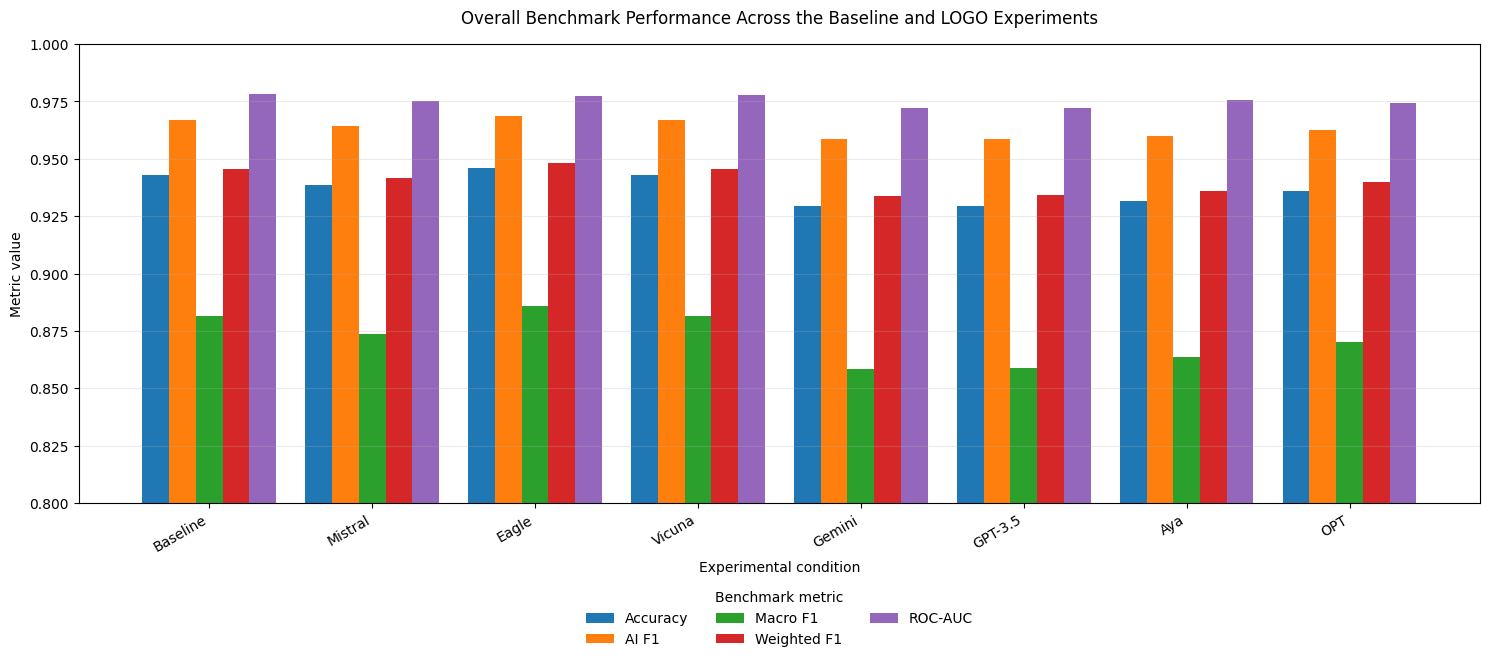

Overall-performance figure saved:
/content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Figures/overall_benchmark_performance.png
/content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Figures/overall_benchmark_performance.pdf


In [ ]:
# Visualise overall benchmark performance

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# Prepare the figure output directory

ANALYSIS_FIGURE_DIR = (
    COMPARISON_ROOT
    / "Figures"
)

ANALYSIS_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Prepare readable experiment labels

experiment_label_map = {
    "Baseline":
        "Baseline",

    "Mistral-7B-Instruct-v0.2":
        "Mistral",

    "v5-Eagle-7B-HF":
        "Eagle",

    "vicuna-13b":
        "Vicuna",

    "gemini":
        "Gemini",

    "gpt-3.5-turbo-0125":
        "GPT-3.5",

    "aya-101":
        "Aya",

    "opt-iml-max-30b":
        "OPT"
}


overall_performance_df = (
    analysis_results_df[
        [
            "Experiment",
            "Overall accuracy",
            "Overall AI F1",
            "Overall macro F1",
            "Overall weighted F1",
            "Overall ROC-AUC"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

overall_performance_df[
    "Display experiment"
] = (
    overall_performance_df[
        "Experiment"
    ]
    .map(experiment_label_map)
    .fillna(
        overall_performance_df[
            "Experiment"
        ]
    )
)


# Define the displayed metrics

performance_metrics = {
    "Overall accuracy":
        "Accuracy",

    "Overall AI F1":
        "AI F1",

    "Overall macro F1":
        "Macro F1",

    "Overall weighted F1":
        "Weighted F1",

    "Overall ROC-AUC":
        "ROC-AUC"
}


# Construct the grouped bar chart

experiment_positions = np.arange(
    len(overall_performance_df)
)

number_of_metrics = len(
    performance_metrics
)

total_group_width = 0.82

bar_width = (
    total_group_width
    / number_of_metrics
)


fig, ax = plt.subplots(
    figsize=(15, 7)
)


for metric_index, (
    metric_column,
    metric_label
) in enumerate(
    performance_metrics.items()
):

    position_offset = (
        metric_index
        - (number_of_metrics - 1) / 2
    ) * bar_width

    ax.bar(
        experiment_positions
        + position_offset,
        overall_performance_df[
            metric_column
        ],
        width=bar_width,
        label=metric_label
    )


# Format the chart

ax.set_title(
    "Overall Benchmark Performance Across "
    "the Baseline and LOGO Experiments",
    pad=15
)

ax.set_xlabel(
    "Experimental condition"
)

ax.set_ylabel(
    "Metric value"
)

ax.set_xticks(
    experiment_positions
)

ax.set_xticklabels(
    overall_performance_df[
        "Display experiment"
    ],
    rotation=30,
    ha="right"
)

# A restricted range makes the relatively small performance
# differences visible without changing the reported values.
ax.set_ylim(
    0.80,
    1.00
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    title="Benchmark metric",
    ncol=3,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.34),
    frameon=False
)

fig.tight_layout()


# Save the figure permanently

overall_performance_png = (
    ANALYSIS_FIGURE_DIR
    / "overall_benchmark_performance.png"
)

overall_performance_pdf = (
    ANALYSIS_FIGURE_DIR
    / "overall_benchmark_performance.pdf"
)

fig.savefig(
    overall_performance_png,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    overall_performance_pdf,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)


print(
    "Overall-performance figure saved:"
)

print(
    overall_performance_png
)

print(
    overall_performance_pdf
)

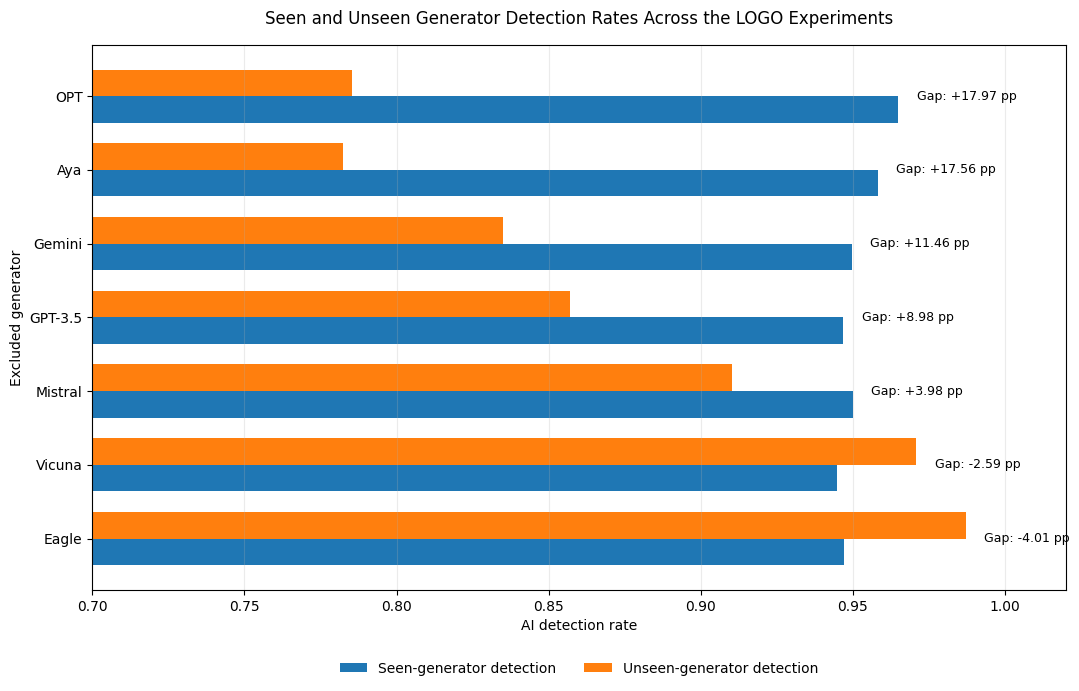

Generator-generalisation figure saved:
/content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Figures/seen_unseen_generator_detection.png
/content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Figures/seen_unseen_generator_detection.pdf


In [ ]:
# Visualise seen and unseen generator detection rates

generator_generalisation_plot_df = (
    logo_analysis_df[
        [
            "Excluded generator",
            "Seen-generator AI detection rate",
            "Unseen-generator AI detection rate",
            "Generalisation gap (pp)"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

generator_generalisation_plot_df[
    "Display generator"
] = (
    generator_generalisation_plot_df[
        "Excluded generator"
    ]
    .map(experiment_label_map)
    .fillna(
        generator_generalisation_plot_df[
            "Excluded generator"
        ]
    )
)


# Sort by generalisation gap
# The largest positive gaps appear at the top of the
# horizontal chart.

generator_generalisation_plot_df = (
    generator_generalisation_plot_df
    .sort_values(
        "Generalisation gap (pp)",
        ascending=True
    )
    .reset_index(drop=True)
)


generator_positions = np.arange(
    len(generator_generalisation_plot_df)
)

bar_height = 0.36


fig, ax = plt.subplots(
    figsize=(11, 7)
)


ax.barh(
    generator_positions
    - bar_height / 2,
    generator_generalisation_plot_df[
        "Seen-generator AI detection rate"
    ],
    height=bar_height,
    label="Seen-generator detection"
)

ax.barh(
    generator_positions
    + bar_height / 2,
    generator_generalisation_plot_df[
        "Unseen-generator AI detection rate"
    ],
    height=bar_height,
    label="Unseen-generator detection"
)


# Add generalisation-gap annotations

for row_index, row in (
    generator_generalisation_plot_df
    .iterrows()
):

    seen_rate = row[
        "Seen-generator AI detection rate"
    ]

    unseen_rate = row[
        "Unseen-generator AI detection rate"
    ]

    gap_pp = row[
        "Generalisation gap (pp)"
    ]

    annotation_position = (
        max(
            seen_rate,
            unseen_rate
        )
        + 0.006
    )

    ax.text(
        annotation_position,
        row_index,
        f"Gap: {gap_pp:+.2f} pp",
        va="center",
        fontsize=9
    )


# Format the chart

ax.set_title(
    "Seen and Unseen Generator Detection Rates "
    "Across the LOGO Experiments",
    pad=15
)

ax.set_xlabel(
    "AI detection rate"
)

ax.set_ylabel(
    "Excluded generator"
)

ax.set_yticks(
    generator_positions
)

ax.set_yticklabels(
    generator_generalisation_plot_df[
        "Display generator"
    ]
)

ax.set_xlim(
    0.70,
    1.02
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False
)

fig.tight_layout()


# Save the figure permanently

generator_detection_png = (
    ANALYSIS_FIGURE_DIR
    / "seen_unseen_generator_detection.png"
)

generator_detection_pdf = (
    ANALYSIS_FIGURE_DIR
    / "seen_unseen_generator_detection.pdf"
)

fig.savefig(
    generator_detection_png,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    generator_detection_pdf,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)


print(
    "Generator-generalisation figure saved:"
)

print(
    generator_detection_png
)

print(
    generator_detection_pdf
)

The reference baseline model achieved an overall accuracy of 0.9428, an AI-class F1-score of 0.9668 and a ROC-AUC of 0.9782. Across the seven leave-one-generator-out (LOGO) experiments, overall benchmark performance remained comparatively stable, with accuracy ranging from 0.9293 to 0.9459 and ROC-AUC values consistently exceeding 0.97. These results indicate that excluding a single generator during model development did not substantially reduce the model’s aggregate multilingual Human-versus-AI classification performance.

In contrast, considerably larger differences were observed in generator-specific generalisation performance. The largest positive generalisation gaps were obtained for OPT-IML-Max-30B (17.97 percentage points) and Aya-101 (17.56 percentage points), with unseen-generator detection rates of 0.7853 and 0.7825, respectively. Gemini and GPT-3.5-Turbo-0125 also exhibited notable reductions in unseen-generator detection, with generalisation gaps of 11.46 and 8.98 percentage points, respectively. By comparison, v5-Eagle-7B-HF and Vicuna-13B produced negative generalisation gaps, indicating that their unseen texts were detected more successfully than the pooled texts from generators represented during development.

Notably, Aya-101 and OPT-IML-Max-30B also produced the lowest generator-specific detection rates in the reference baseline condition. This suggests that their large LOGO gaps reflect both an underlying generator-specific detection difficulty and an additional loss associated with excluding them from model development, rather than arising solely from the unseen-generator condition.

Overall, these findings demonstrate that stable aggregate benchmark performance can coexist with substantial generator-specific differences in generalisation. The effect of excluding a generator is therefore not uniform across models, and aggregate metrics alone can conceal important weaknesses in unseen-generator robustness. The following analyses investigate whether these differences can be explained by dataset characteristics, including language composition, platform distribution and text-length properties, before examining model behaviour using feature-level explainability analyses.

## 19. Investigating Potential Sources of Generator-Specific Differences

The preceding analyses demonstrated that generator exclusion does not substantially affect overall benchmark performance, but that considerable differences emerge in generator-specific generalisation performance.

To better understand these differences, the following analyses examine several dataset characteristics that may contribute to the observed variation across generators. Specifically, language composition, platform composition and text-length characteristics are investigated to determine whether generators associated with larger generalisation gaps also exhibit noticeably different data distributions.

These analyses do not aim to establish causal relationships. Rather, they provide descriptive evidence regarding whether simple dataset-level characteristics are sufficient to explain the observed differences before subsequently examining model behaviour using prediction-confidence and feature-level explainability analyses.

### 19.1 Language Composition Across Generators

Language composition is examined first to determine whether generators associated with larger generalisation gaps also exhibit noticeably different language distributions.

The multilingual development partition is grouped by generator and language. Relative language frequencies are then visualised using a heatmap, allowing language distributions to be compared directly across generators. If generators exhibiting poor unseen generalisation are characterised by substantially different language compositions, language distribution may contribute to the observed differences. Conversely, broadly similar language distributions would suggest that other factors are more likely to explain the variation in generator-specific generalisation performance.

language,ar,bg,ca,cs,de,el,en,es,et,hr,hu,nl,pl,pt,ro,ru,uk,zh
multi_label,,,,,,,,,,,,,,,,,,
Mistral-7B-Instruct-v0.2,4.46,4.59,4.60,3.44,6.35,1.14,11.64,11.63,4.62,4.45,4.63,9.28,5.18,9.94,4.66,4.75,2.32,2.33
aya-101,4.74,4.51,4.31,3.36,6.56,1.13,11.94,11.72,4.47,4.32,4.51,9.55,4.94,9.99,4.47,4.84,2.30,2.33
gemini,4.73,4.67,2.70,3.49,6.47,1.18,11.83,11.83,4.71,4.53,4.73,9.43,5.27,10.12,4.75,4.83,2.37,2.37
gpt-3.5-turbo-0125,4.73,4.68,4.64,3.21,6.40,1.14,11.94,11.87,4.31,4.38,4.00,9.37,5.09,10.14,4.42,4.89,2.39,2.41
opt-iml-max-30b,4.89,5.00,4.45,3.27,6.40,1.08,11.79,12.11,3.76,4.30,3.79,9.52,4.88,10.35,4.49,4.99,2.36,2.56
v5-Eagle-7B-HF,4.59,4.57,4.61,3.42,6.32,1.15,11.56,11.61,4.61,4.44,4.64,9.29,5.19,9.95,4.66,4.71,2.32,2.34
vicuna-13b,4.72,4.58,4.31,3.45,6.40,1.18,11.65,11.55,4.59,4.40,4.59,9.24,5.19,10.01,4.67,4.80,2.32,2.36


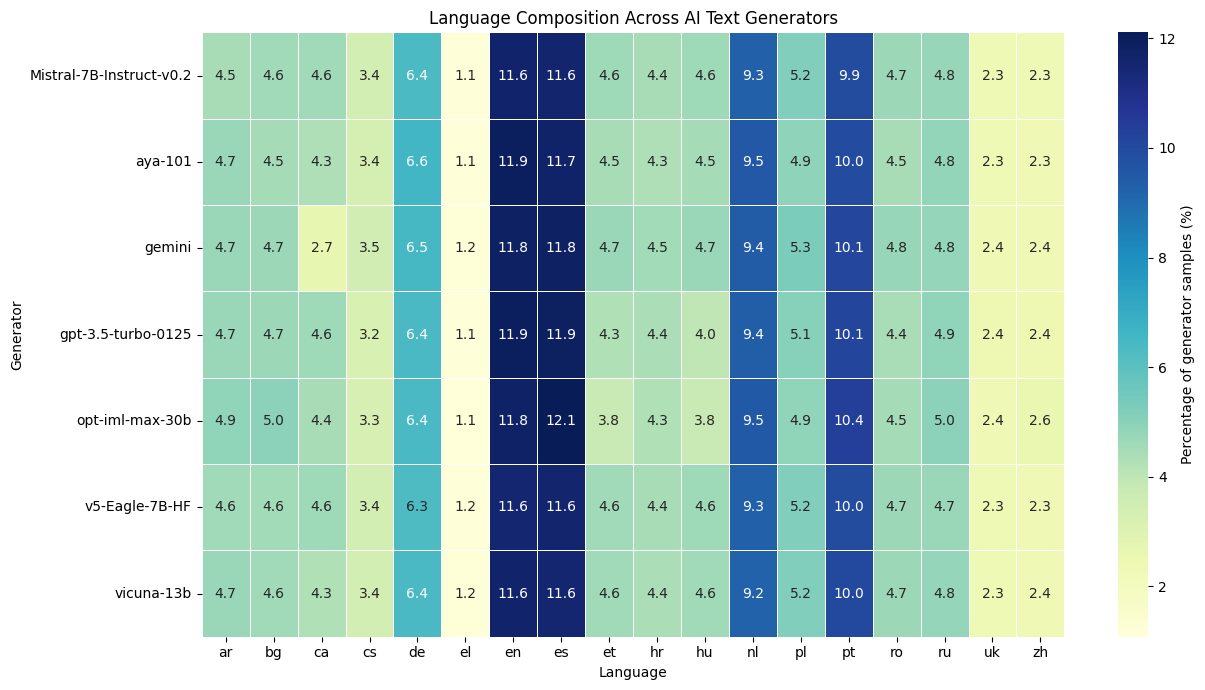

In [ ]:
# Language composition across generators

import matplotlib.pyplot as plt
import seaborn as sns


language_distribution_df = (
    train_df[
        train_df["label"] == AI_LABEL
    ]
    .groupby(
        [
            "multi_label",
            "language"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

language_distribution_percentage_df = (
    language_distribution_df.div(
        language_distribution_df.sum(axis=1),
        axis=0
    )
    * 100
)


display(
    language_distribution_percentage_df.round(2)
)


plt.figure(
    figsize=(13,7)
)

sns.heatmap(
    language_distribution_percentage_df,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={
        "label":
        "Percentage of generator samples (%)"
    }
)

plt.title(
    "Language Composition Across AI Text Generators"
)

plt.xlabel(
    "Language"
)

plt.ylabel(
    "Generator"
)

plt.tight_layout()

plt.show()

The language distributions of the seven AI text generators are broadly comparable. Across nearly all languages, the relative proportions differ only slightly between generators, with most differences remaining well below one percentage point. English and Spanish are consistently the largest language groups across all generators, while Greek and the two smallest language groups remain consistently underrepresented.

Despite these highly similar multilingual compositions, the LOGO experiments exhibit substantial variation in unseen-generator detection performance. For example, OPT-IML-Max-30B and Aya-101 produce the largest generalisation gaps, whereas v5-Eagle-7B-HF and Vicuna-13B exhibit the strongest unseen-generator transfer, despite having language distributions that closely resemble those of the remaining generators.

These findings suggest that differences in language composition alone are unlikely to account for the observed variation in generator-specific generalisation performance. Consequently, additional dataset characteristics are examined in the following sections.

### 19.2 Platform Composition Across Generators

The platform composition of the AI-generated development data is examined next to determine whether differences in social-media source distributions may contribute to the observed variation in generator-specific generalisation performance.

The multilingual development partition is grouped according to generator and platform. Relative platform frequencies are then visualised using a heatmap, allowing the platform distributions of the seven generators to be compared directly. If generators associated with larger generalisation gaps also exhibit substantially different platform compositions, platform distribution may contribute to the observed variation. Otherwise, similar platform distributions would indicate that other factors are more likely to explain the observed differences.

platform,discord,gab,telegram,twitter,whatsapp
multi_label,,,,,
Mistral-7B-Instruct-v0.2,25.08,14.75,40.01,14.21,5.94
aya-101,24.02,15.15,40.07,14.70,6.05
gemini,25.15,15.01,39.25,14.55,6.03
gpt-3.5-turbo-0125,24.30,15.13,39.76,14.73,6.08
opt-iml-max-30b,22.79,15.55,40.41,15.30,5.94
v5-Eagle-7B-HF,25.10,14.68,40.04,14.27,5.91
vicuna-13b,24.58,14.83,40.25,14.40,5.94


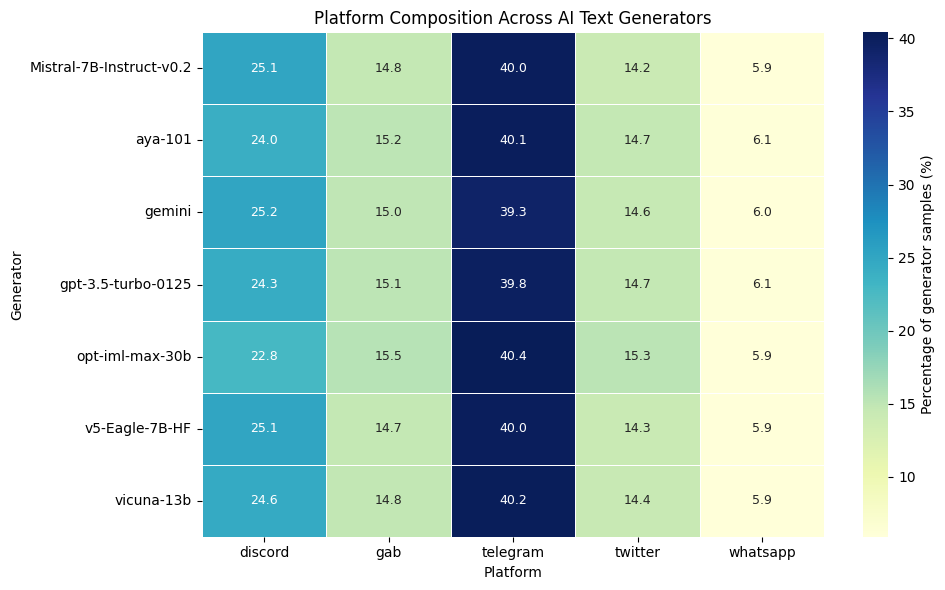

In [ ]:
# Platform composition across generators

import matplotlib.pyplot as plt
import seaborn as sns

platform_distribution_df = (
    train_df[
        train_df["label"] == AI_LABEL
    ]
    .groupby(
        [
            "multi_label",
            "platform"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

platform_distribution_percentage_df = (
    platform_distribution_df.div(
        platform_distribution_df.sum(axis=1),
        axis=0
    )
    * 100
)

display(
    platform_distribution_percentage_df.round(2)
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    platform_distribution_percentage_df,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    annot_kws={
        "size": 9
    },
    linewidths=0.5,
    cbar_kws={
        "label": "Percentage of generator samples (%)"
    }
)

plt.title(
    "Platform Composition Across AI Text Generators"
)

plt.xlabel("Platform")
plt.ylabel("Generator")

plt.tight_layout()

plt.show()

The platform distributions of the seven AI text generators are also highly comparable. Across all generators, Telegram consistently represents the largest proportion of AI-generated texts (approximately 39–40%), followed by Discord (approximately 23–25%), while Gab, Twitter and WhatsApp exhibit similarly consistent proportions across generators.

Despite these highly similar platform compositions, the LOGO experiments reveal substantial differences in unseen-generator detection performance. For example, OPT-IML-Max-30B and Aya-101 produce the largest generalisation gaps, whereas v5-Eagle-7B-HF and Vicuna-13B exhibit the strongest unseen-generator transfer, despite having platform distributions that closely resemble those of the remaining generators.

Taken together with the preceding language-composition analysis, these findings indicate that simple dataset-level characteristics, including language and platform composition, are unlikely to account for the observed variation in generator-specific generalisation performance. The following analysis therefore examines whether differences in text-length characteristics provide a more plausible explanation.

### 19.3 Text-Length Characteristics Across Generators

Token-length characteristics are examined next to determine whether differences in the length of AI-generated texts are associated with the observed variation in generator-specific generalisation performance.

For each AI text generator in the multilingual development partition, text length is measured using the number of tokens produced by the mDeBERTa tokenizer without truncation. Special tokens are included to remain consistent with the model’s tokenisation procedure. The mean token length is then calculated for each generator and combined with the corresponding LOGO generalisation gap.

The relationship between mean generator-level token length and generalisation gap is visualised using a scatter plot. If generators associated with larger generalisation gaps consistently produce substantially shorter or longer texts, text length may contribute to the observed variation. Conversely, the absence of a consistent relationship would suggest that additional characteristics beyond average token length are likely to influence unseen-generator generalisation.

In [ ]:
# Text-length characteristics across generators

ai_train_df = (
    train_df[
        train_df["label"] == AI_LABEL
    ]
    .copy()
)

# Calculate token length
ai_train_df["Token length"] = (
    ai_train_df["text"]
    .astype(str)
    .apply(
        lambda text: len(
            tokenizer(
                text,
                truncation=False,
                add_special_tokens=True
            )["input_ids"]
        )
    )
)

# Mean token length for each generator
generator_length_df = (
    ai_train_df
    .groupby("multi_label")["Token length"]
    .mean()
    .reset_index()
    .rename(columns={
        "multi_label": "Generator",
        "Token length": "Mean tokens"
    })
)

# Merge with LOGO results
generator_length_gap_df = (
    generator_length_df.merge(
        logo_analysis_df[
            [
                "Excluded generator",
                "Generalisation gap (pp)"
            ]
        ],
        left_on="Generator",
        right_on="Excluded generator",
        how="inner"
    )
    .drop(columns="Excluded generator")
)

display(
    generator_length_gap_df.round(2)
)

,Generator,Mean tokens,Generalisation gap (pp)
0,Mistral-7B-Instruct-v0.2,40.13,3.98
1,aya-101,25.14,17.56
2,gemini,147.07,11.46
3,gpt-3.5-turbo-0125,40.33,8.98
4,opt-iml-max-30b,19.56,17.97
5,v5-Eagle-7B-HF,42.78,-4.01
6,vicuna-13b,34.95,-2.59


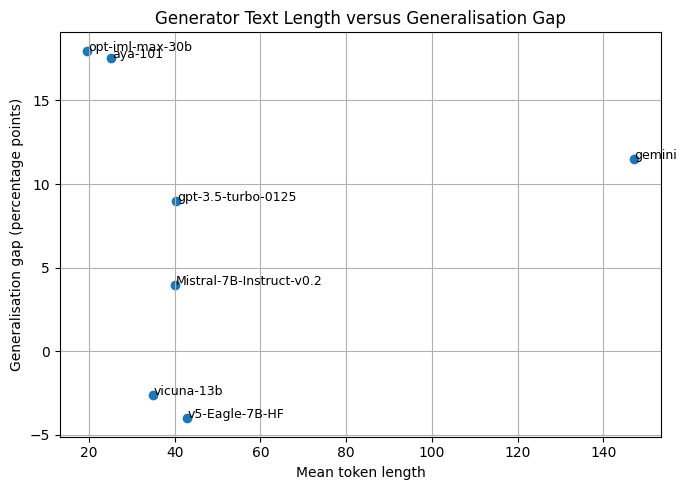

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    generator_length_gap_df["Mean tokens"],
    generator_length_gap_df["Generalisation gap (pp)"]
)

for _, row in generator_length_gap_df.iterrows():

    plt.text(
        row["Mean tokens"] + 0.2,
        row["Generalisation gap (pp)"],
        row["Generator"],
        fontsize=9
    )

plt.xlabel("Mean token length")

plt.ylabel("Generalisation gap (percentage points)")

plt.title(
    "Generator Text Length versus Generalisation Gap"
)

plt.grid(True)

plt.tight_layout()

plt.show()

The token-length analysis reveals considerably greater variation across generators than the preceding language- and platform-composition comparisons. Mean token lengths range from approximately 20 tokens for OPT-IML-Max-30B to more than 147 tokens for Gemini, indicating substantial generator-level differences in average text length.

However, mean token length does not exhibit a consistent descriptive relationship with generator-specific generalisation performance. OPT-IML-Max-30B and Aya-101 both generate comparatively short texts and produce the largest positive generalisation gaps. Nevertheless, Gemini also exhibits a notable reduction in unseen-generator detection despite having by far the highest mean token length. Conversely, v5-Eagle-7B-HF and Vicuna-13B achieve comparatively strong unseen-generator detection while occupying an intermediate region of the token-length distribution.

Gemini’s substantially greater mean token length is consistent with its distinctive generation characteristics reported in the MultiSocial benchmark. This difference previously motivated its treatment as an unseen evaluation generator in the reference development configuration. Within the present LOGO framework, however, Gemini is excluded only in its corresponding held-out condition, allowing its unseen performance to be compared consistently with that of the other generators.

Overall, the results do not support average token length as a sufficient standalone explanation for the observed variation in generator-specific generalisation. Large positive generalisation gaps occur for both relatively short-text generators, such as OPT-IML-Max-30B and Aya-101, and the substantially longer-text Gemini generator. Text length alone therefore does not appear sufficient to explain the observed differences, suggesting that additional generator-specific characteristics are likely to contribute. The subsequent analyses therefore examine prediction confidence and feature-level attribution patterns.


### 19.4 Prediction Confidence Across Generators

Prediction confidence is examined to determine whether the classifiers assign systematically lower AI-class probabilities to texts produced by generators excluded during model development.

For each LOGO experiment, the analysis is restricted to genuinely AI-generated benchmark samples. The probability assigned to the AI-generated class is compared between the excluded unseen generator and the pooled set of six generators represented during model development.

A lower mean AI-class probability for the unseen generator would indicate that the classifier is not only less successful at detecting that generator, but also less confident that its texts are AI-generated. This analysis uses the permanently saved benchmark predictions and does not repeat model training or inference.

,Excluded generator,Seen AI samples,Unseen AI samples,Mean seen AI probability,Mean unseen AI probability,Median seen AI probability,Median unseen AI probability,Mean confidence gap (pp)
0,Mistral-7B-Instruct-v0.2,105138,18351,0.9495,0.9095,1.0000,0.9999,4.00
1,v5-Eagle-7B-HF,105234,18255,0.9470,0.9867,1.0000,1.0000,-3.97
2,vicuna-13b,105417,18072,0.9437,0.9702,0.9999,0.9999,-2.65
3,gemini,106119,17370,0.9494,0.8351,1.0000,0.9999,11.44
4,gpt-3.5-turbo-0125,105836,17653,0.9468,0.8576,1.0000,0.9999,8.91
5,aya-101,106278,17211,0.9580,0.7817,1.0000,0.9998,17.63
6,opt-iml-max-30b,106912,16577,0.9649,0.7856,1.0000,0.9998,17.93


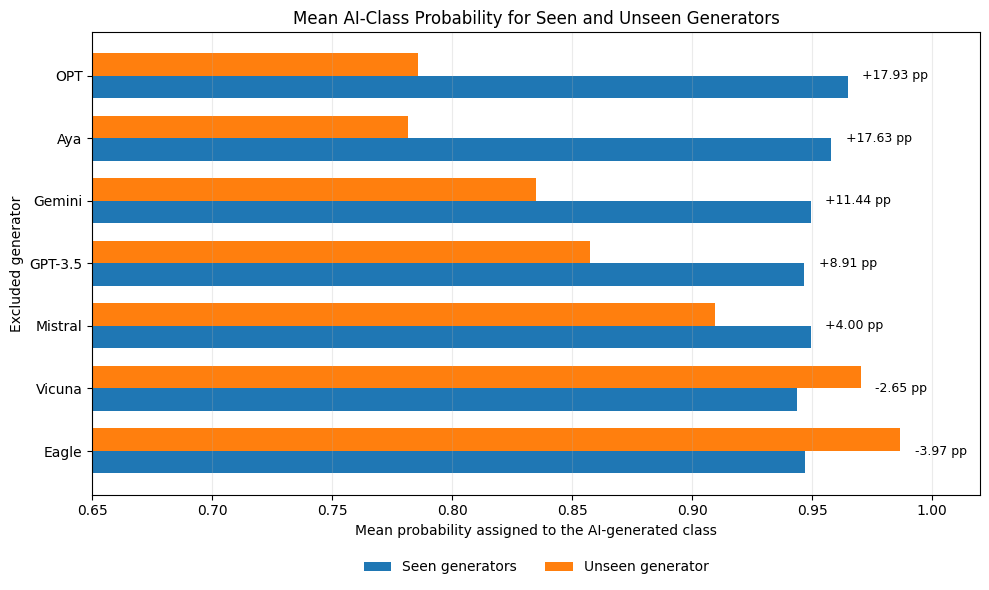


Prediction-confidence analysis completed.
Summary saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Prediction_Confidence/generator_confidence_summary.csv
Figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Prediction_Confidence/seen_unseen_prediction_confidence.png
Figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Prediction_Confidence/seen_unseen_prediction_confidence.pdf


In [ ]:
# Prediction confidence across generators

from pathlib import Path

# completed LOGO experiment

confidence_records = []
confidence_sample_frames = []

for excluded_generator in LOGO_GENERATORS:

    experiment_paths = create_experiment_paths(
        experiment_name=excluded_generator,
        excluded_generator=excluded_generator
    )

    predictions_path = Path(
        experiment_paths["predictions"]
    )

    if not predictions_path.exists():
        raise FileNotFoundError(
            "The saved prediction file could not be found for "
            f"'{excluded_generator}': {predictions_path}"
        )

    experiment_predictions_df = pd.read_parquet(
        predictions_path
    )

    required_prediction_columns = [
        "true_label",
        "multi_label",
        "ai_probability"
    ]

    missing_prediction_columns = [
        column
        for column in required_prediction_columns
        if column not in experiment_predictions_df.columns
    ]

    if missing_prediction_columns:
        raise ValueError(
            f"The saved predictions for '{excluded_generator}' "
            "are missing the following columns: "
            + ", ".join(missing_prediction_columns)
        )


    # Restrict confidence analysis to genuinely AI-generated
    # benchmark samples
    ai_predictions_df = (
        experiment_predictions_df[
            experiment_predictions_df[
                "true_label"
            ] == AI_LABEL
        ]
        .copy()
        .reset_index(drop=True)
    )

    if ai_predictions_df.empty:
        raise ValueError(
            f"No AI-generated benchmark samples were found for "
            f"'{excluded_generator}'."
        )


    # Mark the excluded generator as unseen and all remaining
    # generators as seen
    ai_predictions_df[
        "Generator condition"
    ] = np.where(
        ai_predictions_df[
            "multi_label"
        ].eq(excluded_generator),
        "Unseen",
        "Seen"
    )

    ai_predictions_df[
        "Excluded generator"
    ] = excluded_generator

    confidence_sample_frames.append(
        ai_predictions_df[
            [
                "Excluded generator",
                "multi_label",
                "Generator condition",
                "ai_probability"
            ]
        ]
    )


    seen_probabilities = (
        ai_predictions_df.loc[
            ai_predictions_df[
                "Generator condition"
            ] == "Seen",
            "ai_probability"
        ]
    )

    unseen_probabilities = (
        ai_predictions_df.loc[
            ai_predictions_df[
                "Generator condition"
            ] == "Unseen",
            "ai_probability"
        ]
    )

    if unseen_probabilities.empty:
        raise ValueError(
            "No unseen-generator benchmark samples were found "
            f"for '{excluded_generator}'."
        )

    if seen_probabilities.empty:
        raise ValueError(
            "No seen-generator benchmark samples were found "
            f"for '{excluded_generator}'."
        )


    confidence_records.append({
        "Excluded generator":
            excluded_generator,

        "Seen AI samples":
            int(len(seen_probabilities)),

        "Unseen AI samples":
            int(len(unseen_probabilities)),

        "Mean seen AI probability":
            float(seen_probabilities.mean()),

        "Mean unseen AI probability":
            float(unseen_probabilities.mean()),

        "Median seen AI probability":
            float(seen_probabilities.median()),

        "Median unseen AI probability":
            float(unseen_probabilities.median()),

        "Seen AI probability standard deviation":
            float(seen_probabilities.std()),

        "Unseen AI probability standard deviation":
            float(unseen_probabilities.std()),

        "Mean confidence gap (pp)":
            float(
                (
                    seen_probabilities.mean()
                    - unseen_probabilities.mean()
                )
                * 100
            )
    })


# Combine and validate the confidence results

generator_confidence_df = pd.DataFrame(
    confidence_records
)

generator_confidence_samples_df = pd.concat(
    confidence_sample_frames,
    ignore_index=True
)

generator_order = {
    generator: index
    for index, generator in enumerate(
        LOGO_GENERATORS
    )
}

generator_confidence_df["_order"] = (
    generator_confidence_df[
        "Excluded generator"
    ]
    .map(generator_order)
)

generator_confidence_df = (
    generator_confidence_df
    .sort_values("_order")
    .drop(columns="_order")
    .reset_index(drop=True)
)


assert len(generator_confidence_df) == len(LOGO_GENERATORS)

assert (
    set(
        generator_confidence_df[
            "Excluded generator"
        ]
    )
    ==
    set(LOGO_GENERATORS)
)

assert generator_confidence_df[
    "Mean seen AI probability"
].between(0.0, 1.0).all()

assert generator_confidence_df[
    "Mean unseen AI probability"
].between(0.0, 1.0).all()


# Add readable generator labels

confidence_label_map = {
    "Mistral-7B-Instruct-v0.2":
        "Mistral",

    "v5-Eagle-7B-HF":
        "Eagle",

    "vicuna-13b":
        "Vicuna",

    "gemini":
        "Gemini",

    "gpt-3.5-turbo-0125":
        "GPT-3.5",

    "aya-101":
        "Aya",

    "opt-iml-max-30b":
        "OPT"
}

generator_confidence_df[
    "Display generator"
] = (
    generator_confidence_df[
        "Excluded generator"
    ]
    .map(confidence_label_map)
    .fillna(
        generator_confidence_df[
            "Excluded generator"
        ]
    )
)


# Display the numerical confidence summary

display(
    generator_confidence_df[
        [
            "Excluded generator",
            "Seen AI samples",
            "Unseen AI samples",
            "Mean seen AI probability",
            "Mean unseen AI probability",
            "Median seen AI probability",
            "Median unseen AI probability",
            "Mean confidence gap (pp)"
        ]
    ]
    .style
    .format({
        "Mean seen AI probability":
            "{:.4f}",

        "Mean unseen AI probability":
            "{:.4f}",

        "Median seen AI probability":
            "{:.4f}",

        "Median unseen AI probability":
            "{:.4f}",

        "Mean confidence gap (pp)":
            "{:.2f}"
    })
)


# Visualise mean seen and unseen AI probabilities

plot_confidence_df = (
    generator_confidence_df
    .sort_values(
        "Mean confidence gap (pp)",
        ascending=True
    )
    .reset_index(drop=True)
)

generator_positions = np.arange(
    len(plot_confidence_df)
)

bar_height = 0.36


fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    generator_positions
    - bar_height / 2,
    plot_confidence_df[
        "Mean seen AI probability"
    ],
    height=bar_height,
    label="Seen generators"
)

ax.barh(
    generator_positions
    + bar_height / 2,
    plot_confidence_df[
        "Mean unseen AI probability"
    ],
    height=bar_height,
    label="Unseen generator"
)


# Add confidence-gap labels
for row_index, row in plot_confidence_df.iterrows():

    annotation_x = (
        max(
            row["Mean seen AI probability"],
            row["Mean unseen AI probability"]
        )
        + 0.006
    )

    ax.text(
        annotation_x,
        row_index,
        (
            f"{row['Mean confidence gap (pp)']:+.2f} pp"
        ),
        va="center",
        fontsize=9
    )


ax.set_title(
    "Mean AI-Class Probability for Seen and "
    "Unseen Generators"
)

ax.set_xlabel(
    "Mean probability assigned to the AI-generated class"
)

ax.set_ylabel(
    "Excluded generator"
)

ax.set_yticks(
    generator_positions
)

ax.set_yticklabels(
    plot_confidence_df[
        "Display generator"
    ]
)

ax.set_xlim(
    0.65,
    1.02
)

ax.grid(
    axis="x",
    alpha=0.25
)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    frameon=False
)

fig.tight_layout()


# Save the confidence summary and figure permanently

CONFIDENCE_ANALYSIS_DIR = (
    COMPARISON_ROOT
    / "Prediction_Confidence"
)

CONFIDENCE_ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

confidence_summary_path = (
    CONFIDENCE_ANALYSIS_DIR
    / "generator_confidence_summary.csv"
)

confidence_figure_png = (
    CONFIDENCE_ANALYSIS_DIR
    / "seen_unseen_prediction_confidence.png"
)

confidence_figure_pdf = (
    CONFIDENCE_ANALYSIS_DIR
    / "seen_unseen_prediction_confidence.pdf"
)

save_dataframe_atomic(
    dataframe=generator_confidence_df,
    output_path=confidence_summary_path
)

fig.savefig(
    confidence_figure_png,
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    confidence_figure_pdf,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


print(
    "\nPrediction-confidence analysis completed."
)

print(
    "Summary saved:",
    confidence_summary_path
)

print(
    "Figure saved:",
    confidence_figure_png
)

print(
    "Figure saved:",
    confidence_figure_pdf
)

Prediction confidence closely mirrors the generator-specific generalisation behaviour observed in the preceding analyses. Across the seven LOGO experiments, the mean confidence gap follows the corresponding generalisation gap very closely. Where unseen-generator detection declines, the mean probability assigned to the AI-generated class decreases by a similar amount. Conversely, generators exhibiting negative generalisation gaps also receive higher mean AI-class probabilities when evaluated as unseen generators.

The largest confidence reductions occur for OPT-IML-Max-30B and Aya-101. In both cases, the mean probability assigned to the AI-generated class is approximately 17.6–17.9 percentage points lower for the unseen generator than for the pooled generators represented during model development. Gemini and GPT-3.5-Turbo-0125 also exhibit substantial confidence reductions of 11.44 and 8.91 percentage points, respectively, while Mistral-7B-Instruct-v0.2 produces a smaller reduction of 4.00 percentage points. By contrast, v5-Eagle-7B-HF and Vicuna-13B display negative confidence gaps of −3.97 and −2.65 percentage points, indicating that the classifiers assign higher mean AI-class probabilities to these generators when they are excluded from development than to the pooled set of seen generators.

Median AI-class probabilities remain close to one under both seen and unseen conditions. This indicates that at least half of the AI-generated benchmark texts receive very high AI-class probabilities across all LOGO experiments. However, the substantially lower mean probabilities observed for the more difficult unseen generators suggest that a subset of their texts receives markedly lower AI-class confidence. These lower-confidence predictions increase the likelihood that such samples fall below the classification threshold and are consequently misclassified as Human-written.

Overall, the analysis shows that generator-specific detection losses are accompanied by closely corresponding shifts in prediction confidence. The LOGO differences therefore reflect not only changes in the number of classification errors but also changes in the probability assigned to the correct AI-generated class. Nevertheless, the confidence analysis remains descriptive and does not independently explain which characteristics of the unseen texts produce these shifts. Having established that simple dataset-level characteristics do not consistently account for the observed generalisation differences, the following section uses SHAP-based feature-level explainability to investigate the textual features underlying the contrasting generator-specific behaviours.


# 20 SHAP-Based Feature-Level Explainability

SHAP (SHapley Additive exPlanations) is employed to investigate the textual features that most strongly influence the predictions of the fine-tuned multilingual classifier. Whereas the preceding analyses examined whether generator-specific differences could be explained by dataset-level characteristics such as language composition, platform composition, text length and prediction confidence, SHAP provides a feature-level interpretation of the model's decision-making process.

The following analyses first examine the global feature importance learned by the classifier before investigating whether the model relies on different textual features when processing generators associated with stronger or weaker generalisation performance.

### 20.1 Construct the SHAP Evaluation Sample

SHAP explanations are generated using a reproducibly sampled subset of the benchmark test partition. Because token-level SHAP computation is computationally expensive for transformer-based models, explainability is performed on a controlled subset rather than the complete benchmark test set.

Consistent with the explainability strategy adopted in the preceding experiments, equal numbers of Human-written and AI-generated texts are sampled without conditioning on prediction correctness. This class-balanced design prevents the substantially larger AI-generated class from dominating the aggregated feature-importance estimates while retaining broad multilingual coverage of the benchmark evaluation data.

Using a fixed random seed, 100 Human-written and 100 AI-generated benchmark texts are sampled and subsequently shuffled to construct a 200-text global explainability subset. The resulting subset serves as the evaluation sample for the global SHAP analyses presented in the following sections.

In [ ]:
# Construct the SHAP Evaluation Sample

SHAP_RANDOM_STATE = 42
GLOBAL_SHAP_PER_CLASS = 100

human_shap_pool = (
    test_df[
        test_df["label"] == HUMAN_LABEL
    ]
    .copy()
)

ai_shap_pool = (
    test_df[
        test_df["label"] == AI_LABEL
    ]
    .copy()
)

global_human_sample = human_shap_pool.sample(
    n=GLOBAL_SHAP_PER_CLASS,
    random_state=SHAP_RANDOM_STATE
)

global_ai_sample = ai_shap_pool.sample(
    n=GLOBAL_SHAP_PER_CLASS,
    random_state=SHAP_RANDOM_STATE
)

global_shap_df = (
    pd.concat(
        [
            global_human_sample,
            global_ai_sample
        ],
        ignore_index=True
    )
    .sample(
        frac=1,
        random_state=SHAP_RANDOM_STATE
    )
    .reset_index(drop=True)
)

print(
    "Global SHAP sample size:",
    len(global_shap_df)
)

print("\nClass distribution:")

display(
    global_shap_df["label"]
    .value_counts()
    .rename(
        index={
            HUMAN_LABEL: "Human",
            AI_LABEL: "AI"
        }
    )
)

global_shap_language_distribution = (
    global_shap_df["language"]
    .value_counts()
    .rename_axis("Language")
    .reset_index(name="Samples")
)

display(
    global_shap_language_distribution
)

print(
    "Languages represented:",
    global_shap_df["language"].nunique()
)

assert len(global_shap_df) == 200

assert (
    global_shap_df["label"]
    .value_counts()
    .loc[HUMAN_LABEL]
    ==
    GLOBAL_SHAP_PER_CLASS
)

assert (
    global_shap_df["label"]
    .value_counts()
    .loc[AI_LABEL]
    ==
    GLOBAL_SHAP_PER_CLASS
)

print(
    "\nGlobal SHAP sampling completed successfully."
)

Global SHAP sample size: 200

Class distribution:


,count
label,
Human,100
AI,100


,Language,Samples
0,es,19
1,de,16
2,en,16
3,nl,16
4,pt,16
5,ar,15
6,hu,13
7,ca,11
8,et,10
9,ru,10


Languages represented: 21

Global SHAP sampling completed successfully.


A reproducible, class-balanced SHAP evaluation subset containing 200 benchmark texts was successfully constructed. The subset contains equal numbers of Human-written and AI-generated samples and was created without conditioning on whether the texts were classified correctly or incorrectly.

Twenty-one languages are represented within the subset, providing broad multilingual coverage for the subsequent global explainability analyses. However, because sampling was balanced by class rather than stratified by language, the number of samples varies across languages and the resulting SHAP summaries should not be interpreted as equally weighted language-level estimates. The lower representation of several languages reflects their limited presence in the benchmark test partition and the random sampling procedure.

Overall, the subset provides a computationally feasible basis for examining global model behaviour while reducing the risk that the substantially larger AI-generated benchmark class dominates the aggregated attribution results.


### 20.2 Configure the SHAP Prediction Function

SHAP requires a prediction function that returns class probabilities for arbitrary input texts. The prediction function reuses the fine-tuned multilingual baseline classifier together with the tokenizer and maximum sequence length adopted during model training.

To ensure consistency with benchmark evaluation, input texts are tokenised using padding, truncation and the predefined maximum sequence length before being passed through the classifier in evaluation mode without gradient computation. The resulting model logits are converted into class probabilities using the softmax function.

The returned probability distributions correspond to the Human-written and AI-generated output classes of the trained classifier and provide the model outputs required for the subsequent SHAP analyses.

In [ ]:
# Configure the SHAP Prediction Function

from scipy.special import softmax


# Load the permanently saved baseline model

baseline_paths = create_experiment_paths(
    experiment_name="Baseline",
    excluded_generator=None
)

shap_model = load_saved_experiment_model(
    baseline_paths
)

shap_model.eval()


# SHAP prediction function

def shap_prediction_function(texts):

    encoded_batch = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    if torch.cuda.is_available():

        encoded_batch = {
            key: value.cuda()
            for key, value in encoded_batch.items()
        }

        shap_model.cuda()

    with torch.no_grad():

        logits = shap_model(
            **encoded_batch
        ).logits

    probabilities = softmax(
        logits.detach().cpu().numpy(),
        axis=1
    )

    return probabilities


print(
    "SHAP prediction function configured successfully."
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

SHAP prediction function configured successfully.


### 20.3 Initialise and Validate the SHAP Text Explainer

A text-based SHAP explainer is initialised using the multilingual mDeBERTa tokenizer and the previously configured prediction function. The explainer uses SHAP’s Partition algorithm together with a text masker to estimate token-level contributions to the classifier’s Human-written and AI-generated output probabilities.

Before explanations are generated for the full SHAP evaluation subset, the explainability pipeline is validated using two benchmark texts. For each validation example, the generated attribution matrix is checked to confirm that token-level SHAP values are returned for both output classes, that the number of token representations matches the number of attribution rows, and that no missing or infinite values are present.

The validation examples are used only to verify that the SHAP pipeline operates correctly and are not included in the substantive interpretation of model behaviour.

In [ ]:
# Initialise and Validate the SHAP Text Explainer

import shap


# Initialise the text masker

shap_text_masker = shap.maskers.Text(
    tokenizer
)


# Initialise the SHAP explainer

shap_explainer = shap.Explainer(
    shap_prediction_function,
    masker=shap_text_masker,
    output_names=[
        "Human",
        "AI"
    ],
    algorithm="partition"
)


# Select a very small validation subset

shap_validation_texts = (
    global_shap_df["text"]
    .astype(str)
    .iloc[:2]
    .tolist()
)


# Generate validation explanations

shap_validation_values = shap_explainer(
    shap_validation_texts
)


# Validate the generated SHAP outputs

if len(shap_validation_values) != len(
    shap_validation_texts
):
    raise ValueError(
        "The number of generated SHAP explanations does not "
        "match the number of validation texts."
    )


for sample_index in range(
    len(shap_validation_values)
):

    sample_values = np.asarray(
        shap_validation_values[
            sample_index
        ].values,
        dtype=float
    )

    sample_tokens = np.asarray(
        shap_validation_values[
            sample_index
        ].data
    )

    if sample_values.ndim != 2:
        raise ValueError(
            "Unexpected SHAP value dimensionality for "
            f"validation sample {sample_index + 1}: "
            f"{sample_values.shape}"
        )

    if sample_values.shape[1] != 2:
        raise ValueError(
            "SHAP did not return contributions for both "
            f"output classes in sample {sample_index + 1}."
        )

    if len(sample_tokens) != sample_values.shape[0]:
        raise ValueError(
            "The number of token representations does not "
            "match the number of token-level SHAP values."
        )

    if np.isnan(sample_values).any():
        raise ValueError(
            "NaN values were detected in the SHAP validation "
            f"output for sample {sample_index + 1}."
        )

    if np.isinf(sample_values).any():
        raise ValueError(
            "Infinite values were detected in the SHAP "
            f"validation output for sample {sample_index + 1}."
        )

    print(
        f"Validation sample {sample_index + 1}"
    )

    print(
        "Tokens:",
        len(sample_tokens)
    )

    print(
        "SHAP shape:",
        sample_values.shape
    )

    print(
        "NaN present:",
        np.isnan(sample_values).any()
    )

    print(
        "Infinite values present:",
        np.isinf(sample_values).any()
    )

    print("-" * 50)


print(
    "SHAP text explainer initialised and validated "
    "successfully."
)

Validation sample 1
Tokens: 8
SHAP shape: (8, 2)
NaN present: False
Infinite values present: False
--------------------------------------------------
Validation sample 2
Tokens: 32
SHAP shape: (32, 2)
NaN present: False
Infinite values present: False
--------------------------------------------------
SHAP text explainer initialised and validated successfully.


### 20.4 Compute Global SHAP Explanations

Token-level SHAP values are computed for all 200 texts in the class-balanced global explainability subset.

The validated Partition explainer is applied consistently to every sampled benchmark text. For each token, SHAP returns separate contribution values for the Human-written and AI-generated outputs. These explanations provide the basis for the subsequent global feature-importance and directional analyses.

Because transformer-based SHAP computation is computationally expensive, this stage may require several minutes. No model training or benchmark inference is repeated.

In [ ]:
# Compute Global SHAP Explanations

global_shap_texts = (
    global_shap_df["text"]
    .astype(str)
    .tolist()
)

print(
    "Global SHAP computation started."
)

print(
    "Texts to explain:",
    len(global_shap_texts)
)


global_shap_values = shap_explainer(
    global_shap_texts
)


# Validate the complete SHAP output

if len(global_shap_values) != len(
    global_shap_texts
):
    raise ValueError(
        "The number of generated global SHAP explanations "
        "does not match the number of sampled texts."
    )


global_shap_token_count = 0

for sample_index in range(
    len(global_shap_values)
):

    sample_values = np.asarray(
        global_shap_values[
            sample_index
        ].values,
        dtype=float
    )

    sample_tokens = np.asarray(
        global_shap_values[
            sample_index
        ].data
    )

    if sample_values.ndim != 2:
        raise ValueError(
            "Unexpected SHAP dimensionality for global "
            f"sample {sample_index + 1}: "
            f"{sample_values.shape}"
        )

    if sample_values.shape[1] != 2:
        raise ValueError(
            "Global SHAP output does not contain values for "
            f"both classes in sample {sample_index + 1}."
        )

    if len(sample_tokens) != sample_values.shape[0]:
        raise ValueError(
            "Token and SHAP-value counts do not match for "
            f"global sample {sample_index + 1}."
        )

    if np.isnan(sample_values).any():
        raise ValueError(
            "NaN values were detected in global SHAP sample "
            f"{sample_index + 1}."
        )

    if np.isinf(sample_values).any():
        raise ValueError(
            "Infinite values were detected in global SHAP "
            f"sample {sample_index + 1}."
        )

    global_shap_token_count += len(
        sample_tokens
    )


print(
    "\nGlobal SHAP explanations generated:",
    len(global_shap_values)
)

print(
    "Total token occurrences explained:",
    f"{global_shap_token_count:,}"
)

print(
    "Global SHAP computation completed successfully."
)

Global SHAP computation started.
Texts to explain: 200


  0%|          | 0/498 [00:00<?, ?it/s]


Global SHAP explanations generated: 200
Total token occurrences explained: 7,835
Global SHAP computation completed successfully.


### 20.5 Global Feature Importance

Global feature importance is examined by aggregating absolute SHAP values across the class-balanced multilingual explainability subset. For each token representation, the absolute SHAP attribution associated with the AI-generated output class is extracted. Mean absolute SHAP is then calculated across all occurrences of the same token, quantifying the average strength of its contribution irrespective of whether it increases or decreases the probability assigned to the AI-generated class.

This analysis provides a descriptive overview of the classifier's overall feature reliance. Because the explainability subset contains multiple languages with unequal language frequencies, language-specific lexical tokens appearing in the global ranking are not interpreted as universal multilingual indicators.

Token representations produced by SHAP are retained without additional normalisation. This preserves tokenisation boundaries, spelling variation, punctuation and other stylistic features that may contribute to the classifier's decisions. Empty-string token representations are excluded.

To reduce the influence of completely isolated features, token representations occurring fewer than three times within the global explainability subset are omitted from the aggregated ranking. This filtering does not reduce the number of token occurrences used to generate the SHAP explanations; rather, it restricts the final feature ranking to tokenizer units observed at least three times. Because a threshold of three remains relatively permissive, features with low occurrence counts are interpreted cautiously. For each retained token, the number of occurrences, mean absolute SHAP and maximum absolute SHAP are reported.

Token occurrences analysed: 7435
Unique tokens before occurrence filtering: 3594
Unique tokens retained after occurrence filtering: 343


,Token,Token type,Occurrences,Mean_Absolute_SHAP,Maximum_Absolute_SHAP
0,De,Lexical,3,0.301955,0.584231
1,és,Lexical,3,0.299958,0.558894
2,"!""",Non-lexical,3,0.216675,0.343695
3,ă,Lexical,6,0.176676,0.541122
4,。,Non-lexical,3,0.173508,0.364041
5,co,Lexical,7,0.152918,0.432330
6,[,Non-lexical,20,0.145019,0.492044
7,zia,Lexical,3,0.129187,0.243082
8,ste,Lexical,3,0.127051,0.363902
9,"""",Non-lexical,5,0.126018,0.463043


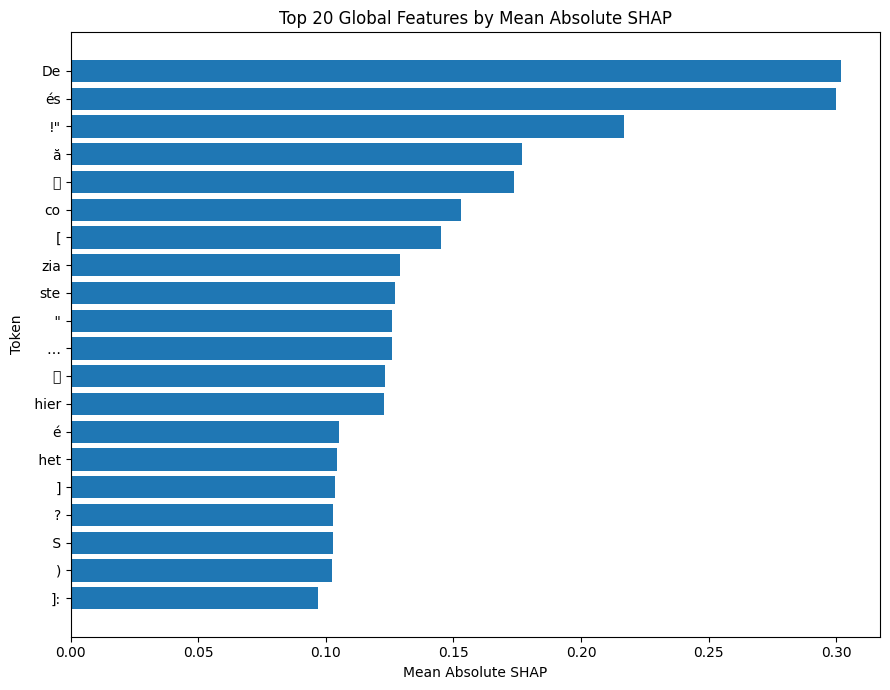

In [ ]:
# Global Feature Importance

MIN_GLOBAL_TOKEN_OCCURRENCES = 3

global_absolute_records = []

for sample_idx in range(len(global_shap_values)):

    sample_values = np.asarray(
        global_shap_values[sample_idx].values,
        dtype=float
    )

    sample_tokens = np.asarray(
        global_shap_values[sample_idx].data
    )

    # Absolute attribution for AI class
    ai_absolute_shap = np.abs(
        sample_values[:, AI_LABEL]
    )

    for token, shap_value in zip(
        sample_tokens,
        ai_absolute_shap
    ):

        global_absolute_records.append({

            "Token":
                str(token),

            "Absolute SHAP":
                float(shap_value)

        })

global_absolute_df = pd.DataFrame(
    global_absolute_records
)


# Remove empty technical entries

global_absolute_df = (
    global_absolute_df[
        global_absolute_df["Token"] != ""
    ]
    .reset_index(drop=True)
)

print(
    "Token occurrences analysed:",
    len(global_absolute_df)
)

# Aggregate SHAP values

global_absolute_summary_all_df = (

    global_absolute_df

    .groupby(
        "Token",
        as_index=False
    )

    .agg(

        Occurrences=(
            "Token",
            "size"
        ),

        Mean_Absolute_SHAP=(
            "Absolute SHAP",
            "mean"
        ),

        Maximum_Absolute_SHAP=(
            "Absolute SHAP",
            "max"
        )

    )

    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )

    .reset_index(drop=True)

)

print(
    "Unique tokens before occurrence filtering:",
    len(global_absolute_summary_all_df)
)

# Occurrence filtering

global_absolute_summary_df = (

    global_absolute_summary_all_df[

        global_absolute_summary_all_df[
            "Occurrences"
        ]
        >=
        MIN_GLOBAL_TOKEN_OCCURRENCES

    ]

    .reset_index(drop=True)

)

print(
    "Unique tokens retained after occurrence filtering:",
    len(global_absolute_summary_df)
)

# Classify lexical vs non-lexical

def classify_token_type(token):

    if any(
        character.isalpha()
        for character in token
    ):
        return "Lexical"

    return "Non-lexical"


global_absolute_summary_df["Token type"] = (

    global_absolute_summary_df["Token"]

    .apply(classify_token_type)

)

# Display top features

display(

    global_absolute_summary_df[
        [

            "Token",

            "Token type",

            "Occurrences",

            "Mean_Absolute_SHAP",

            "Maximum_Absolute_SHAP"

        ]
    ]

    .head(30)

)

# Plot

TOP_N_GLOBAL_FEATURES = 20

top_global_features_df = (

    global_absolute_summary_df

    .head(TOP_N_GLOBAL_FEATURES)

    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=True
    )

)

plt.figure(figsize=(9,7))

plt.barh(

    top_global_features_df["Token"],

    top_global_features_df[
        "Mean_Absolute_SHAP"
    ]

)

plt.xlabel(
    "Mean Absolute SHAP"
)

plt.ylabel(
    "Token"
)

plt.title(
    "Top 20 Global Features by Mean Absolute SHAP"
)

plt.tight_layout()

plt.show()

The global SHAP analysis covers 7,435 token occurrences across the 200-text multilingual explainability subset. Before occurrence filtering, these correspond to 3,594 unique token representations. Applying a minimum occurrence threshold of three retains 343 recurrent tokenizer units. The filter removes tokens observed only once or twice, but it remains relatively permissive and therefore does not eliminate all low-frequency multilingual fragments.

The resulting ranking contains both lexical and non-lexical features. Several punctuation and formatting-related representations receive comparatively high mean absolute SHAP values, including square brackets, quotation marks, ellipses, closing brackets, question marks, parentheses and hashtags. The recurrent `USER` representation also appears among the more influential features. These results indicate that the classifier relies not only on lexical content but also on punctuation, formatting conventions and social-media-related structural cues when distinguishing Human-written from AI-generated texts.

The ranking also contains multilingual characters and subword fragments such as `ă`, `co`, `这`, `é`, `het`, `ت` and `При`. Their presence reflects the shared multilingual subword tokenizer and the linguistic diversity of the explainability subset. Because several highly ranked lexical features occur only three or four times, their high mean absolute SHAP values may be sensitive to a small number of contexts. They should therefore be treated as exploratory tokenizer-level features rather than universal multilingual indicators of AI-generated text.

Some visually identical punctuation features, including square brackets and quotation marks, appear more than once with different occurrence counts and attribution values. This is consistent with retaining the original SHAP token representations without additional normalisation. Tokens that appear visually identical may differ in whitespace, tokenisation boundaries or other underlying representation details and are therefore retained as separate model features.

Overall, the global ranking suggests that the multilingual classifier draws on a combination of lexical, punctuation-based, formatting-related and social-media-specific cues. However, absolute SHAP values describe the strength of feature reliance without indicating whether a feature pushes the prediction towards the AI-generated or Human-written class. In addition, this aggregated analysis does not explain why generalisation performance differs across individual generators. The following generator-specific and directional SHAP analyses therefore examine whether stronger and weaker generalisation conditions differ in attribution magnitude, feature type and contribution direction.

## 20.6 Generator - Specific SHAP Analysis

The preceding global SHAP analysis provided an overall view of the features learned by the multilingual classifier. However, the LOGO experiments demonstrated substantial variation in unseen-generator generalisation, indicating that global feature importance alone is insufficient to explain these differences.

The following analyses therefore focus on four representative LOGO conditions selected from the strongest and weakest generalisation outcomes. After constructing language-matched SHAP evaluation subsets, attribution magnitude, feature-type composition and directional feature contributions are compared to investigate how feature-level model behaviour differs between strong and weak unseen-generator generalisation.

### 20.6.1 Selection of Representative LOGO Experiments

Computing SHAP explanations for every LOGO experiment would produce a substantial amount of highly repetitive output while providing limited additional insight. Instead, four representative LOGO conditions were selected to investigate the feature-level mechanisms underlying generator-specific generalisation.

The two experiments with the smallest generalisation gaps, v5-Eagle-7B-HF and Vicuna-13B, were selected to represent comparatively strong unseen-generator generalisation. These were compared with OPT-IML-Max-30B and Aya-101, which exhibited the two largest positive generalisation gaps and therefore represented comparatively weak unseen-generator generalisation.

Selecting two experiments from each performance extreme reduces the likelihood of interpreting behaviour specific to a single generator as a broader pattern while maintaining a computationally feasible explainability analysis. The baseline model is retained as the reference for the global SHAP analysis presented in the previous section but is not included in the generator-specific comparison because all seven generators were represented during its development.

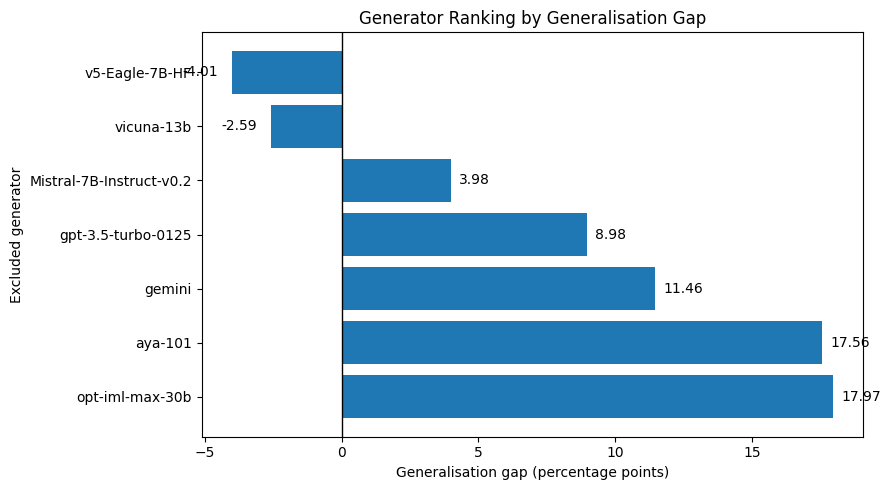

In [ ]:
# Generator Generalisation Ranking


generator_gap_df = (
    final_experiment_results_df[
        final_experiment_results_df["Experiment"] != "Baseline"
    ][
        [
            "Excluded generator",
            "Generalisation gap (pp)"
        ]
    ]
    .sort_values(
        "Generalisation gap (pp)",
        ascending=False
    )
)

plt.figure(figsize=(9,5))

bars = plt.barh(
    generator_gap_df["Excluded generator"],
    generator_gap_df["Generalisation gap (pp)"]
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

for bar in bars:

    value = bar.get_width()

    plt.text(
        value + 0.3 if value >= 0 else value - 1.8,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        va="center",
        fontsize=10
    )

plt.xlabel("Generalisation gap (percentage points)")
plt.ylabel("Excluded generator")

plt.title(
    "Generator Ranking by Generalisation Gap"
)

plt.tight_layout()

plt.show()

The ranking identifies two clearly distinguishable generalisation groups. OPT-IML-Max-30B and Aya-101 exhibit the largest positive generalisation gaps and therefore represent comparatively weak unseen-generator generalisation. In contrast, v5-Eagle-7B-HF and Vicuna-13B produce negative generalisation gaps, indicating comparatively strong transfer to unseen generator texts. These four experiments were therefore selected as representative conditions for the subsequent comparative SHAP analyses, allowing feature-level differences between strong and weak generator generalisation to be investigated under a controlled sampling design.

### 20.6.2 Construct the Generator-Specific SHAP Samples

Generator-specific SHAP analysis is conducted for four representative LOGO conditions: v5-Eagle-7B-HF and Vicuna-13B, which exhibited the strongest generalisation performance, and Aya-101 and OPT-IML-Max-30B, which produced the largest generalisation gaps.

For each condition, 100 AI-generated benchmark texts produced by the corresponding excluded generator are selected. To support a fair feature-level comparison, the same language allocation is applied to all four generator samples. The shared allocation is derived from the language availability common to the selected generators and applied reproducibly using a fixed random seed.

This design reduces language composition as a potential confounding factor, allowing subsequent differences in SHAP attributions to be interpreted primarily in relation to generator-specific model behaviour.

In [ ]:
# Construct generator-specific SHAP samples

GENERATOR_SHAP_RANDOM_STATE = 42
GENERATOR_SHAP_SAMPLE_SIZE = 100

REPRESENTATIVE_LOGO_GENERATORS = [
    "v5-Eagle-7B-HF",
    "vicuna-13b",
    "aya-101",
    "opt-iml-max-30b"
]

GENERALISATION_GROUP_MAP = {
    "v5-Eagle-7B-HF":
        "Strong generalisation",

    "vicuna-13b":
        "Strong generalisation",

    "aya-101":
        "Weak generalisation",

    "opt-iml-max-30b":
        "Weak generalisation"
}


# Restrict the benchmark source to AI texts from the four
# selected generators

representative_ai_test_df = (
    test_df[
        (test_df["label"] == AI_LABEL)
        &
        (
            test_df["multi_label"]
            .isin(REPRESENTATIVE_LOGO_GENERATORS)
        )
    ]
    .copy()
    .reset_index(drop=True)
)


# Count available samples by generator and language

generator_language_availability_df = (
    representative_ai_test_df
    .groupby(
        [
            "multi_label",
            "language"
        ]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        REPRESENTATIVE_LOGO_GENERATORS
    )
)

display(
    generator_language_availability_df
)


# Derive a common language distribution
#
# The minimum available count across the four generators is
# used so that every allocated language can be sampled equally
# for all four conditions.

common_language_availability = (
    generator_language_availability_df
    .min(axis=0)
)

common_language_availability = (
    common_language_availability[
        common_language_availability > 0
    ]
)

if common_language_availability.empty:
    raise ValueError(
        "No languages are shared across all four selected "
        "generators."
    )

common_language_weights = (
    common_language_availability
    /
    common_language_availability.sum()
)


# Convert the shared proportions into an integer allocation
# using the largest-remainder procedure

raw_language_allocation = (
    common_language_weights
    *
    GENERATOR_SHAP_SAMPLE_SIZE
)

language_allocation = (
    np.floor(
        raw_language_allocation
    )
    .astype(int)
)

remaining_samples = (
    GENERATOR_SHAP_SAMPLE_SIZE
    -
    int(language_allocation.sum())
)

fractional_remainders = (
    raw_language_allocation
    -
    language_allocation
)

for language in (
    fractional_remainders
    .sort_values(ascending=False)
    .head(remaining_samples)
    .index
):

    language_allocation.loc[
        language
    ] += 1


# Remove languages allocated zero samples
language_allocation = (
    language_allocation[
        language_allocation > 0
    ]
)

assert (
    int(language_allocation.sum())
    ==
    GENERATOR_SHAP_SAMPLE_SIZE
)


language_allocation_df = (
    language_allocation
    .rename(
        "Samples per generator"
    )
    .reset_index()
    .rename(
        columns={
            "index":
                "Language"
        }
    )
)

display(
    language_allocation_df
)

print(
    "Samples allocated per generator:",
    int(language_allocation.sum())
)


# Sample each generator using the identical language
# allocation

generator_shap_sample_frames = []

for generator_index, generator in enumerate(
    REPRESENTATIVE_LOGO_GENERATORS
):

    generator_pool_df = (
        representative_ai_test_df[
            representative_ai_test_df[
                "multi_label"
            ] == generator
        ]
        .copy()
    )

    generator_sample_parts = []

    for language, sample_count in (
        language_allocation.items()
    ):

        language_pool_df = (
            generator_pool_df[
                generator_pool_df[
                    "language"
                ] == language
            ]
        )

        if len(language_pool_df) < sample_count:
            raise ValueError(
                f"Insufficient '{language}' samples for "
                f"'{generator}'. Required {sample_count}, "
                f"available {len(language_pool_df)}."
            )

        sampled_language_df = (
            language_pool_df.sample(
                n=int(sample_count),
                random_state=(
                    GENERATOR_SHAP_RANDOM_STATE
                    +
                    generator_index
                )
            )
        )

        generator_sample_parts.append(
            sampled_language_df
        )


    generator_sample_df = (
        pd.concat(
            generator_sample_parts,
            ignore_index=True
        )
        .sample(
            frac=1,
            random_state=(
                GENERATOR_SHAP_RANDOM_STATE
                +
                generator_index
            )
        )
        .reset_index(drop=True)
    )

    generator_sample_df[
        "Excluded generator"
    ] = generator

    generator_sample_df[
        "Generalisation group"
    ] = GENERALISATION_GROUP_MAP[
        generator
    ]

    generator_sample_df[
        "SHAP sample position"
    ] = np.arange(
        len(generator_sample_df)
    )

    generator_shap_sample_frames.append(
        generator_sample_df
    )


generator_specific_shap_df = (
    pd.concat(
        generator_shap_sample_frames,
        ignore_index=True
    )
)


# Validate sample sizes and identical language composition

generator_sample_counts = (
    generator_specific_shap_df[
        "Excluded generator"
    ]
    .value_counts()
    .reindex(
        REPRESENTATIVE_LOGO_GENERATORS
    )
)

assert (
    generator_sample_counts
    ==
    GENERATOR_SHAP_SAMPLE_SIZE
).all()


generator_language_check_df = pd.crosstab(
    generator_specific_shap_df[
        "language"
    ],
    generator_specific_shap_df[
        "Excluded generator"
    ]
)

generator_language_check_df = (
    generator_language_check_df[
        REPRESENTATIVE_LOGO_GENERATORS
    ]
)

assert generator_language_check_df.nunique(
    axis=1
).eq(1).all()


print(
    "\nGenerator-specific SHAP sample size:",
    len(generator_specific_shap_df)
)

print(
    "Samples per generator:"
)

display(
    generator_sample_counts
    .rename("Samples")
    .reset_index()
    .rename(
        columns={
            "multi_label":
                "Generator"
        }
    )
)

print(
    "Language composition across generators:"
)

display(
    generator_language_check_df
)

print(
    "Generator-specific SHAP sampling completed "
    "successfully."
)

language,ar,bg,ca,cs,de,el,en,es,et,ga,gd,hr,hu,nl,pl,pt,ro,ru,sk,sl,uk,zh
multi_label,,,,,,,,,,,,,,,,,,,,,,
v5-Eagle-7B-HF,1005,617,1036,803,1228,473,1482,1488,736,455,32,784,813,1243,923,1491,1216,1012,258,393,328,439
vicuna-13b,1018,617,988,803,1230,471,1486,1462,718,457,32,778,798,1204,912,1476,1195,1014,260,389,325,439
aya-101,976,572,955,751,1200,441,1440,1402,676,438,31,715,733,1186,834,1402,1131,975,252,379,306,416
opt-iml-max-30b,966,614,940,706,1121,409,1379,1417,533,415,28,694,608,1141,801,1421,1112,945,229,359,304,435


,language,Samples per generator
0,ar,6
1,bg,3
2,ca,6
3,cs,4
4,de,7
5,el,2
6,en,8
7,es,9
8,et,3
9,ga,3


Samples allocated per generator: 100

Generator-specific SHAP sample size: 400
Samples per generator:


,Excluded generator,Samples
0,v5-Eagle-7B-HF,100
1,vicuna-13b,100
2,aya-101,100
3,opt-iml-max-30b,100


Language composition across generators:


Excluded generator,v5-Eagle-7B-HF,vicuna-13b,aya-101,opt-iml-max-30b
language,,,,
ar,6,6,6,6
bg,3,3,3,3
ca,6,6,6,6
cs,4,4,4,4
de,7,7,7,7
el,2,2,2,2
en,8,8,8,8
es,9,9,9,9
et,3,3,3,3


Generator-specific SHAP sampling completed successfully.


Generator-specific SHAP samples were successfully constructed for the four representative LOGO conditions. Each excluded generator contributed 100 AI-generated benchmark texts, resulting in a combined explainability subset of 400 samples.

The four generator-specific subsets were sampled using an identical language allocation. Although 22 languages were available across all four generator pools, the proportional integer-allocation procedure assigned zero samples to Scottish Gaelic because of its very small shared availability. The final sampling plan therefore retained 21 languages, with exactly the same number of texts from each language included for every generator.

Spanish received the largest allocation, with nine samples per generator, followed by English and Portuguese with eight samples each. The remaining represented languages contributed between one and seven samples per generator. The resulting language-frequency profile was therefore exactly matched across the four LOGO conditions.

This controlled sampling design substantially reduces language composition as a potential confounding factor in the subsequent SHAP comparisons. Consequently, contrasts in attribution magnitude, token type and contribution direction are less likely to reflect differences in language composition across the selected generators.

Nevertheless, matching the language counts does not control all possible differences between the samples. The selected texts may still vary in platform, text length, lexical content and other generator-specific characteristics. The subsequent SHAP results are therefore interpreted as descriptive comparisons of model feature reliance under controlled language composition rather than as causal evidence that generator identity alone produces the observed attribution differences.


### 20.6.3 Compute and Save Generator-Specific SHAP Explanations

Token-level SHAP explanations are computed separately for the four representative LOGO conditions. Each trained classifier is applied only to the 100 benchmark texts produced by the generator excluded during its development. Consequently, the explanations characterise model behaviour under the corresponding unseen-generator condition.

The same tokenizer, maximum sequence length, prediction procedure and Partition explainer configuration are applied consistently across all four models. Signed SHAP values for the AI-generated output are retained to capture attribution direction, while absolute SHAP values are used to quantify feature importance.

Because transformer-based SHAP computation is computationally expensive, explanations are processed and saved in small batches. Completed batches are retained in persistent storage, allowing interrupted execution to continue without recomputing explanations that have already been generated.

In [ ]:
# Compute and save generator-specific SHAP explanations

import gc
import json
import re
import shap
from pathlib import Path

# Configuration

GENERATOR_SHAP_BATCH_SIZE = 10
MIN_GENERATOR_TOKEN_OCCURRENCES = 3

GENERATOR_SHAP_OUTPUT_ROOT = (
    COMPARISON_ROOT
    / "Generator_Specific_SHAP"
)

GENERATOR_SHAP_OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


def create_shap_safe_name(value):
    """
    Convert a generator label into a filesystem-safe name.
    """

    safe_name = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        str(value)
    )

    return safe_name.strip("_").lower()


def generator_shap_output_paths(generator):
    """
    Construct persistent output paths for one generator-specific
    SHAP analysis.
    """

    generator_root = (
        GENERATOR_SHAP_OUTPUT_ROOT
        / create_shap_safe_name(generator)
    )

    generator_root.mkdir(
        parents=True,
        exist_ok=True
    )

    return {
        "root":
            generator_root,

        "sample":
            generator_root
            / "shap_sample.parquet",

        "token_attributions":
            generator_root
            / "token_attributions.parquet",

        "token_summary":
            generator_root
            / "token_summary.csv",

        "metadata":
            generator_root
            / "metadata.json",

        "completion":
            generator_root
            / "completion.json"
    }


def generator_shap_is_complete(output_paths):
    """
    Check whether all permanent outputs for one generator-specific
    SHAP analysis are available.
    """

    required_files = [
        output_paths["sample"],
        output_paths["token_attributions"],
        output_paths["token_summary"],
        output_paths["metadata"],
        output_paths["completion"]
    ]

    if not all(
        path.exists()
        and path.is_file()
        and path.stat().st_size > 0
        for path in required_files
    ):
        return False

    try:

        with open(
            output_paths["completion"],
            "r",
            encoding="utf-8"
        ) as file:

            completion_record = json.load(file)

    except (
        OSError,
        json.JSONDecodeError
    ):

        return False

    return bool(
        completion_record.get(
            "completed",
            False
        )
    )


def create_model_prediction_function(model):
    """
    Create a SHAP-compatible probability function for one trained
    LOGO classifier.
    """

    model.eval()

    def predict_probabilities(texts):

        texts = [
            str(text)
            for text in texts
        ]

        encoded_batch = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )

        encoded_batch = {
            key: value.to(device)
            for key, value in encoded_batch.items()
        }

        with torch.no_grad():

            outputs = model(
                **encoded_batch
            )

            probabilities = torch.softmax(
                outputs.logits,
                dim=-1
            )

        return (
            probabilities
            .detach()
            .cpu()
            .numpy()
        )

    return predict_probabilities


def classify_generator_token_type(token):
    """
    Classify a SHAP token as lexical or non-lexical.
    """

    if any(
        character.isalpha()
        for character in str(token)
    ):
        return "Lexical"

    return "Non-lexical"


# Store completed summaries in RAM for later comparison

generator_shap_summaries = {}

generator_shap_run_records = []


# Process every representative LOGO condition

for generator_number, excluded_generator in enumerate(
    REPRESENTATIVE_LOGO_GENERATORS,
    start=1
):

    print("\n" + "=" * 80)

    print(
        "GENERATOR-SPECIFIC SHAP "
        f"{generator_number}/"
        f"{len(REPRESENTATIVE_LOGO_GENERATORS)}"
    )

    print(
        "Excluded generator:",
        excluded_generator
    )

    print("=" * 80)


    # Prepare persistent SHAP output paths

    shap_output_paths = (
        generator_shap_output_paths(
            excluded_generator
        )
    )

    print(
        "Output directory:",
        shap_output_paths["root"]
    )


    # Skip a fully completed analysis

    if generator_shap_is_complete(
        shap_output_paths
    ):

        print(
            "Completed SHAP outputs found. "
            "Computation will not be repeated."
        )

        completed_summary_df = pd.read_csv(
            shap_output_paths[
                "token_summary"
            ]
        )

        generator_shap_summaries[
            excluded_generator
        ] = completed_summary_df

        generator_shap_run_records.append({
            "Generator":
                excluded_generator,

            "Status":
                "Loaded completed outputs",

            "Explained samples":
                GENERATOR_SHAP_SAMPLE_SIZE,

            "Retained tokens":
                len(completed_summary_df)
        })

        continue


    # Prepare the exact unseen-generator sample

    current_generator_sample_df = (
        generator_specific_shap_df[
            generator_specific_shap_df[
                "Excluded generator"
            ] == excluded_generator
        ]
        .copy()
        .sort_values(
            "SHAP sample position"
        )
        .reset_index(drop=True)
    )

    if len(current_generator_sample_df) != (
        GENERATOR_SHAP_SAMPLE_SIZE
    ):

        raise ValueError(
            f"Expected {GENERATOR_SHAP_SAMPLE_SIZE} SHAP "
            f"samples for '{excluded_generator}', but found "
            f"{len(current_generator_sample_df)}."
        )

    if not (
        current_generator_sample_df[
            "multi_label"
        ]
        .eq(excluded_generator)
        .all()
    ):

        raise ValueError(
            "The generator-specific SHAP subset contains "
            "samples from an unexpected generator."
        )


    # Save the exact sample before computation begins
    save_dataframe_atomic(
        dataframe=current_generator_sample_df,
        output_path=shap_output_paths[
            "sample"
        ]
    )


    # Restore any previously completed SHAP batches

    if shap_output_paths[
        "token_attributions"
    ].exists():

        existing_token_attributions_df = (
            pd.read_parquet(
                shap_output_paths[
                    "token_attributions"
                ]
            )
        )

        required_existing_columns = [
            "Excluded generator",
            "SHAP sample position",
            "Token position",
            "Token",
            "AI_SHAP",
            "Absolute AI SHAP"
        ]

        missing_existing_columns = [
            column
            for column in required_existing_columns
            if column
            not in existing_token_attributions_df.columns
        ]

        if missing_existing_columns:

            raise ValueError(
                "The existing token-attribution file is "
                "missing required columns: "
                + ", ".join(
                    missing_existing_columns
                )
            )

        completed_sample_positions = set(
            existing_token_attributions_df[
                "SHAP sample position"
            ]
            .astype(int)
            .unique()
            .tolist()
        )

        print(
            "Previously explained samples found:",
            len(completed_sample_positions)
        )

    else:

        existing_token_attributions_df = (
            pd.DataFrame()
        )

        completed_sample_positions = set()

        print(
            "No previous SHAP batches found."
        )


    pending_sample_df = (
        current_generator_sample_df[
            ~current_generator_sample_df[
                "SHAP sample position"
            ]
            .isin(completed_sample_positions)
        ]
        .copy()
        .sort_values(
            "SHAP sample position"
        )
        .reset_index(drop=True)
    )

    print(
        "Samples remaining:",
        len(pending_sample_df)
    )


    # Initialise model and SHAP explainer only when needed

    shap_logo_model = None
    generator_predict_function = None
    generator_text_masker = None
    generator_explainer = None

    try:

        if not pending_sample_df.empty:

            logo_experiment_paths = (
                create_experiment_paths(
                    experiment_name=excluded_generator,
                    excluded_generator=excluded_generator
                )
            )

            shap_logo_model = (
                load_saved_experiment_model(
                    logo_experiment_paths
                )
            )

            shap_logo_model.eval()

            generator_predict_function = (
                create_model_prediction_function(
                    shap_logo_model
                )
            )

            generator_text_masker = (
                shap.maskers.Text(
                    tokenizer
                )
            )

            generator_explainer = (
                shap.Explainer(
                    generator_predict_function,
                    masker=generator_text_masker,
                    output_names=[
                        "Human",
                        "AI"
                    ],
                    algorithm="partition"
                )
            )


            # Process pending samples in resumable batches

            for batch_start in range(
                0,
                len(pending_sample_df),
                GENERATOR_SHAP_BATCH_SIZE
            ):

                batch_end = min(
                    batch_start
                    + GENERATOR_SHAP_BATCH_SIZE,
                    len(pending_sample_df)
                )

                batch_df = (
                    pending_sample_df
                    .iloc[
                        batch_start:batch_end
                    ]
                    .copy()
                    .reset_index(drop=True)
                )

                batch_texts = (
                    batch_df["text"]
                    .astype(str)
                    .tolist()
                )

                print(
                    "\nExplaining pending samples "
                    f"{batch_start + 1}–{batch_end} "
                    f"of {len(pending_sample_df)}..."
                )

                batch_shap_values = (
                    generator_explainer(
                        batch_texts
                    )
                )

                if len(batch_shap_values) != len(
                    batch_df
                ):

                    raise ValueError(
                        "The number of SHAP explanations does "
                        "not match the current batch size."
                    )

                batch_token_records = []


                # Flatten token-level SHAP values

                for local_sample_index in range(
                    len(batch_shap_values)
                ):

                    explanation = (
                        batch_shap_values[
                            local_sample_index
                        ]
                    )

                    sample_values = np.asarray(
                        explanation.values,
                        dtype=float
                    )

                    sample_tokens = np.asarray(
                        explanation.data
                    )

                    if (
                        sample_values.ndim != 2
                        or sample_values.shape[1] != 2
                    ):

                        raise ValueError(
                            "Unexpected SHAP output shape: "
                            f"{sample_values.shape}"
                        )

                    if (
                        len(sample_tokens)
                        != sample_values.shape[0]
                    ):

                        raise ValueError(
                            "Token and SHAP attribution counts "
                            "do not match."
                        )

                    if (
                        np.isnan(sample_values).any()
                        or np.isinf(sample_values).any()
                    ):

                        raise ValueError(
                            "Invalid values were detected in "
                            "the SHAP explanation."
                        )

                    ai_signed_shap = (
                        sample_values[
                            :,
                            AI_LABEL
                        ]
                    )

                    source_row = (
                        batch_df.iloc[
                            local_sample_index
                        ]
                    )

                    sample_position = int(
                        source_row[
                            "SHAP sample position"
                        ]
                    )

                    for token_position, (
                        token,
                        signed_shap
                    ) in enumerate(
                        zip(
                            sample_tokens,
                            ai_signed_shap
                        )
                    ):

                        token_text = str(token)

                        # Exclude only empty technical entries
                        if token_text == "":
                            continue

                        batch_token_records.append({
                            "Excluded generator":
                                excluded_generator,

                            "Generalisation group":
                                GENERALISATION_GROUP_MAP[
                                    excluded_generator
                                ],

                            "SHAP sample position":
                                sample_position,

                            "Language":
                                source_row[
                                    "language"
                                ],

                            "Platform":
                                source_row[
                                    "platform"
                                ],

                            "Token position":
                                int(token_position),

                            "Token":
                                token_text,

                            "AI_SHAP":
                                float(signed_shap),

                            "Absolute AI SHAP":
                                float(
                                    abs(signed_shap)
                                )
                        })


                batch_token_df = pd.DataFrame(
                    batch_token_records
                )

                if batch_token_df.empty:
                    raise ValueError(
                        "No token-level SHAP records were "
                        "generated for the current batch."
                    )


                # Add the completed batch and save atomically

                if (
                    existing_token_attributions_df.empty
                ):

                    existing_token_attributions_df = (
                        batch_token_df.copy()
                    )

                else:

                    existing_token_attributions_df = (
                        pd.concat(
                            [
                                existing_token_attributions_df,
                                batch_token_df
                            ],
                            ignore_index=True
                        )
                    )


                # Prevent duplicate records if a batch was
                # written before an interruption
                existing_token_attributions_df = (
                    existing_token_attributions_df
                    .drop_duplicates(
                        subset=[
                            "Excluded generator",
                            "SHAP sample position",
                            "Token position"
                        ],
                        keep="last"
                    )
                    .sort_values(
                        [
                            "SHAP sample position",
                            "Token position"
                        ]
                    )
                    .reset_index(drop=True)
                )


                save_dataframe_atomic(
                    dataframe=(
                        existing_token_attributions_df
                    ),
                    output_path=(
                        shap_output_paths[
                            "token_attributions"
                        ]
                    )
                )


                explained_positions = (
                    existing_token_attributions_df[
                        "SHAP sample position"
                    ]
                    .nunique()
                )

                print(
                    "Persistently saved explained samples:",
                    f"{explained_positions} / "
                    f"{GENERATOR_SHAP_SAMPLE_SIZE}"
                )


                del batch_shap_values
                del batch_token_df

                gc.collect()

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()


        # Validate that all 100 samples have explanations

        final_token_attributions_df = (
            pd.read_parquet(
                shap_output_paths[
                    "token_attributions"
                ]
            )
        )

        explained_sample_count = int(
            final_token_attributions_df[
                "SHAP sample position"
            ]
            .nunique()
        )

        if explained_sample_count != (
            GENERATOR_SHAP_SAMPLE_SIZE
        ):

            raise ValueError(
                f"Only {explained_sample_count} of "
                f"{GENERATOR_SHAP_SAMPLE_SIZE} samples were "
                f"explained for '{excluded_generator}'."
            )


        # Aggregate signed and absolute SHAP values by token

        generator_token_summary_all_df = (
            final_token_attributions_df
            .groupby(
                "Token",
                as_index=False
            )
            .agg(
                Occurrences=(
                    "Token",
                    "size"
                ),

                Mean_Signed_SHAP=(
                    "AI_SHAP",
                    "mean"
                ),

                Mean_Absolute_SHAP=(
                    "Absolute AI SHAP",
                    "mean"
                ),

                Maximum_Absolute_SHAP=(
                    "Absolute AI SHAP",
                    "max"
                )
            )
            .sort_values(
                "Mean_Absolute_SHAP",
                ascending=False
            )
            .reset_index(drop=True)
        )


        generator_token_summary_df = (
            generator_token_summary_all_df[
                generator_token_summary_all_df[
                    "Occurrences"
                ]
                >=
                MIN_GENERATOR_TOKEN_OCCURRENCES
            ]
            .copy()
            .reset_index(drop=True)
        )

        generator_token_summary_df[
            "Token type"
        ] = (
            generator_token_summary_df[
                "Token"
            ]
            .apply(
                classify_generator_token_type
            )
        )

        generator_token_summary_df.insert(
            0,
            "Excluded generator",
            excluded_generator
        )

        generator_token_summary_df.insert(
            1,
            "Generalisation group",
            GENERALISATION_GROUP_MAP[
                excluded_generator
            ]
        )


        save_dataframe_atomic(
            dataframe=generator_token_summary_df,
            output_path=shap_output_paths[
                "token_summary"
            ]
        )


        # Save metadata and completion marker

        generator_shap_metadata = {
            "excluded_generator":
                excluded_generator,

            "generalisation_group":
                GENERALISATION_GROUP_MAP[
                    excluded_generator
                ],

            "sample_size":
                GENERATOR_SHAP_SAMPLE_SIZE,

            "languages_represented":
                int(
                    current_generator_sample_df[
                        "language"
                    ].nunique()
                ),

            "token_occurrences":
                int(
                    len(
                        final_token_attributions_df
                    )
                ),

            "unique_tokens_before_filtering":
                int(
                    len(
                        generator_token_summary_all_df
                    )
                ),

            "minimum_token_occurrences":
                MIN_GENERATOR_TOKEN_OCCURRENCES,

            "unique_tokens_after_filtering":
                int(
                    len(
                        generator_token_summary_df
                    )
                ),

            "shap_algorithm":
                "partition",

            "explained_output":
                "AI-generated class",

            "random_state":
                GENERATOR_SHAP_RANDOM_STATE
        }

        save_json_atomic(
            data=generator_shap_metadata,
            output_path=shap_output_paths[
                "metadata"
            ]
        )

        completion_record = {
            "experiment":
                excluded_generator,

            "analysis":
                "Generator-specific SHAP",

            "completed":
                True,

            "explained_samples":
                explained_sample_count,

            "required_outputs": [
                str(
                    shap_output_paths[
                        "sample"
                    ]
                ),
                str(
                    shap_output_paths[
                        "token_attributions"
                    ]
                ),
                str(
                    shap_output_paths[
                        "token_summary"
                    ]
                ),
                str(
                    shap_output_paths[
                        "metadata"
                    ]
                )
            ]
        }

        save_json_atomic(
            data=completion_record,
            output_path=shap_output_paths[
                "completion"
            ]
        )


        generator_shap_summaries[
            excluded_generator
        ] = generator_token_summary_df


        generator_shap_run_records.append({
            "Generator":
                excluded_generator,

            "Status":
                "Completed",

            "Explained samples":
                explained_sample_count,

            "Token occurrences":
                len(
                    final_token_attributions_df
                ),

            "Retained tokens":
                len(
                    generator_token_summary_df
                )
        })


        print(
            "\nGenerator-specific SHAP completed:"
        )

        print(
            "Generator:",
            excluded_generator
        )

        print(
            "Explained samples:",
            explained_sample_count
        )

        print(
            "Token occurrences:",
            f"{len(final_token_attributions_df):,}"
        )

        print(
            "Retained recurrent tokens:",
            len(generator_token_summary_df)
        )

        display(
            generator_token_summary_df[
                [
                    "Token",
                    "Token type",
                    "Occurrences",
                    "Mean_Signed_SHAP",
                    "Mean_Absolute_SHAP",
                    "Maximum_Absolute_SHAP"
                ]
            ]
            .head(20)
        )


    finally:

        # Release model and SHAP objects before next condition

        if generator_explainer is not None:
            del generator_explainer

        if generator_text_masker is not None:
            del generator_text_masker

        if generator_predict_function is not None:
            del generator_predict_function

        if shap_logo_model is not None:
            del shap_logo_model

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(
            "Generator-specific SHAP memory cleanup complete."
        )


# Display completion summary

generator_shap_run_summary_df = pd.DataFrame(
    generator_shap_run_records
)

print("\n" + "=" * 80)
print("GENERATOR-SPECIFIC SHAP COMPLETION SUMMARY")
print("=" * 80)

display(
    generator_shap_run_summary_df
)


GENERATOR-SPECIFIC SHAP 1/4
Excluded generator: v5-Eagle-7B-HF
Output directory: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/v5-eagle-7b-hf
Completed SHAP outputs found. Computation will not be repeated.

GENERATOR-SPECIFIC SHAP 2/4
Excluded generator: vicuna-13b
Output directory: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/vicuna-13b
Completed SHAP outputs found. Computation will not be repeated.

GENERATOR-SPECIFIC SHAP 3/4
Excluded generator: aya-101
Output directory: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/aya-101
Completed SHAP outputs found. Computation will not be repeated.

GENERATOR-SPECIFIC SHAP 4/4
Excluded generator: opt-iml-max-30b
Output directory: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/opt-iml-max-30b
Comp

,Generator,Status,Explained samples,Retained tokens
0,v5-Eagle-7B-HF,Loaded completed outputs,100,197
1,vicuna-13b,Loaded completed outputs,100,191
2,aya-101,Loaded completed outputs,100,114
3,opt-iml-max-30b,Loaded completed outputs,100,78


### 20.6.4 Comparative Attribution Behaviour Across Representative Generators

The generator-specific SHAP outputs are compared first at the sample and feature-type levels. This approach provides a more stable basis for comparison than directly interpreting individual multilingual subword tokens, which may be language-specific and occur only a small number of times.

For each explained benchmark text, the mean and maximum absolute SHAP values are calculated to summarise the overall strength of token-level evidence. Attribution magnitudes are then compared between the strong-generalisation conditions (v5-Eagle-7B-HF and Vicuna-13B) and the weak-generalisation conditions (Aya-101 and OPT-IML-Max-30B).

The relative contribution of lexical and non-lexical features is also examined. This allows the analysis to determine whether weaker generator generalisation is associated with different overall attribution strength or greater reliance on stylistic features such as punctuation and symbols.

,Excluded generator,Generalisation group,Samples,Mean_tokens_per_sample,Mean_sample_attribution,Median_sample_attribution,Mean_maximum_attribution,Mean_signed_attribution
0,aya-101,Weak generalisation,100,26.93,0.0928,0.0823,0.3377,0.0392
1,opt-iml-max-30b,Weak generalisation,100,19.01,0.0946,0.0969,0.3223,0.0597
2,v5-Eagle-7B-HF,Strong generalisation,100,41.28,0.0453,0.0375,0.1817,0.0019
3,vicuna-13b,Strong generalisation,100,36.64,0.0604,0.0466,0.2187,0.0050


,Excluded generator,Generalisation group,Token type,Token occurrences,Mean_Absolute_SHAP,Absolute attribution share
0,aya-101,Weak generalisation,Lexical,2074,0.0626,79.43%
1,aya-101,Weak generalisation,Non-lexical,619,0.0543,20.57%
2,opt-iml-max-30b,Weak generalisation,Lexical,1475,0.0753,80.82%
3,opt-iml-max-30b,Weak generalisation,Non-lexical,426,0.0619,19.18%
4,v5-Eagle-7B-HF,Strong generalisation,Lexical,3246,0.0319,80.56%
5,v5-Eagle-7B-HF,Strong generalisation,Non-lexical,882,0.0284,19.44%
6,vicuna-13b,Strong generalisation,Lexical,2871,0.0389,80.02%
7,vicuna-13b,Strong generalisation,Non-lexical,793,0.0352,19.98%


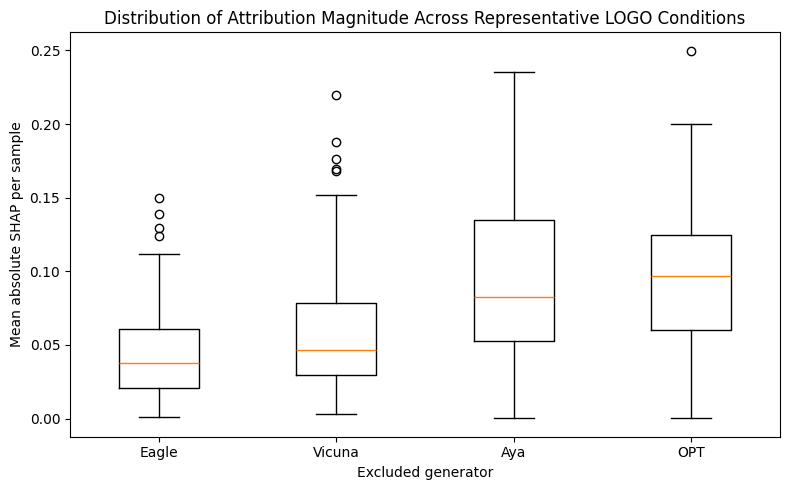

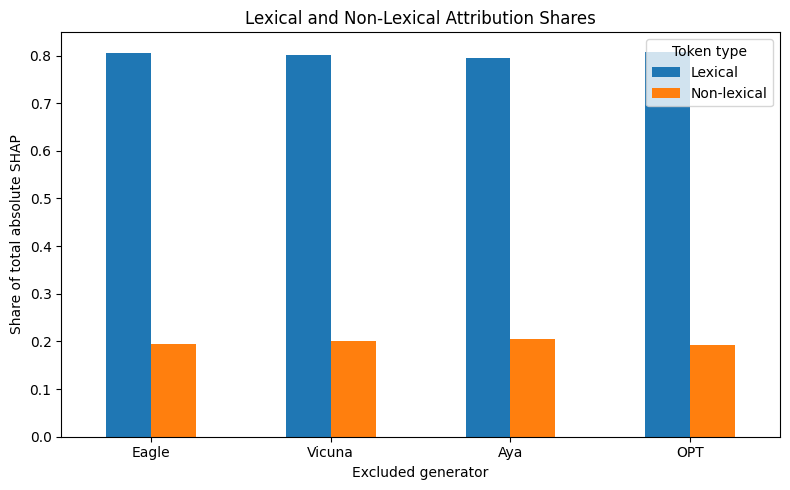

In [ ]:
# Compare attribution behaviour across representative
# generators

generator_attribution_frames = []

for excluded_generator in REPRESENTATIVE_LOGO_GENERATORS:

    shap_output_paths = generator_shap_output_paths(
        excluded_generator
    )

    token_attribution_df = pd.read_parquet(
        shap_output_paths["token_attributions"]
    )

    token_attribution_df["Token type"] = (
        token_attribution_df["Token"]
        .apply(classify_generator_token_type)
    )

    generator_attribution_frames.append(
        token_attribution_df
    )


combined_generator_attributions_df = pd.concat(
    generator_attribution_frames,
    ignore_index=True
)


# Validate the combined outputs

assert (
    combined_generator_attributions_df[
        "Excluded generator"
    ].nunique()
    ==
    len(REPRESENTATIVE_LOGO_GENERATORS)
)

assert (
    combined_generator_attributions_df[
        "SHAP sample position"
    ]
    .groupby(
        combined_generator_attributions_df[
            "Excluded generator"
        ]
    )
    .nunique()
    .eq(GENERATOR_SHAP_SAMPLE_SIZE)
    .all()
)


# Calculate sample-level attribution magnitude

sample_attribution_df = (
    combined_generator_attributions_df
    .groupby(
        [
            "Excluded generator",
            "Generalisation group",
            "SHAP sample position"
        ],
        as_index=False
    )
    .agg(
        Token_count=(
            "Token",
            "size"
        ),

        Mean_Absolute_SHAP=(
            "Absolute AI SHAP",
            "mean"
        ),

        Median_Absolute_SHAP=(
            "Absolute AI SHAP",
            "median"
        ),

        Maximum_Absolute_SHAP=(
            "Absolute AI SHAP",
            "max"
        ),

        Mean_Signed_SHAP=(
            "AI_SHAP",
            "mean"
        )
    )
)


# Summarise attribution magnitude by generator

generator_attribution_summary_df = (
    sample_attribution_df
    .groupby(
        [
            "Excluded generator",
            "Generalisation group"
        ],
        as_index=False
    )
    .agg(
        Samples=(
            "SHAP sample position",
            "size"
        ),

        Mean_tokens_per_sample=(
            "Token_count",
            "mean"
        ),

        Mean_sample_attribution=(
            "Mean_Absolute_SHAP",
            "mean"
        ),

        Median_sample_attribution=(
            "Mean_Absolute_SHAP",
            "median"
        ),

        Mean_maximum_attribution=(
            "Maximum_Absolute_SHAP",
            "mean"
        ),

        Mean_signed_attribution=(
            "Mean_Signed_SHAP",
            "mean"
        )
    )
)


# Calculate lexical and non-lexical attribution shares
#
# Absolute SHAP values are summed within each feature type and
# divided by the total absolute attribution for that generator.

feature_type_attribution_df = (
    combined_generator_attributions_df
    .groupby(
        [
            "Excluded generator",
            "Generalisation group",
            "Token type"
        ],
        as_index=False
    )
    .agg(
        Token_occurrences=(
            "Token",
            "size"
        ),

        Total_Absolute_SHAP=(
            "Absolute AI SHAP",
            "sum"
        ),

        Mean_Absolute_SHAP=(
            "Absolute AI SHAP",
            "mean"
        )
    )
)

feature_type_attribution_df[
    "Absolute attribution share"
] = (
    feature_type_attribution_df[
        "Total_Absolute_SHAP"
    ]
    /
    feature_type_attribution_df.groupby(
        "Excluded generator"
    )[
        "Total_Absolute_SHAP"
    ]
    .transform("sum")
)


# Display numerical summaries

display(
    generator_attribution_summary_df
    .style
    .format({
        "Mean_tokens_per_sample":
            "{:.2f}",

        "Mean_sample_attribution":
            "{:.4f}",

        "Median_sample_attribution":
            "{:.4f}",

        "Mean_maximum_attribution":
            "{:.4f}",

        "Mean_signed_attribution":
            "{:.4f}"
    })
)

display(
    feature_type_attribution_df[
        [
            "Excluded generator",
            "Generalisation group",
            "Token type",
            "Token_occurrences",
            "Mean_Absolute_SHAP",
            "Absolute attribution share"
        ]
    ]
    .rename(columns={
        "Token_occurrences":
            "Token occurrences"
    })
    .style
    .format({
        "Mean_Absolute_SHAP":
            "{:.4f}",

        "Absolute attribution share":
            "{:.2%}"
    })
)


# Plot sample-level attribution magnitude

generator_display_map = {
    "v5-Eagle-7B-HF": "Eagle",
    "vicuna-13b": "Vicuna",
    "aya-101": "Aya",
    "opt-iml-max-30b": "OPT"
}

plot_generator_order = [
    "v5-Eagle-7B-HF",
    "vicuna-13b",
    "aya-101",
    "opt-iml-max-30b"
]

sample_plot_data = [
    sample_attribution_df.loc[
        sample_attribution_df[
            "Excluded generator"
        ] == generator,
        "Mean_Absolute_SHAP"
    ].values
    for generator in plot_generator_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    sample_plot_data,
    tick_labels=[
        generator_display_map[generator]
        for generator in plot_generator_order
    ],
    showfliers=True
)

plt.xlabel("Excluded generator")

plt.ylabel(
    "Mean absolute SHAP per sample"
)

plt.title(
    "Distribution of Attribution Magnitude Across "
    "Representative LOGO Conditions"
)

plt.tight_layout()

plt.show()


# Plot lexical versus non-lexical attribution shares

feature_share_plot_df = (
    feature_type_attribution_df
    .pivot(
        index="Excluded generator",
        columns="Token type",
        values="Absolute attribution share"
    )
    .reindex(plot_generator_order)
    .fillna(0)
)

feature_share_plot_df.index = [
    generator_display_map[generator]
    for generator in feature_share_plot_df.index
]

feature_share_plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Excluded generator")

plt.ylabel(
    "Share of total absolute SHAP"
)

plt.title(
    "Lexical and Non-Lexical Attribution Shares"
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Token type"
)

plt.tight_layout()

plt.show()

In [ ]:
# Table: Attribution magnitude and feature-type composition
# across representative LOGO conditions

attribution_magnitude_table_df = (
    generator_attribution_summary_df[
        [
            "Excluded generator",
            "Generalisation group",
            "Samples",
            "Mean_tokens_per_sample",
            "Mean_sample_attribution",
            "Median_sample_attribution",
            "Mean_maximum_attribution",
            "Mean_signed_attribution"
        ]
    ]
    .copy()
)


# Add lexical and non-lexical attribution shares

feature_share_wide_df = (
    feature_type_attribution_df
    .pivot(
        index=[
            "Excluded generator",
            "Generalisation group"
        ],
        columns="Token type",
        values="Absolute attribution share"
    )
    .reset_index()
)


feature_share_wide_df.columns.name = None


feature_share_wide_df = (
    feature_share_wide_df
    .rename(columns={
        "Lexical":
            "Lexical attribution share",

        "Non-lexical":
            "Non-lexical attribution share"
    })
)


attribution_magnitude_table_df = (
    attribution_magnitude_table_df
    .merge(
        feature_share_wide_df,
        on=[
            "Excluded generator",
            "Generalisation group"
        ],
        how="left",
        validate="one_to_one"
    )
)


# Use a clear presentation order

attribution_magnitude_table_df[
    "Generator order"
] = (
    attribution_magnitude_table_df[
        "Excluded generator"
    ]
    .map({
        "v5-Eagle-7B-HF": 1,
        "vicuna-13b": 2,
        "aya-101": 3,
        "opt-iml-max-30b": 4
    })
)


attribution_magnitude_table_df = (
    attribution_magnitude_table_df
    .sort_values(
        "Generator order"
    )
    .drop(
        columns="Generator order"
    )
    .reset_index(drop=True)
)


print(
    "Table: Attribution Magnitude and Feature-Type "
    "Composition Across Representative LOGO Conditions"
)


display(
    attribution_magnitude_table_df
    .style
    .format({
        "Mean_tokens_per_sample":
            "{:.2f}",

        "Mean_sample_attribution":
            "{:.4f}",

        "Median_sample_attribution":
            "{:.4f}",

        "Mean_maximum_attribution":
            "{:.4f}",

        "Mean_signed_attribution":
            "{:.4f}",

        "Lexical attribution share":
            "{:.2%}",

        "Non-lexical attribution share":
            "{:.2%}"
    })
)


# Save the table

attribution_magnitude_table_path = (
    GENERATOR_SHAP_OUTPUT_ROOT
    / "representative_generator_attribution_summary.csv"
)


save_dataframe_atomic(
    dataframe=attribution_magnitude_table_df,
    output_path=attribution_magnitude_table_path
)


print(
    "Table saved:",
    attribution_magnitude_table_path
)

Table: Attribution Magnitude and Feature-Type Composition Across Representative LOGO Conditions


,Excluded generator,Generalisation group,Samples,Mean_tokens_per_sample,Mean_sample_attribution,Median_sample_attribution,Mean_maximum_attribution,Mean_signed_attribution,Lexical attribution share,Non-lexical attribution share
0,v5-Eagle-7B-HF,Strong generalisation,100,41.28,0.0453,0.0375,0.1817,0.0019,80.56%,19.44%
1,vicuna-13b,Strong generalisation,100,36.64,0.0604,0.0466,0.2187,0.0050,80.02%,19.98%
2,aya-101,Weak generalisation,100,26.93,0.0928,0.0823,0.3377,0.0392,79.43%,20.57%
3,opt-iml-max-30b,Weak generalisation,100,19.01,0.0946,0.0969,0.3223,0.0597,80.82%,19.18%


Table saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/representative_generator_attribution_summary.csv


The representative LOGO conditions exhibit clear differences in sample-level attribution magnitude. The two weak-generalisation conditions, Aya-101 and OPT-IML-Max-30B, produce substantially higher mean absolute SHAP values than the two strong-generalisation conditions. Mean sample-level attribution reaches 0.0928 for Aya-101 and 0.0946 for OPT-IML-Max-30B, compared with 0.0453 for v5-Eagle-7B-HF and 0.0604 for Vicuna-13B. Median sample-level attribution follows the same pattern, remaining higher for Aya-101 (0.0823) and OPT-IML-Max-30B (0.0969) than for v5-Eagle-7B-HF (0.0375) and Vicuna-13B (0.0466).

A similar difference is observed in the maximum token-level contribution within each sample. Aya-101 and OPT-IML-Max-30B exhibit mean maximum absolute SHAP values of 0.3377 and 0.3223, respectively, whereas the corresponding values are lower for v5-Eagle-7B-HF (0.1817) and Vicuna-13B (0.2187). These findings show that weak unseen-generator performance is not associated with an absence of influential token-level evidence. Instead, the weak-generalisation conditions produce larger average and maximum attribution magnitudes, even though the corresponding generators are detected less successfully.

The weak-generalisation samples are also shorter on average. Aya-101 and OPT-IML-Max-30B contain approximately 26.93 and 19.01 tokens per sample, compared with 41.28 for v5-Eagle-7B-HF and 36.64 for Vicuna-13B. Consequently, part of the higher mean per-token attribution observed under the weak-generalisation conditions may reflect the distribution of model evidence across fewer token occurrences. The attribution-magnitude differences should therefore be interpreted descriptively rather than as evidence that stronger token-level attributions directly cause weaker generalisation.

The relative contribution of lexical and non-lexical features remains highly stable across all four conditions. Lexical features account for 79.43% of total absolute attribution for Aya-101, 80.82% for OPT-IML-Max-30B, 80.56% for v5-Eagle-7B-HF and 80.02% for Vicuna-13B. Non-lexical features account for the remaining 19.18–20.57%. Although mean absolute SHAP is consistently higher for both lexical and non-lexical features under the weak-generalisation conditions, there is no substantial shift in their relative attribution shares.

Overall, the main contrast between the strong- and weak-generalisation conditions lies in the magnitude of token-level attribution rather than in the broad lexical versus non-lexical composition of the evidence. However, absolute SHAP values do not show whether influential features support the AI-generated prediction or shift the model towards the Human-written class. The following directional SHAP analysis therefore examines the signed contributions of recurrent tokens under each representative unseen-generator condition.


### 20.6.5 Directional Feature Contributions Across Generators

The preceding analysis compared the overall magnitude of token-level attributions across representative strong- and weak-generalisation conditions. The present analysis examines attribution direction in order to identify which recurrent textual features shift predictions towards the AI-generated or Human-written class.

For each representative LOGO condition, signed SHAP values are aggregated across all occurrences of the same token. Positive mean signed SHAP values indicate that a token contributes towards the AI-generated class, whereas negative values indicate a contribution towards the Human-written class.

To reduce the influence of isolated multilingual subword fragments, only tokens occurring at least five times within the corresponding generator-specific SHAP subset are retained. The strongest recurrent AI-oriented and Human-oriented token contributions are then visualised separately for each representative generator.

Because the analysis is multilingual and uses subword tokenisation, individual lexical tokens are interpreted cautiously. The primary objective is to compare broader attribution patterns, including the relative role of lexical and stylistic features, rather than to identify universal linguistic markers of AI-generated text.


DIRECTIONAL SHAP ANALYSIS: v5-Eagle-7B-HF


,Token,Token type,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP,Contribution direction
0,?,Non-lexical,27,-0.1383,0.1383,Towards Human
1,ed,Lexical,5,-0.0772,0.0772,Towards Human
2,!,Non-lexical,37,-0.0699,0.0722,Towards Human
3,.,Non-lexical,88,-0.0675,0.0748,Towards Human
4,d,Lexical,6,-0.0478,0.0560,Towards Human
5,w,Lexical,5,-0.0401,0.0401,Towards Human
6,da,Lexical,8,-0.0326,0.0403,Towards Human
7,na,Lexical,9,-0.0324,0.0356,Towards Human
8,в,Lexical,6,-0.0307,0.0307,Towards Human
9,e,Lexical,24,-0.0305,0.0352,Towards Human


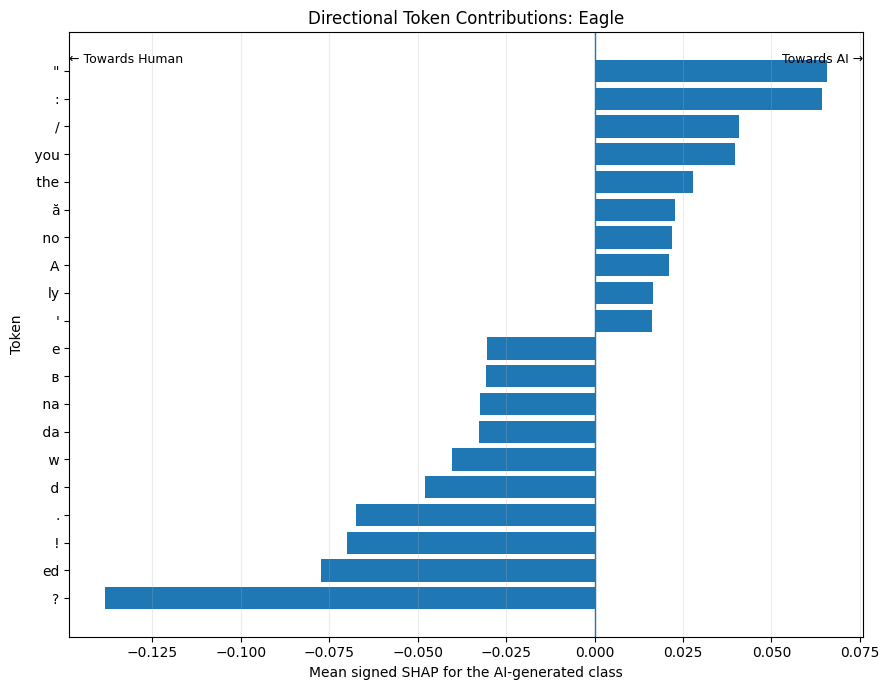

Directional summary saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/v5-eagle-7b-hf/directional_token_summary.csv
Directional figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/v5-eagle-7b-hf/directional_token_contributions.png
Directional figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/v5-eagle-7b-hf/directional_token_contributions.pdf

DIRECTIONAL SHAP ANALYSIS: vicuna-13b


,Token,Token type,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP,Contribution direction
0,?,Non-lexical,19,-0.1488,0.1488,Towards Human
1,.,Non-lexical,99,-0.0930,0.0965,Towards Human
2,!,Non-lexical,18,-0.0787,0.1005,Towards Human
3,я,Lexical,7,-0.0743,0.0743,Towards Human
4,c,Lexical,5,-0.0611,0.0611,Towards Human
5,E,Lexical,5,-0.0567,0.0567,Towards Human
6,y,Lexical,5,-0.0542,0.0542,Towards Human
7,，,Non-lexical,6,-0.0412,0.0454,Towards Human
8,v,Lexical,11,-0.0412,0.0473,Towards Human
9,ha,Lexical,5,-0.0396,0.0397,Towards Human


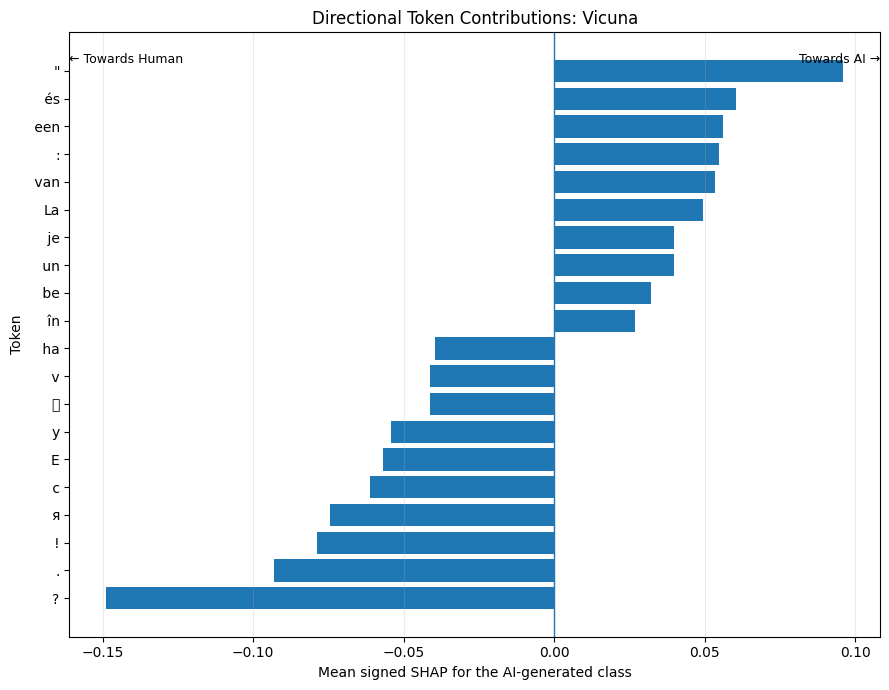

Directional summary saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/vicuna-13b/directional_token_summary.csv
Directional figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/vicuna-13b/directional_token_contributions.png
Directional figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/vicuna-13b/directional_token_contributions.pdf

DIRECTIONAL SHAP ANALYSIS: aya-101


,Token,Token type,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP,Contribution direction
0,USER,Lexical,6,-0.1090,0.1263,Towards Human
1,?,Non-lexical,13,-0.1044,0.1264,Towards Human
2,e,Lexical,6,-0.0904,0.0917,Towards Human
3,не,Lexical,11,-0.0604,0.0604,Towards Human
4,u,Lexical,6,-0.0537,0.1197,Towards Human
5,!,Non-lexical,22,-0.0523,0.0845,Towards Human
6,A,Lexical,5,-0.0518,0.0519,Towards Human
7,no,Lexical,8,-0.0510,0.0545,Towards Human
8,y,Lexical,5,-0.0359,0.0364,Towards Human
9,.,Non-lexical,95,-0.0335,0.0998,Towards Human


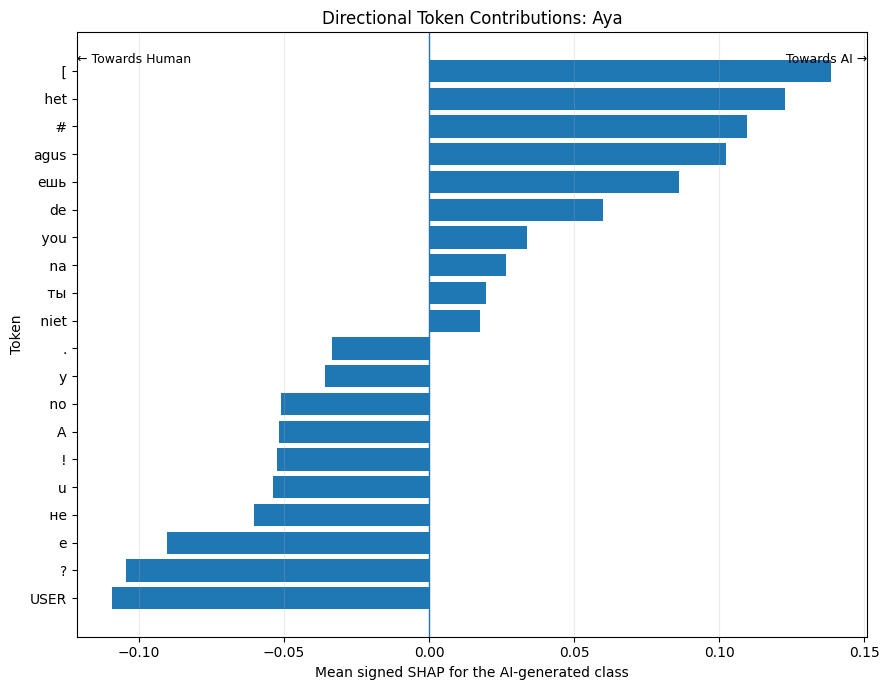

Directional summary saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/aya-101/directional_token_summary.csv
Directional figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/aya-101/directional_token_contributions.png
Directional figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/aya-101/directional_token_contributions.pdf

DIRECTIONAL SHAP ANALYSIS: opt-iml-max-30b


,Token,Token type,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP,Contribution direction
0,],Non-lexical,8,-0.1631,0.1631,Towards Human
1,USER,Lexical,10,-0.0754,0.1003,Towards Human
2,e,Lexical,10,-0.0332,0.0462,Towards Human
3,m,Lexical,5,-0.0300,0.0543,Towards Human
4,l,Lexical,6,-0.0137,0.0137,Towards Human
5,s,Lexical,21,-0.0110,0.0358,Towards Human
6,/,Non-lexical,6,-0.0104,0.0162,Towards Human
7,und,Lexical,6,-0.0051,0.0399,Towards Human
8,t,Lexical,12,-0.0046,0.0494,Towards Human
9,n,Lexical,5,-0.0036,0.0581,Towards Human


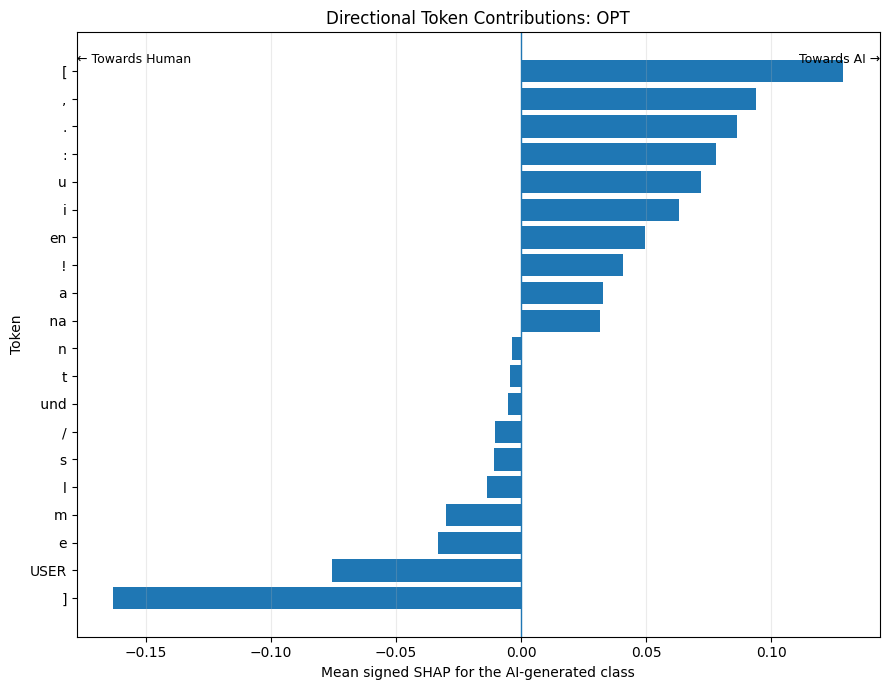

Directional summary saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/opt-iml-max-30b/directional_token_summary.csv
Directional figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/opt-iml-max-30b/directional_token_contributions.png
Directional figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/opt-iml-max-30b/directional_token_contributions.pdf

Directional SHAP analysis completed for all representative generators.
Combined directional summary saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/combined_directional_feature_summary.csv


In [ ]:
# Directional feature contributions across generators

MIN_DIRECTIONAL_TOKEN_OCCURRENCES = 5
TOP_DIRECTIONAL_FEATURES_PER_SIDE = 10

directional_generator_summaries = {}
directional_plot_frames = []


def make_directional_token_display(token):
    """
    Convert whitespace-only tokens into a readable label.
    """

    token = str(token)

    if token.isspace():
        return "<whitespace>"

    return token

generator_directional_summaries = {}

for excluded_generator in REPRESENTATIVE_LOGO_GENERATORS:

    print("\n" + "=" * 80)
    print(
        "DIRECTIONAL SHAP ANALYSIS:",
        excluded_generator
    )
    print("=" * 80)


    # Aggregate signed SHAP values by token

    generator_directional_df = (
        combined_generator_attributions_df[
            combined_generator_attributions_df[
                "Excluded generator"
            ] == excluded_generator
        ]
        .groupby(
            "Token",
            as_index=False
        )
        .agg(
            Occurrences=(
                "AI_SHAP",
                "size"
            ),

            Mean_Signed_SHAP=(
                "AI_SHAP",
                "mean"
            ),

            Mean_Absolute_SHAP=(
                "Absolute AI SHAP",
                "mean"
            ),

            Maximum_Absolute_SHAP=(
                "Absolute AI SHAP",
                "max"
            )
        )
    )


    # Retain recurrent tokens only

    generator_directional_df = (
        generator_directional_df[
            generator_directional_df[
                "Occurrences"
            ] >= MIN_DIRECTIONAL_TOKEN_OCCURRENCES
        ]
        .copy()
        .reset_index(drop=True)
    )

    if generator_directional_df.empty:
        raise ValueError(
            "No recurrent directional tokens remained for "
            f"'{excluded_generator}' after occurrence filtering."
        )


    # Add token type and direction

    generator_directional_df[
        "Token type"
    ] = (
        generator_directional_df[
            "Token"
        ]
        .apply(
            classify_generator_token_type
        )
    )

    generator_directional_df[
        "Contribution direction"
    ] = np.where(
        generator_directional_df[
            "Mean_Signed_SHAP"
        ] >= 0,
        "Towards AI",
        "Towards Human"
    )

    generator_directional_df[
        "Display token"
    ] = (
        generator_directional_df[
            "Token"
        ]
        .apply(
            make_directional_token_display
        )
    )

    generator_directional_summaries[
        excluded_generator
    ] = generator_directional_df


    # Select strongest AI-oriented contributions

    strongest_ai_df = (
        generator_directional_df[
            generator_directional_df[
                "Mean_Signed_SHAP"
            ] > 0
        ]
        .sort_values(
            "Mean_Signed_SHAP",
            ascending=False
        )
        .head(
            TOP_DIRECTIONAL_FEATURES_PER_SIDE
        )
        .copy()
    )


    # Select strongest Human-oriented contributions

    strongest_human_df = (
        generator_directional_df[
            generator_directional_df[
                "Mean_Signed_SHAP"
            ] < 0
        ]
        .sort_values(
            "Mean_Signed_SHAP",
            ascending=True
        )
        .head(
            TOP_DIRECTIONAL_FEATURES_PER_SIDE
        )
        .copy()
    )


    # Combine both directions for display and plotting

    directional_plot_df = (
        pd.concat(
            [
                strongest_human_df,
                strongest_ai_df
            ],
            ignore_index=True
        )
        .drop_duplicates(
            subset="Token"
        )
        .sort_values(
            "Mean_Signed_SHAP",
            ascending=True
        )
        .reset_index(drop=True)
    )

    directional_plot_df[
        "Excluded generator"
    ] = excluded_generator

    directional_plot_df[
        "Generalisation group"
    ] = GENERALISATION_GROUP_MAP[
        excluded_generator
    ]

    directional_plot_frames.append(
        directional_plot_df
    )


    # Display the directional feature table

    display(
        directional_plot_df[
            [
                "Token",
                "Token type",
                "Occurrences",
                "Mean_Signed_SHAP",
                "Mean_Absolute_SHAP",
                "Contribution direction"
            ]
        ]
        .style
        .format({
            "Mean_Signed_SHAP":
                "{:.4f}",

            "Mean_Absolute_SHAP":
                "{:.4f}"
        })
    )


    # Plot Human-oriented and AI-oriented contributions

    fig, ax = plt.subplots(
        figsize=(9, 7)
    )

    ax.barh(
        directional_plot_df[
            "Display token"
        ],
        directional_plot_df[
            "Mean_Signed_SHAP"
        ]
    )

    ax.axvline(
        0,
        linewidth=1
    )

    ax.set_xlabel(
        "Mean signed SHAP for the AI-generated class"
    )

    ax.set_ylabel(
        "Token"
    )

    ax.set_title(
        "Directional Token Contributions: "
        + generator_display_map[
            excluded_generator
        ]
    )

    x_min, x_max = ax.get_xlim()

    annotation_y = (
        len(directional_plot_df)
        - 0.6
    )

    ax.text(
        x_min,
        annotation_y,
        "← Towards Human",
        ha="left",
        va="center",
        fontsize=9
    )

    ax.text(
        x_max,
        annotation_y,
        "Towards AI →",
        ha="right",
        va="center",
        fontsize=9
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    fig.tight_layout()


    # Save the directional table and figure

    directional_output_paths = (
        generator_shap_output_paths(
            excluded_generator
        )
    )

    directional_summary_path = (
        directional_output_paths[
            "root"
        ]
        / "directional_token_summary.csv"
    )

    directional_figure_png = (
        directional_output_paths[
            "root"
        ]
        / "directional_token_contributions.png"
    )

    directional_figure_pdf = (
        directional_output_paths[
            "root"
        ]
        / "directional_token_contributions.pdf"
    )

    save_dataframe_atomic(
        dataframe=generator_directional_df,
        output_path=directional_summary_path
    )

    fig.savefig(
        directional_figure_png,
        dpi=300,
        bbox_inches="tight"
    )

    fig.savefig(
        directional_figure_pdf,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(
        "Directional summary saved:",
        directional_summary_path
    )

    print(
        "Directional figure saved:",
        directional_figure_png
    )

    print(
        "Directional figure saved:",
        directional_figure_pdf
    )


# Combine selected directional features across generators

combined_directional_features_df = (
    pd.concat(
        directional_plot_frames,
        ignore_index=True
    )
)

combined_directional_summary_path = (
    GENERATOR_SHAP_OUTPUT_ROOT
    / "combined_directional_feature_summary.csv"
)

save_dataframe_atomic(
    dataframe=combined_directional_features_df,
    output_path=combined_directional_summary_path
)

print(
    "\nDirectional SHAP analysis completed for all "
    "representative generators."
)

print(
    "Combined directional summary saved:",
    combined_directional_summary_path
)

In [ ]:
# Display the combined directional SHAP summary

combined_directional_summary_path = (
    GENERATOR_SHAP_OUTPUT_ROOT
    / "combined_directional_feature_summary.csv"
)

if not combined_directional_summary_path.exists():
    raise FileNotFoundError(
        "The combined directional SHAP summary could not be found at: "
        f"{combined_directional_summary_path}"
    )

combined_directional_feature_summary_df = pd.read_csv(
    combined_directional_summary_path
)

print(
    "Combined directional SHAP summary:"
)

display(
    combined_directional_feature_summary_df
    .style
    .format({
        "Mean_Signed_SHAP":
            "{:.4f}",

        "Mean_Absolute_SHAP":
            "{:.4f}"
    })
)

Combined directional SHAP summary:


,Token,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP,Maximum_Absolute_SHAP,Token type,Contribution direction,Display token,Excluded generator,Generalisation group
0,?,27,-0.1383,0.1383,0.421814,Non-lexical,Towards Human,?,v5-Eagle-7B-HF,Strong generalisation
1,ed,5,-0.0772,0.0772,0.228514,Lexical,Towards Human,ed,v5-Eagle-7B-HF,Strong generalisation
2,!,37,-0.0699,0.0722,0.248309,Non-lexical,Towards Human,!,v5-Eagle-7B-HF,Strong generalisation
3,.,88,-0.0675,0.0748,0.496792,Non-lexical,Towards Human,.,v5-Eagle-7B-HF,Strong generalisation
4,d,6,-0.0478,0.0560,0.209195,Lexical,Towards Human,d,v5-Eagle-7B-HF,Strong generalisation
5,w,5,-0.0401,0.0401,0.093762,Lexical,Towards Human,w,v5-Eagle-7B-HF,Strong generalisation
6,da,8,-0.0326,0.0403,0.114479,Lexical,Towards Human,da,v5-Eagle-7B-HF,Strong generalisation
7,na,9,-0.0324,0.0356,0.091665,Lexical,Towards Human,na,v5-Eagle-7B-HF,Strong generalisation
8,в,6,-0.0307,0.0307,0.088928,Lexical,Towards Human,в,v5-Eagle-7B-HF,Strong generalisation
9,e,24,-0.0305,0.0352,0.358118,Lexical,Towards Human,e,v5-Eagle-7B-HF,Strong generalisation


In [ ]:
# Display the strongest Human- and AI-oriented features
# for each representative generator

TOP_DIRECTIONAL_FEATURES = 10

for excluded_generator in REPRESENTATIVE_LOGO_GENERATORS:

    generator_directional_df = (
        combined_directional_feature_summary_df[
            combined_directional_feature_summary_df[
                "Excluded generator"
            ] == excluded_generator
        ]
        .copy()
    )

    strongest_human_df = (
        generator_directional_df
        .sort_values(
            "Mean_Signed_SHAP",
            ascending=True
        )
        .head(TOP_DIRECTIONAL_FEATURES)
        .copy()
    )

    strongest_ai_df = (
        generator_directional_df
        .sort_values(
            "Mean_Signed_SHAP",
            ascending=False
        )
        .head(TOP_DIRECTIONAL_FEATURES)
        .copy()
    )

    print("\n" + "=" * 80)
    print(
        "DIRECTIONAL SHAP SUMMARY:",
        excluded_generator
    )
    print("=" * 80)

    print("\nStrongest contributions towards Human:")

    display(
        strongest_human_df[
            [
                "Token",
                "Token type",
                "Occurrences",
                "Mean_Signed_SHAP",
                "Mean_Absolute_SHAP"
            ]
        ]
        .style
        .format({
            "Mean_Signed_SHAP":
                "{:.4f}",

            "Mean_Absolute_SHAP":
                "{:.4f}"
        })
    )

    print("\nStrongest contributions towards AI:")

    display(
        strongest_ai_df[
            [
                "Token",
                "Token type",
                "Occurrences",
                "Mean_Signed_SHAP",
                "Mean_Absolute_SHAP"
            ]
        ]
        .style
        .format({
            "Mean_Signed_SHAP":
                "{:.4f}",

            "Mean_Absolute_SHAP":
                "{:.4f}"
        })
    )


DIRECTIONAL SHAP SUMMARY: v5-Eagle-7B-HF

Strongest contributions towards Human:


,Token,Token type,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
0,?,Non-lexical,27,-0.1383,0.1383
1,ed,Lexical,5,-0.0772,0.0772
2,!,Non-lexical,37,-0.0699,0.0722
3,.,Non-lexical,88,-0.0675,0.0748
4,d,Lexical,6,-0.0478,0.0560
5,w,Lexical,5,-0.0401,0.0401
6,da,Lexical,8,-0.0326,0.0403
7,na,Lexical,9,-0.0324,0.0356
8,в,Lexical,6,-0.0307,0.0307
9,e,Lexical,24,-0.0305,0.0352



Strongest contributions towards AI:


,Token,Token type,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
19,"""",Non-lexical,9,0.0657,0.0657
18,:,Non-lexical,8,0.0643,0.0643
17,/,Non-lexical,9,0.0407,0.0407
16,you,Lexical,6,0.0398,0.0592
15,the,Lexical,9,0.0277,0.0470
14,ă,Lexical,5,0.0226,0.0426
13,no,Lexical,8,0.0220,0.0263
12,A,Lexical,6,0.0209,0.0438
11,ly,Lexical,7,0.0164,0.0319
10,',Non-lexical,8,0.0161,0.0250



DIRECTIONAL SHAP SUMMARY: vicuna-13b

Strongest contributions towards Human:


...

,Token,Token type,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
59,[,Non-lexical,6,0.1387,0.1400
58,het,Lexical,7,0.1227,0.1227
57,#,Non-lexical,11,0.1097,0.1202
56,agus,Lexical,5,0.1025,0.1025
55,ешь,Lexical,5,0.0863,0.0901
54,de,Lexical,6,0.0600,0.0721
53,you,Lexical,5,0.0338,0.0376
52,na,Lexical,6,0.0264,0.0785
51,ты,Lexical,6,0.0198,0.0296
50,niet,Lexical,5,0.0174,0.0476



DIRECTIONAL SHAP SUMMARY: opt-iml-max-30b

Strongest contributions towards Human:


,Token,Token type,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
60,],Non-lexical,8,-0.1631,0.1631
61,USER,Lexical,10,-0.0754,0.1003
62,e,Lexical,10,-0.0332,0.0462
63,m,Lexical,5,-0.0300,0.0543
64,l,Lexical,6,-0.0137,0.0137
65,s,Lexical,21,-0.0110,0.0358
66,/,Non-lexical,6,-0.0104,0.0162
67,und,Lexical,6,-0.0051,0.0399
68,t,Lexical,12,-0.0046,0.0494
69,n,Lexical,5,-0.0036,0.0581



Strongest contributions towards AI:


,Token,Token type,Occurrences,Mean_Signed_SHAP,Mean_Absolute_SHAP
79,[,Non-lexical,10,0.1288,0.1323
78,",",Non-lexical,41,0.0939,0.1123
77,.,Non-lexical,62,0.0864,0.1468
76,:,Non-lexical,9,0.0779,0.0786
75,u,Lexical,6,0.0719,0.1006
74,i,Lexical,18,0.0629,0.0821
73,en,Lexical,7,0.0494,0.1328
72,!,Non-lexical,5,0.0406,0.0584
71,a,Lexical,28,0.0327,0.0648
70,na,Lexical,6,0.0317,0.0367


The directional SHAP analysis reveals both shared and generator-specific attribution patterns across the representative LOGO conditions. In the two strong-generalisation conditions, recurrent punctuation features predominantly shift predictions towards the Human-written class. For v5-Eagle-7B-HF, question marks, exclamation marks and full stops produce mean signed SHAP values of −0.1383, −0.0699 and −0.0675, respectively. A similar pattern is observed for Vicuna-13B, where question marks (−0.1488), full stops (−0.0930) and exclamation marks (−0.0787) are among the strongest recurrent Human-oriented features.

The weak-generalisation conditions exhibit more varied directional patterns. For OPT-IML-Max-30B, several recurrent punctuation and structural features shift predictions towards the AI-generated class, including opening brackets (0.1288), commas (0.0939), full stops (0.0864) and colons (0.0779). However, closing brackets (−0.1631) and the social-media marker “USER” (−0.0754) shift predictions towards the Human-written class. Aya-101 similarly displays a mixed profile: opening brackets (0.1387) and hashtags (0.1097) support the AI-generated prediction, whereas “USER” (−0.1090), question marks (−0.1044), exclamation marks (−0.0523) and full stops (−0.0335) contribute towards the Human-written class.

Several recurrent features therefore change attribution direction across LOGO conditions. Most notably, full stops contribute towards the Human-written class in the v5-Eagle-7B-HF, Vicuna-13B and Aya-101 conditions but towards the AI-generated class in the OPT-IML-Max-30B condition. This indicates that punctuation and formatting features are not interpreted as fixed indicators of one class. Instead, their contribution depends on the feature relationships learned by each independently fine-tuned classifier from the generators retained during development.

Taken together with the preceding magnitude analysis, these results suggest that generator-specific generalisation differences are associated not only with the strength of token-level attributions but also with differences in attribution direction. The weak-generalisation conditions do not simply lack influential AI-oriented evidence; rather, they exhibit competing contributions in which some recurrent features support the AI-generated class while others shift the prediction towards the Human-written class. Such conflicting directional evidence may contribute to the lower AI-class confidence and higher misclassification rates observed for the difficult unseen generators.

Because the analysis is multilingual and uses subword tokenisation, individual lexical fragments are not interpreted as universal indicators of Human-written or AI-generated text. The most defensible cross-generator comparisons concern recurrent punctuation, structural symbols and social-media-specific markers. Even these patterns remain descriptive and should not be interpreted as causal explanations of generator-specific generalisation.


### 20.6.6 Compare Directional Attribution Shifts Between Generalisation Groups

To identify systematic differences between strong- and weak-generalisation conditions, signed SHAP values are aggregated at the generalisation-group level.

The analysis compares only tokens that occur repeatedly in both the strong-generalisation group (v5-Eagle-7B-HF and Vicuna-13B) and the weak-generalisation group (Aya-101 and OPT-IML-Max-30B). Restricting the comparison to recurrent shared features reduces the influence of isolated multilingual subword fragments and ensures that attribution differences refer to the same token representations in both groups.

For each shared token, the difference between the mean signed SHAP value in the weak-generalisation group and the corresponding value in the strong-generalisation group is calculated. Positive differences indicate that the token becomes more AI-oriented under weak generalisation, whereas negative differences indicate a shift towards the Human-written class.





Recurrent shared tokens available for comparison: 31

Largest shifts towards AI under weak generalisation:


,Token,Token type,Strong occurrences,Weak occurrences,Strong mean signed SHAP,Weak mean signed SHAP,Signed SHAP shift (Weak - Strong),Directional change
0,.,Non-lexical,187,157,-0.0810,0.0138,+0.0949,Human to AI
1,#,Non-lexical,13,11,0.0364,0.1097,+0.0733,More AI-oriented
2,?,Non-lexical,46,17,-0.1426,-0.0889,+0.0537,Less Human-oriented
3,",",Non-lexical,212,121,-0.0245,0.0264,+0.0510,Human to AI
4,na,Lexical,12,12,-0.0181,0.0291,+0.0472,Human to AI
5,u,Lexical,29,12,-0.0350,0.0091,+0.0441,Human to AI
6,en,Lexical,22,15,-0.0125,0.0258,+0.0383,Human to AI
7,!,Non-lexical,55,27,-0.0728,-0.0351,+0.0377,Less Human-oriented
8,y,Lexical,13,20,-0.0346,0.0010,+0.0356,Human to AI
9,i,Lexical,45,26,0.0048,0.0351,+0.0303,More AI-oriented



Largest shifts towards Human under weak generalisation:


,Token,Token type,Strong occurrences,Weak occurrences,Strong mean signed SHAP,Weak mean signed SHAP,Signed SHAP shift (Weak - Strong),Directional change
30,/,Non-lexical,16,13,0.0316,-0.0141,-0.0458,AI to Human
29,не,Lexical,11,13,-0.0142,-0.0575,-0.0433,More Human-oriented
28,no,Lexical,11,12,0.0095,-0.0273,-0.0367,AI to Human
27,e,Lexical,45,16,-0.0199,-0.0546,-0.0348,More Human-oriented
26,is,Lexical,21,13,0.0115,-0.0050,-0.0165,AI to Human
25,t,Lexical,27,27,0.0057,-0.0092,-0.0149,AI to Human
24,l,Lexical,15,11,-0.0076,-0.0185,-0.0110,More Human-oriented
23,',Non-lexical,22,12,0.0161,0.0065,-0.0096,Less AI-oriented
22,-,Non-lexical,48,69,0.0132,0.0108,-0.0024,Less AI-oriented
21,на,Lexical,12,10,0.0139,0.0127,-0.0012,Less AI-oriented


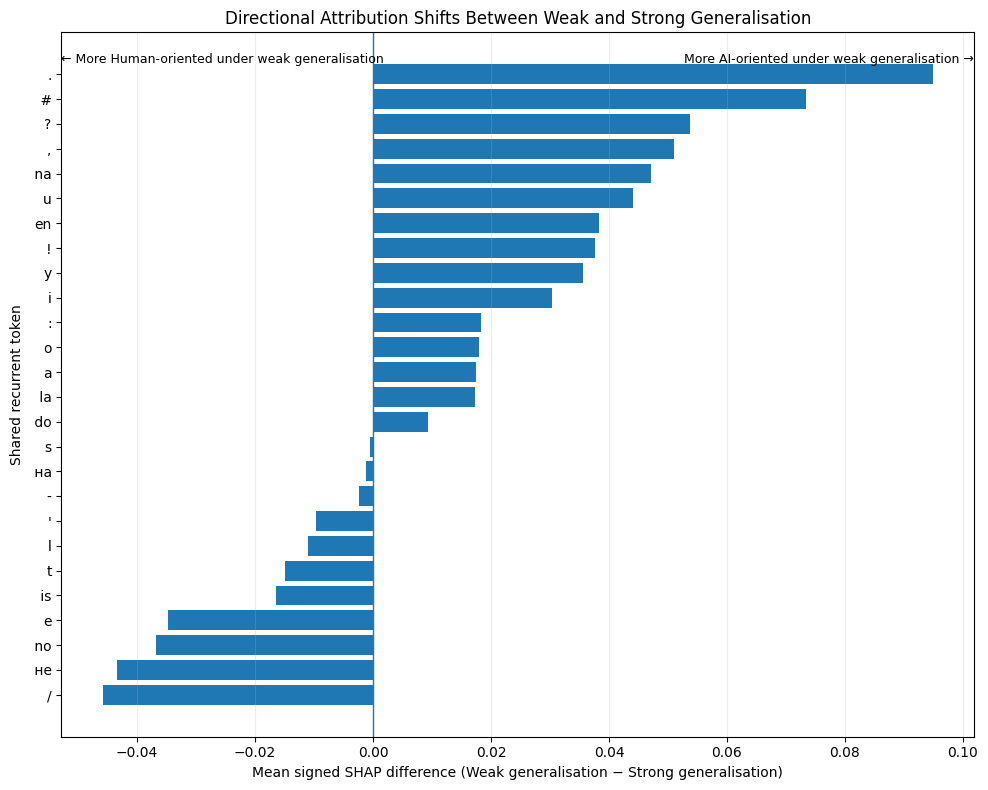


Group-level directional SHAP comparison completed.
Comparison table saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Group_Comparison/shared_token_directional_comparison.csv
Positive-shift table saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Group_Comparison/largest_positive_directional_shifts.csv
Negative-shift table saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Group_Comparison/largest_negative_directional_shifts.csv
Figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Group_Comparison/directional_shifts_weak_vs_strong.png
Figure saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Group_Comparison/directional_shifts_weak_vs_strong.pdf


In [ ]:
# Compare Directional Attribution Shifts
# Between Generalisation Groups

from pathlib import Path

# Configuration

MIN_GROUP_TOKEN_OCCURRENCES = 10
TOP_GROUP_SHAP_SHIFTS = 15


# 1. Prepare token-level attribution records

group_comparison_source_df = (
    combined_generator_attributions_df
    .copy()
)

# Remove empty and whitespace-only technical token entries

group_comparison_source_df = (
    group_comparison_source_df[
        group_comparison_source_df[
            "Token"
        ]
        .astype(str)
        .str.strip()
        .ne("")
    ]
    .copy()
    .reset_index(drop=True)
)


# Validate the expected generalisation groups

expected_generalisation_groups = {
    "Strong generalisation",
    "Weak generalisation"
}

observed_generalisation_groups = set(
    group_comparison_source_df[
        "Generalisation group"
    ]
    .dropna()
    .unique()
)

if observed_generalisation_groups != (
    expected_generalisation_groups
):
    raise ValueError(
        "Unexpected generalisation groups detected. "
        f"Expected {expected_generalisation_groups}, "
        f"but found {observed_generalisation_groups}."
    )


# 2. Aggregate signed SHAP values by group and token

group_directional_summary_all_df = (
    group_comparison_source_df
    .groupby(
        [
            "Generalisation group",
            "Token"
        ],
        as_index=False
    )
    .agg(
        Occurrences=(
            "AI_SHAP",
            "size"
        ),

        Mean_Signed_SHAP=(
            "AI_SHAP",
            "mean"
        ),

        Mean_Absolute_SHAP=(
            "Absolute AI SHAP",
            "mean"
        ),

        Maximum_Absolute_SHAP=(
            "Absolute AI SHAP",
            "max"
        )
    )
)


# 3. Retain recurrent tokens within each group

group_directional_summary_df = (
    group_directional_summary_all_df[
        group_directional_summary_all_df[
            "Occurrences"
        ] >= MIN_GROUP_TOKEN_OCCURRENCES
    ]
    .copy()
    .reset_index(drop=True)
)


if group_directional_summary_df.empty:
    raise ValueError(
        "No group-level tokens remained after applying "
        f"the minimum occurrence threshold of "
        f"{MIN_GROUP_TOKEN_OCCURRENCES}."
    )


# 4. Create separate strong- and weak-group summaries

strong_group_tokens_df = (
    group_directional_summary_df[
        group_directional_summary_df[
            "Generalisation group"
        ] == "Strong generalisation"
    ][
        [
            "Token",
            "Occurrences",
            "Mean_Signed_SHAP",
            "Mean_Absolute_SHAP",
            "Maximum_Absolute_SHAP"
        ]
    ]
    .rename(columns={
        "Occurrences":
            "Strong occurrences",

        "Mean_Signed_SHAP":
            "Strong mean signed SHAP",

        "Mean_Absolute_SHAP":
            "Strong mean absolute SHAP",

        "Maximum_Absolute_SHAP":
            "Strong maximum absolute SHAP"
    })
    .copy()
)


weak_group_tokens_df = (
    group_directional_summary_df[
        group_directional_summary_df[
            "Generalisation group"
        ] == "Weak generalisation"
    ][
        [
            "Token",
            "Occurrences",
            "Mean_Signed_SHAP",
            "Mean_Absolute_SHAP",
            "Maximum_Absolute_SHAP"
        ]
    ]
    .rename(columns={
        "Occurrences":
            "Weak occurrences",

        "Mean_Signed_SHAP":
            "Weak mean signed SHAP",

        "Mean_Absolute_SHAP":
            "Weak mean absolute SHAP",

        "Maximum_Absolute_SHAP":
            "Weak maximum absolute SHAP"
    })
    .copy()
)


# 5. Compare only recurrent tokens shared by both groups

shared_group_token_comparison_df = (
    strong_group_tokens_df
    .merge(
        weak_group_tokens_df,
        on="Token",
        how="inner",
        validate="one_to_one"
    )
)


if shared_group_token_comparison_df.empty:
    raise ValueError(
        "No recurrent token representations were shared by "
        "the strong- and weak-generalisation groups."
    )


# 6. Calculate directional and magnitude shifts

shared_group_token_comparison_df[
    "Signed SHAP shift (Weak - Strong)"
] = (
    shared_group_token_comparison_df[
        "Weak mean signed SHAP"
    ]
    -
    shared_group_token_comparison_df[
        "Strong mean signed SHAP"
    ]
)


shared_group_token_comparison_df[
    "Absolute importance shift (Weak - Strong)"
] = (
    shared_group_token_comparison_df[
        "Weak mean absolute SHAP"
    ]
    -
    shared_group_token_comparison_df[
        "Strong mean absolute SHAP"
    ]
)


shared_group_token_comparison_df[
    "Token type"
] = (
    shared_group_token_comparison_df[
        "Token"
    ]
    .apply(
        classify_generator_token_type
    )
)


# Describe whether the token changes direction

def classify_group_directional_change(row):

    strong_value = row[
        "Strong mean signed SHAP"
    ]

    weak_value = row[
        "Weak mean signed SHAP"
    ]

    if strong_value < 0 and weak_value > 0:
        return "Human to AI"

    if strong_value > 0 and weak_value < 0:
        return "AI to Human"

    if strong_value < 0 and weak_value < 0:
        if weak_value > strong_value:
            return "Less Human-oriented"
        return "More Human-oriented"

    if strong_value > 0 and weak_value > 0:
        if weak_value > strong_value:
            return "More AI-oriented"
        return "Less AI-oriented"

    return "At or near zero"


shared_group_token_comparison_df[
    "Directional change"
] = (
    shared_group_token_comparison_df
    .apply(
        classify_group_directional_change,
        axis=1
    )
)


shared_group_token_comparison_df = (
    shared_group_token_comparison_df
    .sort_values(
        "Signed SHAP shift (Weak - Strong)",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Recurrent shared tokens available for comparison:",
    len(shared_group_token_comparison_df)
)


# 7. Select the largest positive and negative shifts correctly

largest_positive_group_shifts_df = (
    shared_group_token_comparison_df[
        shared_group_token_comparison_df[
            "Signed SHAP shift (Weak - Strong)"
        ] > 0
    ]
    .sort_values(
        "Signed SHAP shift (Weak - Strong)",
        ascending=False
    )
    .head(
        TOP_GROUP_SHAP_SHIFTS
    )
    .copy()
)


largest_negative_group_shifts_df = (
    shared_group_token_comparison_df[
        shared_group_token_comparison_df[
            "Signed SHAP shift (Weak - Strong)"
        ] < 0
    ]
    .sort_values(
        "Signed SHAP shift (Weak - Strong)",
        ascending=True
    )
    .head(
        TOP_GROUP_SHAP_SHIFTS
    )
    .copy()
)


if largest_positive_group_shifts_df.empty:
    print(
        "No positive directional shifts were identified."
    )

if largest_negative_group_shifts_df.empty:
    print(
        "No negative directional shifts were identified."
    )


# 8. Display numerical summaries

print(
    "\nLargest shifts towards AI under weak generalisation:"
)

display(
    largest_positive_group_shifts_df[
        [
            "Token",
            "Token type",
            "Strong occurrences",
            "Weak occurrences",
            "Strong mean signed SHAP",
            "Weak mean signed SHAP",
            "Signed SHAP shift (Weak - Strong)",
            "Directional change"
        ]
    ]
    .style
    .format({
        "Strong mean signed SHAP":
            "{:.4f}",

        "Weak mean signed SHAP":
            "{:.4f}",

        "Signed SHAP shift (Weak - Strong)":
            "{:+.4f}"
    })
)


print(
    "\nLargest shifts towards Human under weak generalisation:"
)

display(
    largest_negative_group_shifts_df[
        [
            "Token",
            "Token type",
            "Strong occurrences",
            "Weak occurrences",
            "Strong mean signed SHAP",
            "Weak mean signed SHAP",
            "Signed SHAP shift (Weak - Strong)",
            "Directional change"
        ]
    ]
    .style
    .format({
        "Strong mean signed SHAP":
            "{:.4f}",

        "Weak mean signed SHAP":
            "{:.4f}",

        "Signed SHAP shift (Weak - Strong)":
            "{:+.4f}"
    })
)


# 9. Construct the directional-shift plot

group_shift_plot_df = (
    pd.concat(
        [
            largest_negative_group_shifts_df,
            largest_positive_group_shifts_df
        ],
        ignore_index=True
    )
    .drop_duplicates(
        subset="Token"
    )
    .sort_values(
        "Signed SHAP shift (Weak - Strong)",
        ascending=True
    )
    .reset_index(drop=True)
)


if group_shift_plot_df.empty:
    raise ValueError(
        "No directional shifts were available for plotting."
    )


group_shift_plot_df[
    "Display token"
] = (
    group_shift_plot_df[
        "Token"
    ]
    .astype(str)
)


fig, ax = plt.subplots(
    figsize=(10, 8)
)


ax.barh(
    group_shift_plot_df[
        "Display token"
    ],
    group_shift_plot_df[
        "Signed SHAP shift (Weak - Strong)"
    ]
)


ax.axvline(
    0,
    linewidth=1
)


ax.set_xlabel(
    "Mean signed SHAP difference "
    "(Weak generalisation − Strong generalisation)"
)


ax.set_ylabel(
    "Shared recurrent token"
)


ax.set_title(
    "Directional Attribution Shifts Between "
    "Weak and Strong Generalisation"
)


x_min, x_max = ax.get_xlim()


annotation_y = (
    len(group_shift_plot_df) - 0.4
)


ax.text(
    x_min,
    annotation_y,
    "← More Human-oriented under weak generalisation",
    ha="left",
    va="center",
    fontsize=9
)


ax.text(
    x_max,
    annotation_y,
    "More AI-oriented under weak generalisation →",
    ha="right",
    va="center",
    fontsize=9
)


ax.grid(
    axis="x",
    alpha=0.25
)


fig.tight_layout()


# 10. Save comparison outputs

GROUP_SHAP_COMPARISON_DIR = (
    GENERATOR_SHAP_OUTPUT_ROOT
    / "Group_Comparison"
)


GROUP_SHAP_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True
)


group_comparison_csv_path = (
    GROUP_SHAP_COMPARISON_DIR
    / "shared_token_directional_comparison.csv"
)


positive_shifts_csv_path = (
    GROUP_SHAP_COMPARISON_DIR
    / "largest_positive_directional_shifts.csv"
)


negative_shifts_csv_path = (
    GROUP_SHAP_COMPARISON_DIR
    / "largest_negative_directional_shifts.csv"
)


group_comparison_png_path = (
    GROUP_SHAP_COMPARISON_DIR
    / "directional_shifts_weak_vs_strong.png"
)


group_comparison_pdf_path = (
    GROUP_SHAP_COMPARISON_DIR
    / "directional_shifts_weak_vs_strong.pdf"
)


save_dataframe_atomic(
    dataframe=shared_group_token_comparison_df,
    output_path=group_comparison_csv_path
)


save_dataframe_atomic(
    dataframe=largest_positive_group_shifts_df,
    output_path=positive_shifts_csv_path
)


save_dataframe_atomic(
    dataframe=largest_negative_group_shifts_df,
    output_path=negative_shifts_csv_path
)


fig.savefig(
    group_comparison_png_path,
    dpi=300,
    bbox_inches="tight"
)


fig.savefig(
    group_comparison_pdf_path,
    bbox_inches="tight"
)


plt.show()

plt.close(fig)


# 11. Completion summary

print(
    "\nGroup-level directional SHAP comparison completed."
)

print(
    "Comparison table saved:",
    group_comparison_csv_path
)

print(
    "Positive-shift table saved:",
    positive_shifts_csv_path
)

print(
    "Negative-shift table saved:",
    negative_shifts_csv_path
)

print(
    "Figure saved:",
    group_comparison_png_path
)

print(
    "Figure saved:",
    group_comparison_pdf_path
)

In [ ]:
# Table: Principal directional attribution shifts between
# strong- and weak-generalisation groups

directional_summary_tokens = [
    ".",
    ",",
    "?",
    "!",
    "#",
    "/"
]


principal_directional_shifts_df = (
    shared_group_token_comparison_df[
        shared_group_token_comparison_df[
            "Token"
        ].isin(
            directional_summary_tokens
        )
    ]
    .copy()
)


# Preserve a meaningful display order

principal_directional_shifts_df[
    "Display order"
] = (
    principal_directional_shifts_df[
        "Token"
    ]
    .map({
        ".": 1,
        ",": 2,
        "?": 3,
        "!": 4,
        "#": 5,
        "/": 6
    })
)


principal_directional_shifts_df = (
    principal_directional_shifts_df
    .sort_values(
        "Display order"
    )
    .drop(
        columns="Display order"
    )
    .reset_index(drop=True)
)


# Add concise interpretation labels

def describe_directional_shift(row):

    directional_change = row[
        "Directional change"
    ]

    if directional_change == "Human to AI":
        return (
            "Reverses from Human-oriented "
            "to AI-oriented"
        )

    if directional_change == "AI to Human":
        return (
            "Reverses from AI-oriented "
            "to Human-oriented"
        )

    if directional_change == "Less Human-oriented":
        return (
            "Remains Human-oriented, "
            "but becomes weaker"
        )

    if directional_change == "More Human-oriented":
        return (
            "Remains Human-oriented, "
            "but becomes stronger"
        )

    if directional_change == "More AI-oriented":
        return (
            "Remains AI-oriented, "
            "but becomes stronger"
        )

    if directional_change == "Less AI-oriented":
        return (
            "Remains AI-oriented, "
            "but becomes weaker"
        )

    return directional_change


principal_directional_shifts_df[
    "Interpretation"
] = (
    principal_directional_shifts_df
    .apply(
        describe_directional_shift,
        axis=1
    )
)


principal_directional_shifts_table_df = (
    principal_directional_shifts_df[
        [
            "Token",
            "Token type",
            "Strong occurrences",
            "Weak occurrences",
            "Strong mean signed SHAP",
            "Weak mean signed SHAP",
            "Signed SHAP shift (Weak - Strong)",
            "Directional change",
            "Interpretation"
        ]
    ]
    .copy()
)


print(
    "Table: Principal Directional Attribution Shifts "
    "Between Generalisation Groups"
)


display(
    principal_directional_shifts_table_df
    .style
    .format({
        "Strong mean signed SHAP":
            "{:.4f}",

        "Weak mean signed SHAP":
            "{:.4f}",

        "Signed SHAP shift (Weak - Strong)":
            "{:+.4f}"
    })
)


# Save the table

principal_directional_shifts_path = (
    GROUP_SHAP_COMPARISON_DIR
    / "principal_directional_shifts_summary.csv"
)


save_dataframe_atomic(
    dataframe=principal_directional_shifts_table_df,
    output_path=principal_directional_shifts_path
)


print(
    "Table saved:",
    principal_directional_shifts_path
)

Table: Principal Directional Attribution Shifts Between Generalisation Groups


,Token,Token type,Strong occurrences,Weak occurrences,Strong mean signed SHAP,Weak mean signed SHAP,Signed SHAP shift (Weak - Strong),Directional change,Interpretation
0,.,Non-lexical,187,157,-0.0810,0.0138,+0.0949,Human to AI,Reverses from Human-oriented to AI-oriented
1,",",Non-lexical,212,121,-0.0245,0.0264,+0.0510,Human to AI,Reverses from Human-oriented to AI-oriented
2,?,Non-lexical,46,17,-0.1426,-0.0889,+0.0537,Less Human-oriented,"Remains Human-oriented, but becomes weaker"
3,!,Non-lexical,55,27,-0.0728,-0.0351,+0.0377,Less Human-oriented,"Remains Human-oriented, but becomes weaker"
4,/,Non-lexical,16,13,0.0316,-0.0141,-0.0458,AI to Human,Reverses from AI-oriented to Human-oriented


Table saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Group_Comparison/principal_directional_shifts_summary.csv


A total of 31 recurrent token representations were shared between the strong- and weak-generalisation groups after applying the minimum occurrence threshold. The comparison indicates that the two groups do not rely on entirely different feature inventories. Instead, several shared features change substantially in attribution direction or strength.

The largest positive shift is observed for the full stop. Its mean signed SHAP changes from −0.0810 under strong generalisation to 0.0138 under weak generalisation, producing a shift of +0.0949 and reversing its contribution from the Human-written class to the AI-generated class. The comma follows a similar pattern, changing from −0.0245 to 0.0264. Several lexical or subword representations, including “na”, “u” and “en”, also change from Human-oriented contributions under strong generalisation to AI-oriented contributions under weak generalisation.

Other features become less Human-oriented without reversing direction. For example, the question mark remains associated with the Human-written class in both groups, but its mean signed SHAP changes from −0.1426 to −0.0889. The exclamation mark similarly changes from −0.0728 to −0.0351. These positive shifts therefore indicate weaker Human-oriented evidence rather than an absolute contribution towards the AI-generated class.

The largest negative shift is observed for the forward slash, whose mean signed SHAP changes from 0.0316 under strong generalisation to −0.0141 under weak generalisation. This represents a shift from AI-oriented to Human-oriented evidence. The lexical representations “no”, “is” and “t” display the same directional reversal, while other tokens such as “не”, “e” and “l” remain Human-oriented but become more strongly negative under weak generalisation.

Overall, the group-level analysis shows that differences in generator generalisation are associated with changes in how shared recurrent features are interpreted. Some features reverse their contribution direction, whereas others retain the same direction but become stronger or weaker. This suggests that weaker generalisation is associated not simply with the absence of useful features, but with differences in how shared recurrent features are weighted and interpreted by the classifier.

Because the analysis combines two independently fine-tuned classifiers within each generalisation group and includes multilingual subword representations, individual lexical fragments should be interpreted cautiously. The most defensible cross-group findings concern recurring punctuation and structural features, and the observed shifts should be treated as descriptive associations rather than causal explanations of generalisation performance.


## 20.7 Outcome-Conditioned SHAP Error Analysis

The preceding analyses compare feature reliance across representative strong- and weak-generalisation conditions, but they do not directly distinguish the evidence associated with successful and unsuccessful unseen-generator detection. This final targeted analysis therefore focuses on the two weakest-generalisation conditions, Aya-101 and OPT-IML-Max-30B.

For each condition, the already explained 100 unseen-generator benchmark texts are passed through the corresponding saved LOGO classifier to recover their AI-class probabilities and predicted labels. The existing token-level SHAP explanations are then separated according to whether the genuinely AI-generated text was correctly classified as AI or misclassified as Human.

The analysis compares prediction confidence, sample-level absolute attribution magnitude, mean signed attribution and the proportion of absolute attribution arising from Human-oriented contributions. Because the samples are genuinely AI-generated, a larger Human-oriented attribution share among misclassified cases would provide more direct evidence that weak generalisation is associated with competing or misleading feature contributions rather than simply weak overall attribution.

No model is retrained and no new SHAP explanation is computed in this section. The analysis reuses the permanently saved models, exact generator-specific SHAP samples and token-level attribution files produced above.

In [ ]:


from scipy.stats import mannwhitneyu
import gc

WEAK_GENERALISATION_GENERATORS = [
    "aya-101",
    "opt-iml-max-30b"
]

ERROR_ANALYSIS_ROOT = (
    GENERATOR_SHAP_OUTPUT_ROOT
    / "Outcome_Conditioned_Error_Analysis"
)

ERROR_ANALYSIS_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

outcome_sample_frames = []
outcome_token_frames = []

for excluded_generator in WEAK_GENERALISATION_GENERATORS:

    print("\n" + "=" * 80)
    print("RECOVERING OUTCOMES:", excluded_generator)
    print("=" * 80)

    shap_paths = generator_shap_output_paths(
        excluded_generator
    )

    sample_df = (
        pd.read_parquet(
            shap_paths["sample"]
        )
        .sort_values(
            "SHAP sample position"
        )
        .reset_index(
            drop=True
        )
    )

    token_df = pd.read_parquet(
        shap_paths["token_attributions"]
    )

    experiment_paths = create_experiment_paths(
        experiment_name=excluded_generator,
        excluded_generator=excluded_generator
    )

    model = load_saved_experiment_model(
        experiment_paths
    )

    saved_tokenizer = load_saved_experiment_tokenizer(
        experiment_paths
    )

    model.eval()

    probability_batches = []
    prediction_batch_size = 32

    for batch_start in range(
        0,
        len(sample_df),
        prediction_batch_size
    ):

        batch_texts = (
            sample_df["text"]
            .iloc[
                batch_start:
                batch_start + prediction_batch_size
            ]
            .astype(str)
            .tolist()
        )

        encoded_batch = saved_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )

        encoded_batch = {
            key: value.to(device)
            for key, value in encoded_batch.items()
        }

        with torch.no_grad():

            logits = model(
                **encoded_batch
            ).logits

            probabilities = torch.softmax(
                logits,
                dim=-1
            )

        probability_batches.append(
            probabilities
            .detach()
            .cpu()
            .numpy()
        )

    sample_probabilities = np.concatenate(
        probability_batches,
        axis=0
    )

    sample_df[
        "AI probability"
    ] = sample_probabilities[:, AI_LABEL]

    sample_df[
        "Predicted label"
    ] = sample_probabilities.argmax(
        axis=1
    )

    sample_df[
        "Prediction outcome"
    ] = np.where(
        sample_df[
            "Predicted label"
        ].eq(AI_LABEL),
        "Correct AI detection",
        "Misclassified as Human"
    )

    # Attach each sample outcome to its existing token-level SHAP values.

    token_df = token_df.merge(
        sample_df[
            [
                "SHAP sample position",
                "AI probability",
                "Predicted label",
                "Prediction outcome"
            ]
        ],
        on="SHAP sample position",
        how="left",
        validate="many_to_one"
    )

    if token_df[
        "Prediction outcome"
    ].isna().any():

        raise ValueError(
            "Some SHAP tokens could not be matched "
            f"to outcomes for {excluded_generator}."
        )

    outcome_sample_frames.append(
        sample_df
    )

    outcome_token_frames.append(
        token_df
    )

    sample_output_path = (
        ERROR_ANALYSIS_ROOT
        / (
            f"{create_shap_safe_name(excluded_generator)}"
            "_sample_outcomes.parquet"
        )
    )

    token_output_path = (
        ERROR_ANALYSIS_ROOT
        / (
            f"{create_shap_safe_name(excluded_generator)}"
            "_token_outcomes.parquet"
        )
    )

    save_dataframe_atomic(
        sample_df,
        sample_output_path
    )

    save_dataframe_atomic(
        token_df,
        token_output_path
    )

    print(
        sample_df[
            "Prediction outcome"
        ].value_counts()
    )

    del (
        model,
        saved_tokenizer,
        encoded_batch,
        logits,
        probabilities
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

weak_outcome_samples_df = pd.concat(
    outcome_sample_frames,
    ignore_index=True
)

weak_outcome_tokens_df = pd.concat(
    outcome_token_frames,
    ignore_index=True
)

print("\nOutcome recovery completed.")

display(
    pd.crosstab(
        weak_outcome_samples_df[
            "Excluded generator"
        ],
        weak_outcome_samples_df[
            "Prediction outcome"
        ]
    )
)


RECOVERING OUTCOMES: aya-101


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Prediction outcome
Correct AI detection      78
Misclassified as Human    22
Name: count, dtype: int64

RECOVERING OUTCOMES: opt-iml-max-30b


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Prediction outcome
Correct AI detection      84
Misclassified as Human    16
Name: count, dtype: int64

Outcome recovery completed.


Prediction outcome,Correct AI detection,Misclassified as Human
Excluded generator,,
aya-101,78,22
opt-iml-max-30b,84,16


### 20.7.1 Compare Confidence and Attribution Behaviour by Prediction Outcome

The outcome-conditioned comparison is performed at the sample level. In addition to mean absolute and signed SHAP, the analysis calculates the share of total absolute attribution contributed by negatively signed tokens. For genuinely AI-generated samples, these negative contributions represent evidence shifting the classifier towards the incorrect Human-written class.

Mann–Whitney U tests and rank-biserial effect sizes are reported as descriptive robustness checks because the attribution distributions need not be normally distributed. Statistical results are interpreted cautiously: the SHAP subset is a controlled explanatory sample rather than an independently powered confirmatory sample, and multiple tokens within a text are not treated as independent observations.

Outcome-conditioned sample summary:


,Excluded generator,Prediction outcome,Samples,Mean_AI_probability,Median_AI_probability,Mean_tokens,Mean_absolute_SHAP,Median_absolute_SHAP,Mean_maximum_SHAP,Mean_signed_SHAP,Mean_Human_oriented_share,Mean_net_directional_evidence
0,aya-101,Correct AI detection,78,0.9988,0.9999,24.49,0.0976,0.0910,0.3416,0.0538,27.41%,0.6263
1,aya-101,Misclassified as Human,22,0.0470,0.0008,35.59,0.0755,0.0685,0.3239,-0.0129,62.41%,-0.4779
2,opt-iml-max-30b,Correct AI detection,84,0.9971,0.9999,19.29,0.1011,0.1027,0.3448,0.0718,18.01%,0.8300
3,opt-iml-max-30b,Misclassified as Human,16,0.0117,0.0013,17.56,0.0604,0.0600,0.2045,-0.0034,57.61%,-0.1722



Within-generator non-parametric comparisons:


,Excluded generator,Metric,Correct samples,Misclassified samples,Correct median,Misclassified median,Median difference (error - correct),Mann-Whitney U,p-value,Rank-biserial effect
0,aya-101,AI probability,78,22,0.9999,0.0008,-0.9991,0.0,0.0000,1.000
1,aya-101,Mean absolute SHAP,78,22,0.0910,0.0685,-0.0225,661.0,0.1020,0.230
2,aya-101,Mean signed SHAP,78,22,0.0396,-0.0172,-0.0568,47.0,0.0000,0.945
3,aya-101,Human-oriented attribution share,78,22,0.3023,0.6576,0.3553,1660.0,0.0000,-0.935
4,aya-101,Net directional evidence,78,22,0.6917,-0.6957,-1.3875,47.0,0.0000,0.945
5,opt-iml-max-30b,AI probability,84,16,0.9999,0.0013,-0.9986,0.0,0.0000,1.000
6,opt-iml-max-30b,Mean absolute SHAP,84,16,0.1027,0.0600,-0.0427,330.0,0.0013,0.509
7,opt-iml-max-30b,Mean signed SHAP,84,16,0.0712,-0.0001,-0.0713,43.0,0.0000,0.936
8,opt-iml-max-30b,Human-oriented attribution share,84,16,0.1423,0.5021,0.3599,1304.0,0.0000,-0.940
9,opt-iml-max-30b,Net directional evidence,84,16,0.9965,-0.0004,-0.9969,25.0,0.0000,0.963


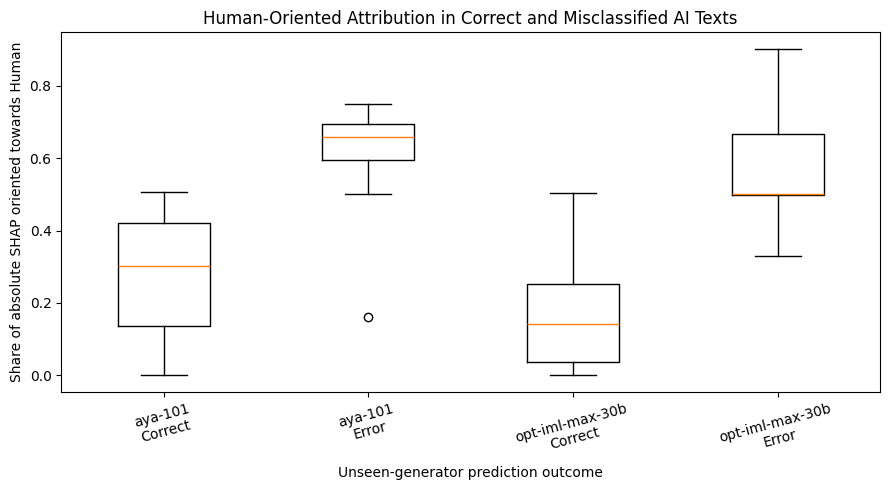


Saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Outcome_Conditioned_Error_Analysis/outcome_conditioned_sample_summary.csv
Saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Outcome_Conditioned_Error_Analysis/outcome_conditioned_statistical_tests.csv
Saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Outcome_Conditioned_Error_Analysis/outcome_conditioned_sample_metrics.parquet


In [ ]:
# Build sample-level outcome-conditioned attribution summaries

# Separate token contributions according to whether they push
# the prediction towards Human or towards AI.

weak_sample_attribution_df = (
    weak_outcome_tokens_df
    .assign(
        Human_oriented_absolute_SHAP=lambda frame: np.where(
            frame["AI_SHAP"] < 0,
            frame["Absolute AI SHAP"],
            0.0
        ),

        AI_oriented_absolute_SHAP=lambda frame: np.where(
            frame["AI_SHAP"] > 0,
            frame["Absolute AI SHAP"],
            0.0
        )
    )
    .groupby(
        [
            "Excluded generator",
            "Generalisation group",
            "SHAP sample position",
            "Prediction outcome",
            "AI probability"
        ],
        as_index=False
    )
    .agg(
        Token_count=(
            "Token",
            "size"
        ),

        Mean_absolute_SHAP=(
            "Absolute AI SHAP",
            "mean"
        ),

        Maximum_absolute_SHAP=(
            "Absolute AI SHAP",
            "max"
        ),

        Mean_signed_SHAP=(
            "AI_SHAP",
            "mean"
        ),

        Total_absolute_SHAP=(
            "Absolute AI SHAP",
            "sum"
        ),

        Human_oriented_absolute_SHAP=(
            "Human_oriented_absolute_SHAP",
            "sum"
        ),

        AI_oriented_absolute_SHAP=(
            "AI_oriented_absolute_SHAP",
            "sum"
        )
    )
)

weak_sample_attribution_df[
    "Human-oriented attribution share"
] = (
    weak_sample_attribution_df[
        "Human_oriented_absolute_SHAP"
    ]
    / weak_sample_attribution_df[
        "Total_absolute_SHAP"
    ].replace(
        0,
        np.nan
    )
)

weak_sample_attribution_df[
    "Net directional evidence"
] = (
    weak_sample_attribution_df[
        "AI_oriented_absolute_SHAP"
    ]
    - weak_sample_attribution_df[
        "Human_oriented_absolute_SHAP"
    ]
)

outcome_summary_df = (
    weak_sample_attribution_df
    .groupby(
        [
            "Excluded generator",
            "Prediction outcome"
        ],
        as_index=False
    )
    .agg(
        Samples=(
            "SHAP sample position",
            "size"
        ),

        Mean_AI_probability=(
            "AI probability",
            "mean"
        ),

        Median_AI_probability=(
            "AI probability",
            "median"
        ),

        Mean_tokens=(
            "Token_count",
            "mean"
        ),

        Mean_absolute_SHAP=(
            "Mean_absolute_SHAP",
            "mean"
        ),

        Median_absolute_SHAP=(
            "Mean_absolute_SHAP",
            "median"
        ),

        Mean_maximum_SHAP=(
            "Maximum_absolute_SHAP",
            "mean"
        ),

        Mean_signed_SHAP=(
            "Mean_signed_SHAP",
            "mean"
        ),

        Mean_Human_oriented_share=(
            "Human-oriented attribution share",
            "mean"
        ),

        Mean_net_directional_evidence=(
            "Net directional evidence",
            "mean"
        )
    )
)

print(
    "Outcome-conditioned sample summary:"
)

display(
    outcome_summary_df.style.format({
        "Mean_AI_probability":
            "{:.4f}",

        "Median_AI_probability":
            "{:.4f}",

        "Mean_tokens":
            "{:.2f}",

        "Mean_absolute_SHAP":
            "{:.4f}",

        "Median_absolute_SHAP":
            "{:.4f}",

        "Mean_maximum_SHAP":
            "{:.4f}",

        "Mean_signed_SHAP":
            "{:.4f}",

        "Mean_Human_oriented_share":
            "{:.2%}",

        "Mean_net_directional_evidence":
            "{:.4f}"
    })
)


# Non-parametric comparisons within each generator

def rank_biserial_from_u(
    u_statistic,
    n_correct,
    n_error
):
    """
    Positive values indicate larger values among
    correctly classified samples.
    """

    return (
        1.0
        - (
            2.0 * u_statistic
        )
        / (
            n_error * n_correct
        )
    )


statistical_records = []

metrics_to_test = {
    "AI probability":
        "AI probability",

    "Mean absolute SHAP":
        "Mean_absolute_SHAP",

    "Mean signed SHAP":
        "Mean_signed_SHAP",

    "Human-oriented attribution share":
        "Human-oriented attribution share",

    "Net directional evidence":
        "Net directional evidence"
}


for generator in WEAK_GENERALISATION_GENERATORS:

    generator_df = weak_sample_attribution_df[
        weak_sample_attribution_df[
            "Excluded generator"
        ].eq(generator)
    ]

    correct_df = generator_df[
        generator_df[
            "Prediction outcome"
        ].eq(
            "Correct AI detection"
        )
    ]

    error_df = generator_df[
        generator_df[
            "Prediction outcome"
        ].eq(
            "Misclassified as Human"
        )
    ]

    for metric_label, metric_column in metrics_to_test.items():

        correct_values = (
            correct_df[
                metric_column
            ]
            .dropna()
        )

        error_values = (
            error_df[
                metric_column
            ]
            .dropna()
        )

        if (
            len(correct_values) == 0
            or len(error_values) == 0
        ):
            continue

        u_stat, p_value = mannwhitneyu(
            error_values,
            correct_values,
            alternative="two-sided"
        )

        statistical_records.append({
            "Excluded generator":
                generator,

            "Metric":
                metric_label,

            "Correct samples":
                len(correct_values),

            "Misclassified samples":
                len(error_values),

            "Correct median":
                correct_values.median(),

            "Misclassified median":
                error_values.median(),

            "Median difference (error - correct)":
                (
                    error_values.median()
                    - correct_values.median()
                ),

            "Mann-Whitney U":
                u_stat,

            "p-value":
                p_value,

            "Rank-biserial effect":
                rank_biserial_from_u(
                    u_stat,
                    len(correct_values),
                    len(error_values)
                )
        })


outcome_statistical_df = pd.DataFrame(
    statistical_records
)

print(
    "\nWithin-generator non-parametric comparisons:"
)

display(
    outcome_statistical_df.style.format({
        "Correct median":
            "{:.4f}",

        "Misclassified median":
            "{:.4f}",

        "Median difference (error - correct)":
            "{:.4f}",

        "Mann-Whitney U":
            "{:.1f}",

        "p-value":
            "{:.4f}",

        "Rank-biserial effect":
            "{:.3f}"
    })
)


# Visualise Human-oriented attribution share

plot_order = [
    "Correct AI detection",
    "Misclassified as Human"
]

plot_data = []
plot_labels = []

for generator in WEAK_GENERALISATION_GENERATORS:

    for outcome in plot_order:

        values = weak_sample_attribution_df.loc[
            weak_sample_attribution_df[
                "Excluded generator"
            ].eq(generator)
            & weak_sample_attribution_df[
                "Prediction outcome"
            ].eq(outcome),
            "Human-oriented attribution share"
        ].dropna().values

        plot_data.append(
            values
        )

        plot_labels.append(
            f"{generator}\n"
            + (
                "Correct"
                if outcome == "Correct AI detection"
                else "Error"
            )
        )


plt.figure(
    figsize=(9, 5)
)

plt.boxplot(
    plot_data,
    tick_labels=plot_labels,
    showfliers=True
)

plt.ylabel(
    "Share of absolute SHAP oriented towards Human"
)

plt.xlabel(
    "Unseen-generator prediction outcome"
)

plt.title(
    "Human-Oriented Attribution in Correct "
    "and Misclassified AI Texts"
)

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.show()


# Save the outputs

summary_path = (
    ERROR_ANALYSIS_ROOT
    / "outcome_conditioned_sample_summary.csv"
)

statistics_path = (
    ERROR_ANALYSIS_ROOT
    / "outcome_conditioned_statistical_tests.csv"
)

sample_metrics_path = (
    ERROR_ANALYSIS_ROOT
    / "outcome_conditioned_sample_metrics.parquet"
)

save_dataframe_atomic(
    outcome_summary_df,
    summary_path
)

save_dataframe_atomic(
    outcome_statistical_df,
    statistics_path
)

save_dataframe_atomic(
    weak_sample_attribution_df,
    sample_metrics_path
)

print(
    "\nSaved:",
    summary_path
)

print(
    "Saved:",
    statistics_path
)

print(
    "Saved:",
    sample_metrics_path
)


The outcome-conditioned analysis revealed a clear directional distinction between successful and unsuccessful unseen-generator detection. For both Aya-101 and OPT-IML-Max-30B, correctly detected AI-generated texts were characterised by strongly positive mean signed attribution, a relatively small proportion of Human-oriented attribution, and positive net directional evidence. In contrast, texts misclassified as Human showed substantially larger Human-oriented attribution shares and negative net directional evidence.

For Aya-101, the mean Human-oriented attribution share increased from 27.41% among correctly detected samples to 62.41% among misclassified samples. Similarly, for OPT-IML-Max-30B, the corresponding share increased from 18.01% to 57.61%. Mean signed SHAP also shifted from positive values among correct predictions to negative values among misclassified samples. Net directional evidence followed the same pattern, changing from 0.6263 to -0.4779 for Aya-101 and from 0.8300 to -0.1722 for OPT-IML-Max-30B.

The non-parametric comparisons showed that the differences in mean signed SHAP, Human-oriented attribution share, and net directional evidence were statistically significant for both generators and were associated with very large rank-based effect magnitudes. This indicates that the distinction between correct and incorrect unseen-generator detection was not limited to prediction confidence, but was also reflected in the direction of the model's feature attribution.

The absolute magnitude of attribution displayed a less consistent pattern. For Aya-101, the difference in mean absolute SHAP between correct and misclassified samples was not statistically significant, with a p-value of 0.1020. This suggests that Aya-101 errors cannot be explained simply by weaker feature attribution. Instead, the more important distinction was the direction in which the available evidence influenced the prediction. For OPT-IML-Max-30B, misclassified samples showed significantly lower mean absolute SHAP, with a p-value of 0.0013, together with a strong shift towards Human-oriented evidence. This suggests that OPT-IML-Max-30B errors were associated with both weaker overall attribution and incorrectly directed feature support.

Overall, the findings suggest that weak generator generalisation is not explained solely by the absence of strong AI-related evidence. Misclassified unseen-generator texts were characterised by a systematic reorientation of attribution towards the Human-written class. However, these results should be interpreted as associative rather than causal, as SHAP identifies the feature-attribution patterns accompanying prediction errors but does not establish that these patterns directly caused the misclassifications.

### 20.7.2 Illustrative Example-Level SHAP Comparison

To illustrate the aggregate outcome-conditioned findings at the individual-text level, one correctly detected and one misclassified AI-generated text are selected from each weak-generalisation condition. The selected cases are chosen as representative examples rather than extreme outliers: within each outcome group, the sample whose Human-oriented attribution share is closest to the group median is used.

For each example, the original text, AI-class probability and strongest Human- and AI-oriented token contributions are displayed. This comparison provides a concrete illustration of how feature evidence differs between correctly detected and misclassified unseen-generator texts.

The examples are descriptive and should not be treated as representative of every text produced by the corresponding generator.

In [ ]:
# Select representative correct and misclassified examples
# and display their strongest directional SHAP contributions.

REPRESENTATIVE_GENERATORS = [
    "aya-101",
    "opt-iml-max-30b"
]

TOP_EXAMPLE_TOKENS = 10


def select_median_representative_sample(
    sample_metrics_df,
    generator,
    outcome
):
    """
    Select the sample whose Human-oriented attribution share
    is closest to the median of its generator-outcome group.
    """

    group_df = sample_metrics_df[
        sample_metrics_df["Excluded generator"].eq(generator)
        & sample_metrics_df["Prediction outcome"].eq(outcome)
    ].copy()

    if group_df.empty:
        return None

    group_median = group_df[
        "Human-oriented attribution share"
    ].median()

    group_df[
        "Distance from group median"
    ] = (
        group_df[
            "Human-oriented attribution share"
        ]
        - group_median
    ).abs()

    return (
        group_df
        .sort_values(
            "Distance from group median"
        )
        .iloc[0]
    )


representative_sample_records = []

for generator in REPRESENTATIVE_GENERATORS:

    for outcome in [
        "Correct AI detection",
        "Misclassified as Human"
    ]:

        representative_row = (
            select_median_representative_sample(
                weak_sample_attribution_df,
                generator,
                outcome
            )
        )

        if representative_row is None:
            continue

        representative_sample_records.append({
            "Excluded generator":
                generator,

            "Prediction outcome":
                outcome,

            "SHAP sample position":
                representative_row[
                    "SHAP sample position"
                ],

            "AI probability":
                representative_row[
                    "AI probability"
                ],

            "Human-oriented attribution share":
                representative_row[
                    "Human-oriented attribution share"
                ],

            "Net directional evidence":
                representative_row[
                    "Net directional evidence"
                ]
        })


representative_examples_df = pd.DataFrame(
    representative_sample_records
)

display(
    representative_examples_df.style.format({
        "AI probability":
            "{:.4f}",

        "Human-oriented attribution share":
            "{:.2%}",

        "Net directional evidence":
            "{:.4f}"
    })
)

,Excluded generator,Prediction outcome,SHAP sample position,AI probability,Human-oriented attribution share,Net directional evidence
0,aya-101,Correct AI detection,45,0.9991,30.13%,0.8244
1,aya-101,Misclassified as Human,12,0.0009,65.55%,-0.8154
2,opt-iml-max-30b,Correct AI detection,92,1.0000,14.22%,0.9607
3,opt-iml-max-30b,Misclassified as Human,90,0.0009,50.39%,-0.0054


In [ ]:
# Display the text and strongest token contributions
# for each representative example.

for _, example_row in representative_examples_df.iterrows():

    generator = example_row[
        "Excluded generator"
    ]

    outcome = example_row[
        "Prediction outcome"
    ]

    sample_position = example_row[
        "SHAP sample position"
    ]

    sample_record = weak_outcome_samples_df[
        weak_outcome_samples_df[
            "Excluded generator"
        ].eq(generator)
        & weak_outcome_samples_df[
            "SHAP sample position"
        ].eq(sample_position)
    ].iloc[0]

    sample_tokens_df = weak_outcome_tokens_df[
        weak_outcome_tokens_df[
            "Excluded generator"
        ].eq(generator)
        & weak_outcome_tokens_df[
            "SHAP sample position"
        ].eq(sample_position)
    ].copy()

    strongest_ai_tokens_df = (
        sample_tokens_df[
            sample_tokens_df[
                "AI_SHAP"
            ] > 0
        ]
        .sort_values(
            "AI_SHAP",
            ascending=False
        )
        .head(
            TOP_EXAMPLE_TOKENS
        )
        [
            [
                "Token",
                "AI_SHAP",
                "Absolute AI SHAP"
            ]
        ]
    )

    strongest_human_tokens_df = (
        sample_tokens_df[
            sample_tokens_df[
                "AI_SHAP"
            ] < 0
        ]
        .sort_values(
            "AI_SHAP",
            ascending=True
        )
        .head(
            TOP_EXAMPLE_TOKENS
        )
        [
            [
                "Token",
                "AI_SHAP",
                "Absolute AI SHAP"
            ]
        ]
    )

    print("\n" + "=" * 100)
    print(
        f"GENERATOR: {generator}"
    )
    print(
        f"OUTCOME: {outcome}"
    )
    print(
        f"AI probability: "
        f"{example_row['AI probability']:.4f}"
    )
    print(
        "Human-oriented attribution share: "
        f"{example_row['Human-oriented attribution share']:.2%}"
    )
    print(
        "Net directional evidence: "
        f"{example_row['Net directional evidence']:.4f}"
    )
    print("=" * 100)

    print("\nTEXT:\n")
    print(
        sample_record["text"]
    )

    print(
        "\nStrongest tokens pushing towards AI:"
    )

    display(
        strongest_ai_tokens_df.style.format({
            "AI_SHAP":
                "{:.4f}",

            "Absolute AI SHAP":
                "{:.4f}"
        })
    )

    print(
        "\nStrongest tokens pushing towards Human:"
    )

    display(
        strongest_human_tokens_df.style.format({
            "AI_SHAP":
                "{:.4f}",

            "Absolute AI SHAP":
                "{:.4f}"
        })
    )



The illustrative examples provide concrete support for the aggregate outcome-conditioned findings. In both weak-generalisation conditions, correctly detected texts were dominated by AI-oriented feature evidence, whereas misclassified texts contained stronger or competing Human-oriented contributions.

For the correctly detected Aya-101 example, the classifier assigned an AI probability of 0.9991. Its Human-oriented attribution share was 30.13%, and the net directional evidence remained strongly positive at 0.8244. Although individual features such as `anime` and the full stop contributed towards the Human-written class, these contributions were outweighed by AI-oriented evidence from other lexical and punctuation features.

The misclassified Aya-101 example showed the opposite pattern. Although repeated hashtag symbols contributed towards the AI-generated class, several lexical and named-entity-related fragments within the campaign-style text produced stronger Human-oriented contributions. Consequently, the Human-oriented attribution share increased to 65.55%, the net directional evidence fell to -0.8154, and the genuinely AI-generated text received an AI probability of only 0.0009. This example illustrates that the presence of an individual AI-associated feature, such as a hashtag, was insufficient when the surrounding lexical evidence was interpreted more strongly as Human-written.

A similar contrast was observed for OPT-IML-Max-30B. The correctly detected example contained the phrase `You are a helpful assistant`, for which tokens such as `You`, `are`, `helpful`, and `assistant` strongly supported the AI-generated class. The sample consequently received an AI probability of 1.0000, with only 14.22% of its absolute attribution oriented towards Human and strongly positive net directional evidence.

In contrast, the misclassified OPT-IML-Max-30B example was a short social-media-style sports heading containing a hashtag, flag emojis, and a competition-round label. Although the hashtag provided AI-oriented evidence, this was approximately balanced by Human-oriented contributions from other token and subword fragments. Its Human-oriented attribution share reached 50.39%, and its net directional evidence was slightly negative at -0.0054. The model therefore classified the text as Human with an AI probability of 0.0009.

Together, these examples illustrate two related failure patterns. In the Aya-101 case, strong Human-oriented lexical evidence outweighed the available AI-related signals. In the OPT-IML-Max-30B case, relatively weak and competing directional evidence placed the sample close to the attribution balance point, with the final evidence falling slightly towards the Human class. These examples therefore support the broader conclusion that unseen-generator errors may arise not only from missing AI indicators, but also from AI-related signals being outweighed or counterbalanced by features learned as characteristic of Human-written social-media text.

The examples remain illustrative rather than generally representative. In particular, multilingual subword fragments and emoji components should not be interpreted as independent semantic features, because their SHAP values are affected by the model's tokenisation and the surrounding textual context.

In [ ]:
from IPython.display import HTML, display
import html


def directional_shap_text_html(
    token_df,
    ai_probability,
    prediction_outcome,
    max_abs_value=None
):
    """
    Create an HTML token visualisation from saved token-level SHAP values.

    Positive AI_SHAP:
        pushes towards AI.

    Negative AI_SHAP:
        pushes towards Human.
    """

    plot_df = (
        token_df
        .sort_values("Token position")
        .copy()
    )

    if max_abs_value is None:
        max_abs_value = plot_df[
            "Absolute AI SHAP"
        ].quantile(0.95)

    max_abs_value = max(
        float(max_abs_value),
        1e-8
    )

    token_spans = []

    for _, row in plot_df.iterrows():

        token = str(row["Token"])
        shap_value = float(row["AI_SHAP"])

        strength = min(
            abs(shap_value) / max_abs_value,
            1.0
        )

        # Positive attribution: AI direction
        if shap_value > 0:
            background = (
                f"rgba(220, 53, 69, "
                f"{0.12 + 0.68 * strength:.3f})"
            )
            direction = "AI"

        # Negative attribution: Human direction
        elif shap_value < 0:
            background = (
                f"rgba(13, 110, 253, "
                f"{0.12 + 0.68 * strength:.3f})"
            )
            direction = "Human"

        else:
            background = "rgba(128, 128, 128, 0.08)"
            direction = "Neutral"

        tooltip = (
            f"Direction: {direction}; "
            f"AI SHAP: {shap_value:.4f}"
        )

        token_spans.append(
            f"""
            <span
                title="{html.escape(tooltip)}"
                style="
                    display: inline-block;
                    background: {background};
                    padding: 3px 4px;
                    margin: 2px 1px;
                    border-radius: 4px;
                    font-family: monospace;
                    white-space: pre-wrap;
                "
            >{html.escape(token)}</span>
            """
        )

    header_html = f"""
    <div style="margin-bottom: 10px;">
        <strong>Outcome:</strong>
        {html.escape(str(prediction_outcome))}
        &nbsp;&nbsp;
        <strong>AI probability:</strong>
        {ai_probability:.4f}
    </div>

    <div style="margin-bottom: 12px;">
        <span style="
            background: rgba(220, 53, 69, 0.55);
            padding: 3px 7px;
            border-radius: 4px;
        ">Towards AI</span>

        <span style="
            background: rgba(13, 110, 253, 0.55);
            padding: 3px 7px;
            border-radius: 4px;
            margin-left: 8px;
        ">Towards Human</span>
    </div>
    """

    return (
        header_html
        + "<div style='line-height: 2.1;'>"
        + "".join(token_spans)
        + "</div>"
    )


for _, example_row in representative_examples_df.iterrows():

    generator = example_row[
        "Excluded generator"
    ]

    outcome = example_row[
        "Prediction outcome"
    ]

    sample_position = example_row[
        "SHAP sample position"
    ]

    example_tokens_df = weak_outcome_tokens_df[
        weak_outcome_tokens_df[
            "Excluded generator"
        ].eq(generator)
        & weak_outcome_tokens_df[
            "SHAP sample position"
        ].eq(sample_position)
    ].copy()

    print("\n" + "=" * 100)
    print(
        f"{generator} — {outcome}"
    )
    print("=" * 100)

    display(
        HTML(
            directional_shap_text_html(
                token_df=example_tokens_df,
                ai_probability=example_row[
                    "AI probability"
                ],
                prediction_outcome=outcome
            )
        )
    )

### 20.7.3 Identify Recurrent Features Associated with Misclassification

To determine which shared features change most strongly between successful and unsuccessful detection, signed SHAP values are aggregated separately for correct and misclassified samples within each weak-generalisation condition. Only tokens recurring in both outcome groups are compared. Positive shifts indicate that a token becomes more AI-oriented among misclassified cases; negative shifts indicate that it becomes more Human-oriented.

This comparison is exploratory. It is intended to identify interpretable examples of conflicting evidence, not to establish universal generator-independent markers. Tokens with low occurrence counts, multilingual subword fragments and visually similar but tokenisation-distinct representations should be interpreted cautiously.

In [ ]:
# Compare recurrent directional features
# between correct and misclassified cases

MIN_OUTCOME_TOKEN_OCCURRENCES = 3
TOP_OUTCOME_DIRECTIONAL_SHIFTS = 12

outcome_directional_frames = []

for generator in WEAK_GENERALISATION_GENERATORS:

    generator_tokens_df = weak_outcome_tokens_df[
        weak_outcome_tokens_df[
            "Excluded generator"
        ].eq(generator)
    ].copy()

    token_outcome_summary_df = (
        generator_tokens_df
        .groupby(
            [
                "Prediction outcome",
                "Token"
            ],
            as_index=False
        )
        .agg(
            Occurrences=(
                "AI_SHAP",
                "size"
            ),

            Mean_signed_SHAP=(
                "AI_SHAP",
                "mean"
            ),

            Mean_absolute_SHAP=(
                "Absolute AI SHAP",
                "mean"
            )
        )
    )

    recurrent_df = token_outcome_summary_df[
        token_outcome_summary_df[
            "Occurrences"
        ] >= MIN_OUTCOME_TOKEN_OCCURRENCES
    ].copy()

    signed_wide_df = recurrent_df.pivot(
        index="Token",
        columns="Prediction outcome",
        values="Mean_signed_SHAP"
    )

    occurrence_wide_df = recurrent_df.pivot(
        index="Token",
        columns="Prediction outcome",
        values="Occurrences"
    )

    required_outcomes = [
        "Correct AI detection",
        "Misclassified as Human"
    ]

    if not all(
        outcome in signed_wide_df.columns
        for outcome in required_outcomes
    ):

        print(
            "Skipping token shift table for "
            f"{generator}: both outcomes were not available."
        )

        continue

    shared_token_index = (
        signed_wide_df
        .dropna(
            subset=required_outcomes
        )
        .index
    )

    comparison_df = pd.DataFrame({
        "Token":
            shared_token_index,

        "Correct mean signed SHAP":
            signed_wide_df.loc[
                shared_token_index,
                "Correct AI detection"
            ].values,

        "Misclassified mean signed SHAP":
            signed_wide_df.loc[
                shared_token_index,
                "Misclassified as Human"
            ].values,

        "Correct occurrences":
            occurrence_wide_df.loc[
                shared_token_index,
                "Correct AI detection"
            ].values,

        "Misclassified occurrences":
            occurrence_wide_df.loc[
                shared_token_index,
                "Misclassified as Human"
            ].values
    })

    comparison_df[
        "Directional shift (error - correct)"
    ] = (
        comparison_df[
            "Misclassified mean signed SHAP"
        ]
        - comparison_df[
            "Correct mean signed SHAP"
        ]
    )

    comparison_df[
        "Excluded generator"
    ] = generator

    comparison_df[
        "Token type"
    ] = (
        comparison_df[
            "Token"
        ]
        .apply(
            classify_generator_token_type
        )
    )

    comparison_df = (
        comparison_df
        .sort_values(
            "Directional shift (error - correct)"
        )
        .reset_index(
            drop=True
        )
    )

    outcome_directional_frames.append(
        comparison_df
    )

    print(
        "\n" + "=" * 80
    )

    print(
        "MOST HUMAN-ORIENTED SHIFTS IN ERRORS:",
        generator
    )

    print(
        "=" * 80
    )

    display(
        comparison_df
        .head(
            TOP_OUTCOME_DIRECTIONAL_SHIFTS
        )
        .style
        .format({
            "Correct mean signed SHAP":
                "{:.4f}",

            "Misclassified mean signed SHAP":
                "{:.4f}",

            "Directional shift (error - correct)":
                "{:.4f}"
        })
    )

    print(
        "\nLargest shifts towards AI in errors:"
    )

    display(
        comparison_df
        .tail(
            TOP_OUTCOME_DIRECTIONAL_SHIFTS
        )
        .sort_values(
            "Directional shift (error - correct)",
            ascending=False
        )
        .style
        .format({
            "Correct mean signed SHAP":
                "{:.4f}",

            "Misclassified mean signed SHAP":
                "{:.4f}",

            "Directional shift (error - correct)":
                "{:.4f}"
        })
    )

    generator_output_path = (
        ERROR_ANALYSIS_ROOT
        / (
            f"{create_shap_safe_name(generator)}"
            "_outcome_directional_token_shifts.csv"
        )
    )

    save_dataframe_atomic(
        comparison_df,
        generator_output_path
    )

    print(
        "Saved:",
        generator_output_path
    )


if outcome_directional_frames:

    combined_outcome_directional_df = pd.concat(
        outcome_directional_frames,
        ignore_index=True
    )

    combined_output_path = (
        ERROR_ANALYSIS_ROOT
        / "combined_outcome_directional_token_shifts.csv"
    )

    save_dataframe_atomic(
        combined_outcome_directional_df,
        combined_output_path
    )

    print(
        "\nCombined token shift table saved:",
        combined_output_path
    )


MOST HUMAN-ORIENTED SHIFTS IN ERRORS: aya-101


,Token,Correct mean signed SHAP,Misclassified mean signed SHAP,Correct occurrences,Misclassified occurrences,Directional shift (error - correct),Excluded generator,Token type
0,.,-0.0019,-0.0958,63.000000,32.000000,-0.0938,aya-101,Non-lexical
1,не,-0.0039,-0.0927,4.000000,7.000000,-0.0888,aya-101,Lexical
2,",",0.0073,-0.0516,59.000000,21.000000,-0.0589,aya-101,Non-lexical
3,a,0.0049,-0.0374,32.000000,3.000000,-0.0424,aya-101,Lexical
4,and,0.0049,-0.0335,3.000000,3.000000,-0.0384,aya-101,Lexical
5,-,0.0375,0.0016,12.000000,27.000000,-0.0359,aya-101,Non-lexical
6,,0.0072,-0.0104,194.000000,48.000000,-0.0176,aya-101,Non-lexical
7,и,-0.0001,-0.0060,5.000000,3.000000,-0.0059,aya-101,Lexical
8,s,-0.0007,0.0114,16.000000,4.000000,0.0122,aya-101,Lexical
9,de,0.0087,0.0210,12.000000,6.000000,0.0122,aya-101,Lexical



Largest shifts towards AI in errors:


,Token,Correct mean signed SHAP,Misclassified mean signed SHAP,Correct occurrences,Misclassified occurrences,Directional shift (error - correct),Excluded generator,Token type
13,#,0.0131,0.1459,3.000000,8.000000,0.1328,aya-101,Non-lexical
12,ты,0.0018,0.0378,3.000000,3.000000,0.0360,aya-101,Lexical
11,do,-0.0296,-0.0023,4.000000,11.000000,0.0273,aya-101,Lexical
10,no,-0.0568,-0.0414,5.000000,3.000000,0.0154,aya-101,Lexical
9,de,0.0087,0.0210,12.000000,6.000000,0.0122,aya-101,Lexical
8,s,-0.0007,0.0114,16.000000,4.000000,0.0122,aya-101,Lexical
7,и,-0.0001,-0.0060,5.000000,3.000000,-0.0059,aya-101,Lexical
6,,0.0072,-0.0104,194.000000,48.000000,-0.0176,aya-101,Non-lexical
5,-,0.0375,0.0016,12.000000,27.000000,-0.0359,aya-101,Non-lexical
4,and,0.0049,-0.0335,3.000000,3.000000,-0.0384,aya-101,Lexical


Saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Outcome_Conditioned_Error_Analysis/aya-101_outcome_directional_token_shifts.csv

MOST HUMAN-ORIENTED SHIFTS IN ERRORS: opt-iml-max-30b


,Token,Correct mean signed SHAP,Misclassified mean signed SHAP,Correct occurrences,Misclassified occurrences,Directional shift (error - correct),Excluded generator,Token type
0,.,0.1048,-0.0373,54.000000,8.000000,-0.1420,opt-iml-max-30b,Non-lexical
1,USER,-0.0359,-0.1678,7.000000,3.000000,-0.1319,opt-iml-max-30b,Lexical
2,y,0.0326,-0.0400,11.000000,4.000000,-0.0726,opt-iml-max-30b,Lexical
3,:,0.0786,0.0764,6.000000,3.000000,-0.0022,opt-iml-max-30b,Non-lexical
4,,0.0046,0.0031,164.000000,18.000000,-0.0015,opt-iml-max-30b,Non-lexical
5,s,-0.0121,-0.0064,17.000000,4.000000,0.0057,opt-iml-max-30b,Lexical
6,-,0.0042,0.0111,12.000000,18.000000,0.0069,opt-iml-max-30b,Non-lexical
7,de,0.0097,0.0472,19.000000,4.000000,0.0375,opt-iml-max-30b,Lexical
8,[,0.1075,0.1786,7.000000,3.000000,0.0712,opt-iml-max-30b,Non-lexical



Largest shifts towards AI in errors:


,Token,Correct mean signed SHAP,Misclassified mean signed SHAP,Correct occurrences,Misclassified occurrences,Directional shift (error - correct),Excluded generator,Token type
8,[,0.1075,0.1786,7.000000,3.000000,0.0712,opt-iml-max-30b,Non-lexical
7,de,0.0097,0.0472,19.000000,4.000000,0.0375,opt-iml-max-30b,Lexical
6,-,0.0042,0.0111,12.000000,18.000000,0.0069,opt-iml-max-30b,Non-lexical
5,s,-0.0121,-0.0064,17.000000,4.000000,0.0057,opt-iml-max-30b,Lexical
4,,0.0046,0.0031,164.000000,18.000000,-0.0015,opt-iml-max-30b,Non-lexical
3,:,0.0786,0.0764,6.000000,3.000000,-0.0022,opt-iml-max-30b,Non-lexical
2,y,0.0326,-0.0400,11.000000,4.000000,-0.0726,opt-iml-max-30b,Lexical
1,USER,-0.0359,-0.1678,7.000000,3.000000,-0.1319,opt-iml-max-30b,Lexical
0,.,0.1048,-0.0373,54.000000,8.000000,-0.1420,opt-iml-max-30b,Non-lexical


Saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Outcome_Conditioned_Error_Analysis/opt-iml-max-30b_outcome_directional_token_shifts.csv

Combined token shift table saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Outcome_Conditioned_Error_Analysis/combined_outcome_directional_token_shifts.csv


The recurrent-token comparison supports the outcome-conditioned sample-level findings by showing that misclassification was associated with directional changes in several shared features rather than with the complete disappearance of AI-oriented evidence.

For Aya-101, the full stop and comma exhibited the largest shifts towards the Human-written class, with the comma changing from a slightly AI-oriented contribution in correctly detected texts to a Human-oriented contribution in misclassified samples. In contrast, the hashtag symbol became substantially more AI-oriented in the error subset. This indicates that AI-associated social-media cues remained present in misclassified texts but were outweighed by stronger Human-oriented contributions from other recurrent features.

For OPT-IML-Max-30B, the full stop showed the largest directional shift, changing from a strongly AI-oriented contribution in correctly detected texts to a Human-oriented contribution in errors. The USER token was Human-oriented in both outcome groups but became considerably more Human-oriented among misclassified samples, whereas the opening square bracket retained a strong AI-oriented contribution. These patterns indicate that prediction errors resulted from competing directional evidence rather than from the disappearance of AI-oriented signals.

Overall, the token-level comparison suggests that shared recurrent features may change both the strength and, in some cases, the direction of their contribution between correctly detected and misclassified unseen-generator texts. Because several lexical and multilingual subword tokens occurred only a small number of times within the error subsets, the individual token rankings should be interpreted as exploratory, with greater emphasis placed on the consistent behaviour of recurrent punctuation and structural features.

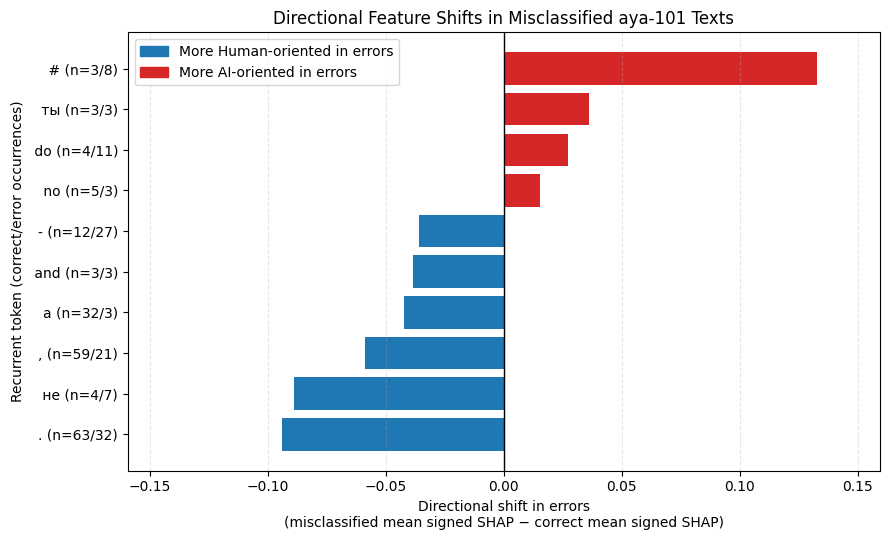

Saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Outcome_Conditioned_Error_Analysis/aya-101_clean_directional_shift_plot.png


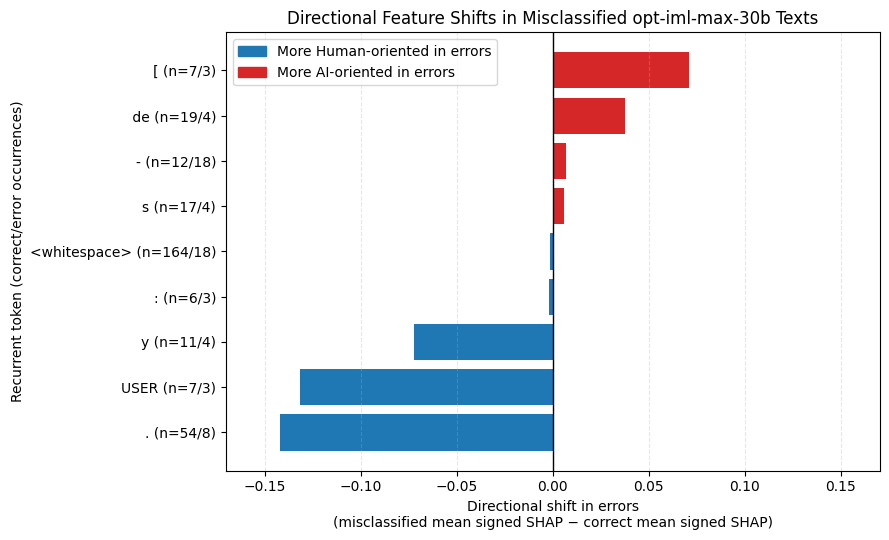

Saved: /content/drive/MyDrive/Dissertation/Generator_Generalisation_Experiments/Comparisons/Generator_Specific_SHAP/Outcome_Conditioned_Error_Analysis/opt-iml-max-30b_clean_directional_shift_plot.png


In [ ]:
# Produce cleaner presentation-ready directional shift plots.

TOP_HUMAN_SHIFTS = 6
TOP_AI_SHIFTS = 4


def plot_clean_directional_token_shifts(
    directional_df,
    generator
):
    generator_df = directional_df[
        directional_df[
            "Excluded generator"
        ].eq(generator)
    ].copy()

    if generator_df.empty:
        print(
            f"No directional token shifts found for {generator}."
        )
        return

    human_shift_df = (
        generator_df
        .nsmallest(
            TOP_HUMAN_SHIFTS,
            "Directional shift (error - correct)"
        )
    )

    ai_shift_df = (
        generator_df[
            generator_df[
                "Directional shift (error - correct)"
            ] > 0
        ]
        .nlargest(
            TOP_AI_SHIFTS,
            "Directional shift (error - correct)"
        )
    )

    plot_df = (
        pd.concat(
            [
                human_shift_df,
                ai_shift_df
            ],
            ignore_index=True
        )
        .drop_duplicates(
            subset=["Token"]
        )
        .sort_values(
            "Directional shift (error - correct)"
        )
        .copy()
    )

    def format_token_label(row):

        token = str(row["Token"])

        if token.strip() == "":
            token = "<whitespace>"

        return (
            f"{token} "
            f"(n={int(row['Correct occurrences'])}/"
            f"{int(row['Misclassified occurrences'])})"
        )

    plot_df[
        "Display token"
    ] = plot_df.apply(
        format_token_label,
        axis=1
    )

    shifts = plot_df[
        "Directional shift (error - correct)"
    ].to_numpy()

    colours = [
        "tab:blue" if value < 0 else "tab:red"
        for value in shifts
    ]

    fig, ax = plt.subplots(
        figsize=(9, 5.5)
    )

    ax.barh(
        plot_df["Display token"],
        shifts,
        color=colours
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    ax.set_xlabel(
        "Directional shift in errors\n"
        "(misclassified mean signed SHAP − "
        "correct mean signed SHAP)"
    )

    ax.set_ylabel(
        "Recurrent token "
        "(correct/error occurrences)"
    )

    ax.set_title(
        "Directional Feature Shifts in "
        f"Misclassified {generator} Texts"
    )

    human_patch = mpatches.Patch(
        color="tab:blue",
        label="More Human-oriented in errors"
    )

    ai_patch = mpatches.Patch(
        color="tab:red",
        label="More AI-oriented in errors"
    )

    ax.legend(
        handles=[
            human_patch,
            ai_patch
        ],
        loc="best"
    )

    max_shift = max(
        abs(shifts.min()),
        abs(shifts.max())
    )

    ax.set_xlim(
        -max_shift * 1.20,
        max_shift * 1.20
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()

    output_path = (
        ERROR_ANALYSIS_ROOT
        / (
            f"{create_shap_safe_name(generator)}"
            "_clean_directional_shift_plot.png"
        )
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        output_path
    )


for generator in WEAK_GENERALISATION_GENERATORS:

    plot_clean_directional_token_shifts(
        combined_outcome_directional_df,
        generator
    )

The directional-shift visualisations provide an intuitive illustration of the token-level comparison. In both weak-generalisation conditions, recurrent Human-oriented and AI-oriented features coexist within the same misclassified texts rather than one type of evidence disappearing entirely.

Although certain recurrent features (such as full stops and the USER marker) become more Human-oriented in the error subsets, others (such as hashtags or opening brackets) retain or strengthen their AI-oriented contribution. The visualisations therefore reinforce the conclusion that misclassification arises from competing directional evidence, in which Human-oriented contributions outweigh the remaining AI-oriented signals.

These examples also illustrate that the directional contribution of an individual token is context-dependent rather than fixed. Because several lexical and multilingual subword representations occur only a few times in the misclassified subsets, the individual token rankings remain exploratory and are interpreted alongside the broader sample-level attribution patterns.

## Final Results of the Leave-One-Generator-Out Analysis

The leave-one-generator-out experiments revealed an important distinction between aggregate benchmark performance and generator-specific generalisation. The reference baseline model, trained using examples from all seven AI generators, achieved an overall accuracy of 0.9364, an AI-class F1-score of 0.9668 and a ROC-AUC of 0.9782. Overall benchmark performance remained comparatively stable across the seven LOGO conditions: accuracy ranged from 0.9293 to 0.9459, while ROC-AUC remained above 0.97 in every experiment. Therefore, excluding a single generator from development did not substantially reduce the classifier's overall multilingual Human-versus-AI performance.

However, the generator-specific results showed that this aggregate stability concealed considerable variation in unseen-generator detection. The largest generalisation gaps were observed for OPT-IML-Max-30B and Aya-101. When excluded from development, their AI detection rates decreased to 0.7853 and 0.7825, producing generalisation gaps of 17.97 and 17.56 percentage points, respectively. Gemini and GPT-3.5-Turbo-0125 also showed notable reductions of 11.46 and 8.98 percentage points, while Mistral-7B-Instruct-v0.2 produced a smaller gap of 3.98 percentage points. By contrast, v5-Eagle-7B-HF and Vicuna-13B produced negative gaps of -4.01 and -2.59 percentage points, indicating that their texts were detected more successfully when unseen than the pooled texts from generators represented during development.

These findings show that exposure to one set of generators does not provide uniform transfer to every unseen generator. A classifier may retain strong overall benchmark metrics because the excluded generator represents only one component of the test set, while still exhibiting a substantial generator-specific weakness. Aggregate accuracy, F1-score and ROC-AUC therefore provide an incomplete account of cross-generator robustness.

The observed differences were not adequately explained by the examined dataset-composition characteristics. Language distributions were highly similar across all seven generators, with most proportional differences remaining below one percentage point. Platform composition was also consistent: Telegram represented approximately 39–40% of each generator's texts, followed by Discord at approximately 23–25%, with similarly stable proportions for Gab, Twitter and WhatsApp. Consequently, the weak generalisation observed for Aya-101 and OPT-IML-Max-30B is unlikely to be explained by substantially different language or platform distributions.

Text length varied more strongly across generators, but it did not show a consistent relationship with generalisation performance. OPT-IML-Max-30B and Aya-101 produced comparatively short texts, with mean lengths of 19.56 and 25.14 tokens, and showed the largest performance reductions. Nevertheless, Gemini also exhibited a substantial generalisation gap despite producing much longer texts, with a mean of 147.07 tokens. Conversely, v5-Eagle-7B-HF and Vicuna-13B occupied the intermediate length range and generalised strongly. Mean text length may therefore contribute to the difficulty of particular generators, but it is not sufficient as a general explanation for the observed pattern.

Prediction-confidence results closely followed the generator-specific detection results. Generators with the largest positive generalisation gaps also received substantially lower AI-class probabilities when they were excluded from development. In contrast, v5-Eagle-7B-HF and Vicuna-13B received comparatively stronger AI probabilities under their unseen conditions. This indicates that the differences were not limited to small changes around a fixed classification threshold; rather, the classifiers assigned systematically lower AI-class probabilities to generators exhibiting weaker unseen generalisation.

The comparative SHAP analysis further showed that strong and weak generalisation were not characterised by completely separate feature inventories. Shared recurrent features, particularly punctuation and structural tokenizer units, frequently changed their attribution direction or strength between the two generalisation groups. For example, the full stop and comma changed from Human-oriented under the strong-generalisation conditions to AI-oriented under the weak-generalisation conditions, while the forward slash changed in the opposite direction. This suggests that generator-specific robustness depends not only on whether a feature is present, but also on how the trained classifier interprets that feature within the surrounding context.

The outcome-conditioned error analysis provided more direct evidence of the feature-level mechanism associated with weak generalisation. For Aya-101, the mean Human-oriented attribution share increased from 27.41% in correctly detected samples to 62.41% in samples misclassified as Human. For OPT-IML-Max-30B, the corresponding share increased from 18.01% to 57.61%. Mean signed SHAP and net directional evidence also changed from positive values in correct predictions to negative values in errors for both generators. These differences were statistically significant and accompanied by very large rank-based effect magnitudes.

The absolute attribution results distinguished the two weak-generalisation conditions further. For Aya-101, mean absolute SHAP did not differ significantly between correct and incorrect predictions, suggesting that its errors were not primarily caused by an absence of influential features. Instead, the available evidence was directed towards the wrong class. For OPT-IML-Max-30B, misclassified samples showed both lower absolute attribution and stronger Human-oriented evidence, indicating a combination of weaker and misdirected feature support.

Recurrent-token comparisons supported this interpretation. In Aya-101 errors, full stops and commas became more Human-oriented, while the hashtag symbol became more strongly AI-oriented. Thus, AI-related social-media cues remained present but were outweighed by competing Human-oriented evidence. In OPT-IML-Max-30B errors, the full stop reversed from AI-oriented to Human-oriented and the USER token became more strongly Human-oriented, although other structural features retained AI-oriented contributions. The errors therefore did not result from the complete disappearance of AI signals, but from competition between features contributing in opposing directions.

The illustrative examples further demonstrated that identical prediction outcomes could arise through different attribution mechanisms. In the correctly detected OPT-IML-Max-30B example, explicit assistant-style language was associated with strong AI-oriented feature evidence. In contrast, the Aya-101 political campaign-style example contained AI-oriented hashtag contributions but was classified as Human because several lexical and named-entity-related fragments produced stronger Human-oriented contributions. The misclassified OPT-IML-Max-30B example illustrated a different failure pattern, in which AI- and Human-oriented evidence remained almost balanced before the final prediction shifted towards the Human-written class.

Overall, the LOGO experiments demonstrate that strong aggregate benchmark performance does not guarantee reliable generalisation to every unseen generator. The differences cannot be reduced to simple language, platform or average-length composition. Instead, weak generalisation was consistently associated with lower AI confidence and systematic changes in the weighting and direction of shared feature evidence. The error analyses further showed that AI-oriented cues often remained present in misclassified texts but were outweighed or counterbalanced by features contributing towards the Human-written class.

These findings should be interpreted as descriptive and associative rather than causal. Nevertheless, they provide evidence that generator-specific evaluation and outcome-conditioned explainability reveal robustness weaknesses that would remain hidden if the classifier were assessed only through aggregate benchmark metrics.

## Limitations of the Leave-One-Generator-Out Analysis

Although the leave-one-generator-out experiments provide evidence of heterogeneous cross-generator generalisation, several limitations should be considered when interpreting the results.

First, the analysis evaluates only the seven generators represented in the MultiSocial benchmark. The observed generalisation gaps therefore describe transfer across this particular set of models and should not be assumed to generalise to all current or future LLMs. Generators with different architectures, training corpora, alignment procedures or decoding settings may exhibit different detection behaviour.

Second, the analysis identifies how weak generalisation manifests in the classifier's predictions, but it does not establish the upstream generative causes of these failures. Although the language, platform and text-length analyses ruled out several simple distributional explanations, and the SHAP analyses identified systematic attribution patterns associated with successful and unsuccessful transfer, the available benchmark metadata do not permit these behaviours to be attributed directly to specific generator characteristics such as model architecture, instruction tuning, decoding strategy or prompting conditions.

Third, generator-specific performance was evaluated using a binary Human-versus-AI detector rather than a generator identification model. Consequently, the LOGO experiments demonstrate whether the detector transfers to unseen generators, but they do not reveal whether the model internally distinguishes individual generator identities or broader stylistic families.

Fourth, the explainability analyses were conducted on controlled explanatory subsets rather than on the complete generator-specific test sets. The generator-level SHAP comparison used 100 representative samples per selected condition, while the outcome-conditioned analysis contained 22 misclassified Aya-101 samples and 16 misclassified OPT-IML-Max-30B samples. These subsets were sufficient to identify consistent attribution patterns, but the relatively small error groups reduce the stability of low-frequency token-level comparisons.

Fifth, the statistical comparisons in the outcome-conditioned analysis should be interpreted as exploratory rather than confirmatory. The explained samples were selected for interpretability rather than through an independently powered statistical design, and multiple attribution metrics were examined simultaneously. The reported p-values and rank-biserial effect sizes therefore strengthen confidence in the observed patterns but should not be interpreted as definitive inferential evidence.

Sixth, SHAP provides an associative explanation of the classifier's decision process. It identifies which features contributed towards the AI-generated or Human-written prediction for a particular sample, but it does not demonstrate that these features causally produced the prediction. Feature interactions, contextual dependencies and correlations between tokens may all influence the attribution assigned to individual tokenizer units.

Seventh, all explainability analyses were performed at the tokenizer-unit level. Because mDeBERTa uses multilingual subword tokenisation, complete words may be divided into multiple fragments, while emojis and multilingual expressions may also be represented by several tokenizer units. Consequently, occurrence counts refer to repeated tokenizer units rather than complete lexical items or semantic concepts. Frequently occurring subword fragments may therefore appear prominent despite having limited independent meaning, whereas meaningful words or expressions may be distributed across multiple tokens.

This limitation is particularly important in multilingual social-media data, where tokenisation behaviour differs across languages, writing systems and morphological structures. For this reason, isolated lexical fragments and emoji components were not interpreted as universal indicators of either Human-written or AI-generated text. Greater interpretive weight was instead placed on recurrent punctuation, structural markers and consistent sample-level attribution patterns.

Eighth, both the group-level and outcome-conditioned recurrent-token analyses required tokens to appear repeatedly across the compared groups before they were analysed. This improves comparability but inevitably excludes features that occur only within one condition. In addition, relatively low occurrence thresholds were necessary because the misclassified subsets were small, particularly for OPT-IML-Max-30B. Individual token shifts with only a few observations should therefore be interpreted as illustrative rather than stable generator-specific markers.

Ninth, the illustrative text-level SHAP examples were intentionally selected as median representatives according to Human-oriented attribution share rather than as the strongest or weakest examples. Although this reduces the influence of extreme outliers, a small number of representative texts cannot capture the full linguistic and stylistic diversity of each generator. Their purpose is to demonstrate the attribution mechanisms observed in the aggregate analyses rather than to characterise all outputs produced by Aya-101 or OPT-IML-Max-30B.

Finally, the present study focuses on observational comparisons rather than controlled intervention experiments. Although the analyses demonstrate consistent associations between generator-specific generalisation and attribution behaviour, they do not systematically manipulate textual characteristics such as punctuation, hashtags, named entities or assistant-style phrases to measure their causal influence on prediction outcomes. Such counterfactual experiments would provide stronger evidence regarding the causal importance of individual feature groups but would require carefully controlled multilingual text editing while preserving semantic meaning.

Overall, these limitations indicate that the reported findings should be interpreted as evidence of heterogeneous generator-specific robustness and of the attribution patterns associated with successful and unsuccessful transfer. They should not be interpreted as establishing a universal taxonomy of difficult generators or a definitive causal explanation for why particular LLMs produce texts that are easier or harder to detect.

